<a href="https://colab.research.google.com/github/rmmandrade/ml2526/blob/rodrigo/Group57_part1_(4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install rapidfuzz


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 69.5 MB/s eta 0:00:00


# **Abstract**

The price of a used car is influenced by multiple factors such as age, mileage, brand, fuel type, and technical characteristics, making accurate price estimation a complex task. The objective of this project is to develop a consistent model assessment strategy that allows the creation and comparison of different candidate regression models in order to identify the most generalizable one for predicting car prices.

The work started with an exploratory analysis of the dataset to understand feature distributions and identify data quality issues. A major challenge during data preparation was the cleaning of categorical variables, particularly brand and model names, which contained numerous inconsistencies and misspellings. To address this, a hybrid fuzzy string matching approach was applied, combining Euclidean distance and Levenshtein distance to standardise equivalent values. Missing data was handled using appropriate imputation methods, while numerical features were scaled and categorical features were encoded. The dataset was split into training and test sets, with all model training, comparison, and hyperparameter tuning performed exclusively on the training data.

In total, six different regression models were developed and evaluated using a consistent assessment strategy, enabling a fair comparison of their performance and generalisation capability. The best results, in terms of Mean Absolute Error (MAE), were achieved using a blended model combining Extra Trees, Random Forest, and Histogram Gradient Boosting. In addition, an analytics interface was created using Gradio, allowing users to input new vehicle data and instantly receive a predicted price from the trained model.

Future work may focus on feature engineering, expanding the dataset, and improving the user interface to make it more user-friendly and robust.





# **1. Imports and library setup**

In [2]:
# =========================================
# 2) Imports — Organized by topic
# =========================================

# ---- Data manipulation & utilities
import pandas as pd
import numpy as np
import random

# ---- Similarity / fuzzy matching
from rapidfuzz import process, fuzz, distance

# ---- Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Statistics
import scipy.stats as stats
from scipy.stats import (
    chi2_contingency,
    f_oneway
)

# ---- Scikit-learn — Data splitting
from sklearn.model_selection import train_test_split

# ---- Scikit-learn — Preprocessing
from sklearn.preprocessing import (
    MinMaxScaler,
    LabelEncoder,
    PowerTransformer
)

# ---- Scikit-learn — Feature selection
from sklearn.feature_selection import (
    mutual_info_classif,
    mutual_info_regression,
    RFE
)

# ---- Scikit-learn — Models
from sklearn.linear_model import (
    LinearRegression,
    LassoCV
)

# ---- Scikit-learn — Evaluation
from sklearn.metrics import mean_squared_error


# **2. Data cleaning and domain establishment**


In [3]:
RANDOM_SEED = 1907
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## **2.1 Data Quality Assessment**


In [4]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [5]:
# =========================================
# 2.1) Data Quality Assessment — Initial inspection
# =========================================

from IPython.display import display, HTML
import pandas as pd

# ---- Load dataset
df = pd.read_csv("train.csv")
display(df)

# ---- Preserve original raw dataset---- Preserve original raw dataset---- Preserve original raw dataset---- Preserve original raw dataset---- Preserve original raw dataset
og_df = df.copy()

# ---- Dataset overview
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Dataset overview</b><br><br>
The dataset contains a total of <b>14 columns</b>, one of which is a strong candidate
to act as a unique identifier for each observation (<b>carID</b>).<br><br>
This leaves us with <b>13 features</b> to be used for analysis and modeling.
</div>
"""))

# ---- Dataset structure and data types
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Data types inspection</b><br>
Below we inspect the structure of the dataset and the data types assigned to each column.
</div>
"""))

df.info()

# ---- Feature type summary
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Feature type summary</b><br><br>
The data types appear to be correctly inferred. Based on this inspection, the dataset
contains:
<ul>
  <li><b>4 categorical features</b>: Brand, model, transmission, fuelType</li>
  <li><b>10 numerical features</b>: carID, year, price, mileage, tax, mpg,
      engineSize, paintQuality%, previousOwners and hasDamage</li>
</ul>
</div>
"""))

# ---- Descriptive statistics
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Descriptive statistics</b><br>
Below we inspect summary statistics for all numerical features.
</div>
"""))

df.describe()


,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
75969,6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
75970,54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0
75971,860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.100000,2.0,74.0,2.000000,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75973 entries, 0 to 75972
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   carID           75973 non-null  int64  
 1   Brand           74452 non-null  object 
 2   model           74456 non-null  object 
 3   year            74482 non-null  float64
 4   price           75973 non-null  int64  
 5   transmission    74451 non-null  object 
 6   mileage         74510 non-null  float64
 7   fuelType        74462 non-null  object 
 8   tax             68069 non-null  float64
 9   mpg             68047 non-null  float64
 10  engineSize      74457 non-null  float64
 11  paintQuality%   74449 non-null  float64
 12  previousOwners  74423 non-null  float64
 13  hasDamage       74425 non-null  float64
dtypes: float64(8), int64(2), object(4)
memory usage: 8.1+ MB


,carID,year,price,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
count,75973.000000,74482.000000,75973.000000,74510.000000,68069.000000,68047.000000,74457.000000,74449.000000,74423.000000,74425.0
mean,37986.000000,2017.096611,16881.889553,23004.184088,120.329078,55.152666,1.660136,64.590667,1.994580,0.0
std,21931.660338,2.208704,9736.926322,22129.788366,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
min,0.000000,1970.000000,450.000000,-58540.574478,-91.121630,-43.421768,-0.103493,1.638913,-2.345650,0.0
25%,18993.000000,2016.000000,10200.000000,7423.250000,125.000000,46.300000,1.200000,47.000000,1.000000,0.0
50%,37986.000000,2017.000000,14699.000000,17300.000000,145.000000,54.300000,1.600000,65.000000,2.000000,0.0
75%,56979.000000,2019.000000,20950.000000,32427.500000,145.000000,62.800000,2.000000,82.000000,3.000000,0.0
max,75972.000000,2024.121759,159999.000000,323000.000000,580.000000,470.800000,6.600000,125.594308,6.258371,0.0


## **2.2 `carID` feature**

In [6]:
# =========================================
# 2.2) Preprocessing carID — Unique identifier validation
# =========================================

from IPython.display import display, HTML

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>carID — unique identifier validation</b><br><br>
Before using <b>carID</b> as a true unique identifier, we must first verify whether
duplicate values are present in the dataset.
</div>
"""))

# ---- Check for duplicate carID values
display(df["carID"].duplicated().any())

# ---- Conclusion of duplicate check
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Result</b><br>
No duplicate values were found. The <b>carID</b> feature can therefore be safely
used as a true unique identifier.
</div>
"""))

# ---- Helper function: set carID as index
def carID_como_index(df):
    df = df.copy()
    df = df.set_index("carID")
    return df

# ---- Apply transformation
df = carID_como_index(df)
display(df)

# ---- Section transition
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Next step</b><br>
With the unique identifier validated and correctly set as index, we now proceed to
assess individual feature values and distributions, starting with the
<b>Brand</b> feature.
</div>
"""))


np.False_

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0


## **2.3 Brand Feature**


In [7]:
# =========================================
# Brand feature — Exploration and correction
# =========================================

from IPython.display import display, HTML

# ---- Unique values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Brand — unique values</b>
</div>
"""))
display(df["Brand"].unique())


# ---- Value counts
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Brand — value counts (before correction)</b>
</div>
"""))
display(df["Brand"].value_counts())


# ---- Missing values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Brand — missing values</b>
</div>
"""))
display(df[df["Brand"].isna()])


# ---- Helper: single brand correction
def HELPER_marca_correta(marca, marcas_dict, threshold):
    if not isinstance(marca, str) or marca.strip() == "":
        return marca

    result = process.extractOne(
        marca.lower().strip(),
        marcas_dict.keys(),
        scorer=fuzz.token_sort_ratio
    )

    if result is None:
        return marca

    match, score, _ = result
    return marcas_dict[match] if score >= threshold else marca


# ---- Dataset-level fuzzy correction
def fuzzy_marcas(df, threshold=50):
    df = df.copy()

    valid_brands = [
        "VW", "Toyota", "Audi", "Ford",
        "BMW", "Opel", "Skoda", "Mercedes", "Hyundai"
    ]

    brands_dict = {b.lower(): b for b in valid_brands}

    df["Brand"] = df["Brand"].apply(
        lambda x: HELPER_marca_correta(x, brands_dict, threshold)
    )

    return df


# ---- Apply correction
df = fuzzy_marcas(df)


# ---- Results
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Brand — after fuzzy correction</b>
</div>
"""))
display(df["Brand"].unique())
display(df["Brand"].value_counts())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Brand names were successfully standardized into <b>9 categories</b>.
</div>
"""))


array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'FOR', 'mercedes', 'Hyundai', 'w', 'ord', 'MW', 'bmw', nan,
       'yundai', 'BM', 'Toyot', 'udi', 'Ope', 'AUDI', 'V', 'opel', 'pel',
       'For', 'pe', 'Mercede', 'audi', 'MERCEDES', 'OPEL', 'koda', 'FORD',
       'Hyunda', 'W', 'Aud', 'vw', 'hyundai', 'skoda', 'ford', 'TOYOTA',
       'ercedes', 'oyota', 'toyota', 'SKODA', 'Skod', 'HYUNDAI', 'kod',
       'v', 'for', 'SKOD', 'aud', 'KODA', 'PEL', 'yunda', 'or', 'UDI',
       'OYOTA', 'HYUNDA', 'mw', 'OPE', 'mercede', 'ERCEDES', 'ercede',
       'TOYOT', 'MERCEDE', 'ORD', 'ud', 'ope', 'AUD', 'hyunda', 'skod',
       'toyot'], dtype=object)

,count
Brand,
Ford,14808
Mercedes,10754
VW,9780
Opel,8645
BMW,6968
...,...
OYOTA,2
SKOD,1
TOYOT,1


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
66591,NaN,T-Roc,2018.0,23000,Semi-Auto,584.0,Petrol,150.0,41.5,2.0,79.0,1.0,0.0
5034,NaN,A3,2016.0,11871,Manual,52519.0,Diesel,20.0,72.4,1.6,60.0,2.0,0.0
33153,NaN,I20,2020.0,13966,MANUAL,3500.0,Petrol,145.0,47.9,1.0,41.0,2.0,0.0
45338,NaN,CL Class,2020.0,54995,Semi-Auto,NaN,Petrol,145.0,33.2,2.0,61.0,4.0,0.0
66712,NaN,POLO,2016.0,8650,Manual,32800.0,Petrol,20.0,60.1,1.0,54.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72615,NaN,Golf,2015.0,11750,Manual,79000.0,Diesel,20.0,67.3,2.0,68.0,0.0,0.0
3436,NaN,Q5,2015.0,21995,Semi-Auto,18188.0,Diesel,200.0,47.1,2.0,84.0,3.0,0.0
7392,NaN,A5,2019.0,31490,Automatic,10.0,Petrol,145.0,39.8,2.0,70.0,1.0,0.0


array(['VW', 'Toyota', 'Audi', 'Ford', 'BMW', 'Skoda', 'Opel', 'Mercedes',
       'Hyundai', nan], dtype=object)

,count
Brand,
Ford,16063
Mercedes,11674
VW,10385
Opel,9352
BMW,7392
Audi,7325
Toyota,4622
Skoda,4303
Hyundai,3336


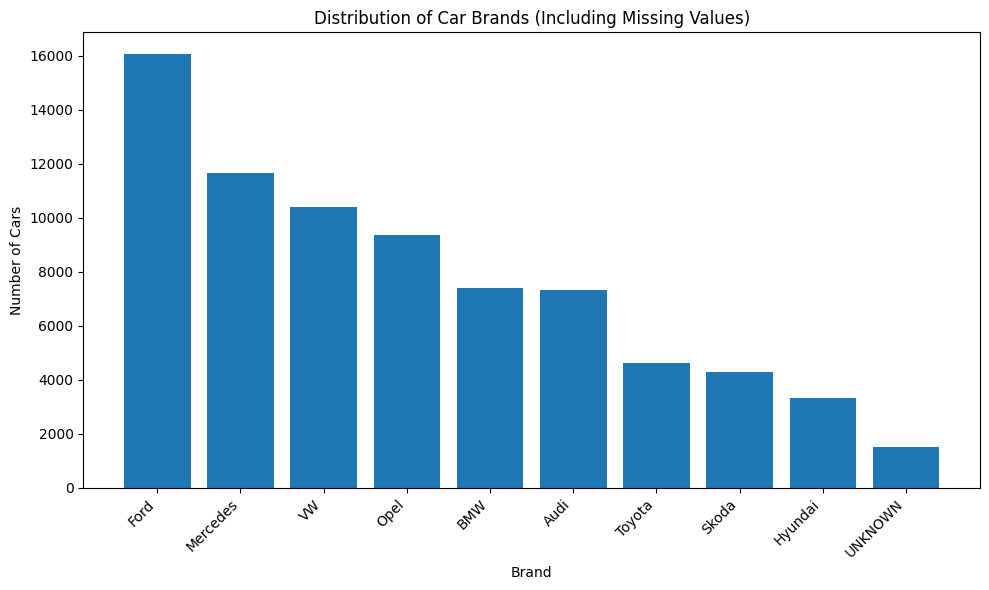

In [8]:
# =========================================
# Brand feature — Distribution bar plot (with NaN)
# =========================================

import matplotlib.pyplot as plt

# ---- Brand distribution (NaN included as category)
brand_counts = df["Brand"].fillna("UNKNOWN").value_counts()

plt.figure(figsize=(10, 6))
plt.bar(brand_counts.index, brand_counts.values)

plt.title("Distribution of Car Brands (Including Missing Values)")
plt.xlabel("Brand")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [9]:
from IPython.display import display, HTML

display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Brand — data quality issues and normalization strategy</b><br><br>

Approximately <b>1500 missing values (NaNs)</b> are present in the <b>Brand</b> feature,
along with several inconsistent and misspelled entries.<br><br>

To ensure a single, standardized brand name per vehicle, we apply a
<b>fuzzy string matching</b> strategy to correct invalid and inconsistent values.<br><br>

The helper function <b>HELPER_marca_correta()</b> evaluates each brand value
individually. Invalid entries (NaN or empty strings) are ignored, while valid
strings are converted to lowercase and compared against a predefined list of
valid brands using <b>RapidFuzz</b> (<code>process.extractOne()</code>).<br><br>

If the similarity score exceeds a predefined threshold, the value is replaced by
its standardized form; otherwise, it is left unchanged. This logic is applied to
the full dataset through the <b>fuzzy_marcas()</b> function.<br><br>

The matching strictness is controlled via the <b>threshold parameter</b>
(<code>threshold=50</code>): lower values allow more aggressive corrections,
while higher values restrict replacements to very similar strings.<br><br>

This process effectively normalizes the <b>Brand</b> feature, consolidating entries
such as <i>'Audi'</i>, <i>'Aud'</i>, <i>'udi'</i>, <i>'audi'</i>, <i>'AUD'</i> and
<i>'ud'</i> into the correct standardized brand name, <b>'Audi'</b>.
</div>
"""))


## **2.4 Model Feature**


In [11]:
from valid_models import valid_models


In [12]:
# =========================================
# Model feature — Exploration and correction
# =========================================

from IPython.display import display, HTML

# ---- Unique models
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Model — unique values</b>
</div>
"""))
display(df["model"].unique())

# ---- Number of unique models
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Model — number of unique values</b>
</div>
"""))
display(len(df["model"].unique()))

# ---- Models grouped by brand (example)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Model — examples grouped by brand (Hyundai)</b>
</div>
"""))
grouped = df.groupby("Brand")["model"].value_counts()
display(grouped["Hyundai"])

# ---- Valid models dictionary
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Model — normalization strategy</b><br>
Model names are standardized using brand-specific valid model lists and fuzzy matching.
</div>
"""))

from valid_models import valid_models


# ---- Helper: normalize model strings
def HELPER_normalize_models(df):
    df = df.copy()
    df["model"] = (
        df["model"]
        .astype(str)
        .str.upper()
        .str.replace("-", "", regex=False)
        .str.replace(r"\s+", "", regex=True)
        .replace(["", "NAN", "NONE"], None)
    )
    return df


# ---- Helper: hybrid similarity scorer
def HELPER_hybrid_scorer(a, b, **kwargs):
    lev = distance.Levenshtein.normalized_similarity(a, b)
    token = fuzz.token_sort_ratio(a, b) / 100
    return (0.7 * lev + 0.3 * token) * 100


# ---- Helper: correct single model
def HELPER_modelo_correto(model, brand, valid_models_dict, threshold):
    if not model or model.strip() == "":
        return None

    if not brand or brand not in valid_models_dict:
        return model

    valid_list = valid_models_dict[brand]
    result = process.extractOne(model, valid_list, scorer=HELPER_hybrid_scorer)

    if result is None:
        return model

    model_name, score, _ = result
    return model_name if score >= threshold else None


# ---- Dataset-level fuzzy correction
def fuzzy_modelos(df, valid_models_dict, threshold=30):
    df = HELPER_normalize_models(df)

    df["model"] = df.apply(
        lambda row: HELPER_modelo_correto(
            row["model"], row["Brand"], valid_models_dict, threshold
        ),
        axis=1
    )
    return df


# ---- Before correction
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Model — before correction</b>
</div>
"""))
display(len(df["model"].unique()))
display(df[df["model"].isna()])


# ---- Apply correction
df = fuzzy_modelos(df, valid_models)

# ---- After correction
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Model — after fuzzy correction</b>
</div>
"""))
display(df[df["model"].isna()])

unique_models_per_brand = df.groupby("Brand")["model"].nunique()
display(unique_models_per_brand)


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Model names were successfully standardized using brand-specific fuzzy matching,
significantly reducing noise and cardinality.
</div>
"""))


array([' Golf', ' Yaris', ' Q2', ' FIESTA', ' 2 Series', '3 Series',
       ' A3', ' Octavia', ' Passat', ' Focus', ' Insignia', ' A Clas',
       ' Q3', ' Fabia', ' A Class', ' Ka+', ' 3 Series', ' GLC Class',
       ' I30', ' C Class', ' Polo', ' E Class', ' C Clas', ' Q5', ' Up',
       ' Fiesta', ' C-HR', ' Mokka X', ' Corsa', ' Astra', ' TT',
       ' 5 Series', ' Aygo', ' 4 Series', ' SLK', ' Viva', ' T-Roc',
       'Focus', ' EcoSport', ' Tucson', ' EcoSpor', nan, ' X-CLASS',
       ' CL Class', ' IX20', ' i20', ' Rapid', ' a1', ' Auris', ' sharan',
       ' I20', ' Adam', ' X3', ' A8', ' GLS Class', ' B-MAX', ' A4',
       ' Kona', ' I10', ' A1', ' Mokka', ' fiesta', ' S-MAX', ' X2',
       ' Crossland X', ' Tiguan', ' A5', ' GLE Class', ' C CLASS',
       ' mokka x', ' Zafira', ' Ioniq', ' A6', ' Mondeo', ' Yeti Outdoor',
       ' X1', 'POLO', ' INSIGNIA', ' Scala', ' S Class', ' 1 Series',
       ' Kamiq', ' Kuga', ' Tourneo Connect', ' Q7', ' GLA Class',
       ' Arteon', ' 

736

,count
model,
Tucson,821
I10,671
I30,352
I20,307
Kona,213
Ioniq,185
Santa Fe,135
IX20,129
I40,78


736

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,NaN,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,NaN,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,NaN,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,NaN,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,NaN,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,NaN,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,NaN,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,NaN,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
30317,Ford,None,2019.0,9999,Manual,10000.0,Petrol,145.0,47.9,0.0,61.0,3.0,0.0
28739,Ford,None,2015.0,7099,Manual,74176.0,Diesel,NaN,NaN,1.5,84.0,2.0,NaN
63868,Opel,None,2016.0,8695,Manual,39460.0,Petrol,125.0,50.4,1.4,99.0,1.0,0.0
18304,Ford,None,2016.0,9632,Manual,18814.0,Petrol,20.0,62.8,1.0,74.0,NaN,0.0
65285,Opel,None,2016.0,6999,Manual,45367.0,Petrol,30.0,55.4,1.4,41.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72991,VW,None,2018.0,17391,Manual,17987.0,Petrol,145.0,46.3,1.4,58.0,2.0,NaN
29299,Ford,None,2017.0,19289,anual,28492.0,Diesel,145.0,56.5,2.0,85.0,1.0,0.0
56250,Opel,None,2019.0,15495,Manual,3129.0,Petrol,145.0,39.2,1.4,49.0,0.0,NaN


,model
Brand,
Audi,25
BMW,24
Ford,22
Hyundai,15
Mercedes,13
Opel,23
Skoda,12
Toyota,18
VW,25


## **2.5 Year Feature**


array([2016.        , 2019.        , 2018.        , 2014.        ,
       2017.        , 2020.        , 2013.        ,           nan,
       2015.        , 2023.36707842, 2011.        , 2012.        ,
       2023.1169636 , 2003.        , 2009.        , 2007.        ,
       2005.        , 2011.11118842, 2011.21085349, 2023.97731126,
       2004.        , 2010.        , 2010.56500919, 2008.        ,
       2024.12175905, 2006.        , 2023.60527574, 2023.38982198,
       2010.67696784, 2001.        , 2000.        , 2023.26798867,
       2010.26863473, 2010.37154646, 2002.        , 2022.69668507,
       2009.81675711, 2010.7464032 , 2012.69574039, 1996.        ,
       1998.        , 2022.87800554, 1970.        , 1999.        ,
       1997.        ])

,Brand,model,year,engineSize
carID,,,,
25881,Ford,ESCORT,1996.0,1.8
3908,Audi,A3,1998.0,1.8
62732,Opel,ZAFIRA,1970.0,NaN
13422,BMW,Z3,1999.0,1.9
36128,Mercedes,SLK,1998.0,2.3
51800,Toyota,YARIS,1999.0,1.3
34918,Mercedes,SCLASS,1997.0,3.2
52914,Toyota,LANDCRUISER,1998.0,4.2
35769,Mercedes,MCLASS,1970.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35263,Mercedes,CCLASS,<NA>,11295,Automatic,45000.0,Petrol,-56.193202,46.3,1.6,59.0,NaN,0.0
53282,Toyota,YARIS,<NA>,16995,Manual,1225.0,Petrol,145.000000,47.9,1.5,77.0,0.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.000000,60.1,1.2,97.0,4.0,0.0
49731,Skoda,OCTAVIA,<NA>,11990,Manual,35650.0,NaN,30.000000,55.4,1.4,68.0,3.0,0.0
38604,Mercedes,ECLASS,<NA>,34980,Semi-Auto,4196.0,diesel,145.000000,70.6,2.0,44.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
67270,VW,POLO,<NA>,6880,Semi-Auto,44551.0,etrol,145.000000,47.9,1.4,92.0,2.0,0.0
61087,Opel,None,<NA>,14295,Manual,14609.0,Petrol,145.000000,39.2,1.4,50.0,2.0,0.0
62592,Opel,ASTRA,<NA>,10295,Manual,10271.0,Petrol,145.000000,62.8,1.0,99.0,3.0,0.0


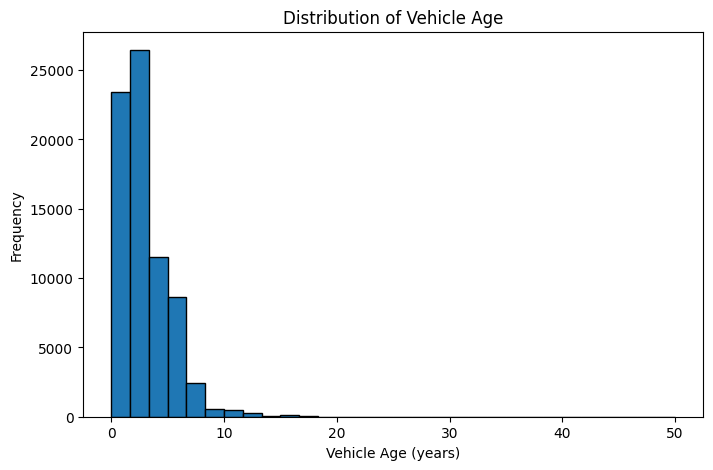

<IntegerArray>
[   4,    1,    2,    6,    3,    0,    7, <NA>,    5,    9,    8,   17,   11,
   13,   15,   16,   10,   12,   14,   19,   20,   18,   24,   22,   50,   21,
   23]
Length: 27, dtype: Int64

,Brand,model,year,price
carID,,,,
60156,Opel,AGILA,17,450
19562,Ford,FOCUS,17,495
23427,Ford,FOCUS,17,495
61005,Opel,CORSA,18,495
55950,Opel,CORSA,17,590


,Brand,model,year,price
carID,,,,
43994,Mercedes,ACLASS,1,140319
766,Audi,R8,0,145000
46012,Mercedes,SCLASS,9,149948
35340,Mercedes,GCLASS,0,154998
38485,Mercedes,GCLASS,0,159999


In [13]:
# =========================================
# Year feature — Exploration and preprocessing
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# ---- Inspect raw year values (manufacturing year)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Year — raw values (manufacturing year)</b><br>
Values represent the original manufacturing year before preprocessing.
</div>
"""))
display(df["year"].unique())


# ---- Identify suspicious manufacturing years (pre-transformation)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Year — suspicious manufacturing years</b><br>
Vehicles with implausibly old manufacturing years.
</div>
"""))
old_cars = df[df["year"] < 2000][["Brand", "model", "year", "engineSize"]]
display(old_cars)


# ---- Feature engineering: convert manufacturing year to vehicle age
def limpar_anos(df, max_year=2020):
    df = df.copy()

    # Convert manufacturing year to vehicle age
    df["year"] = max_year - df["year"]

    # Remove invalid ages (negative or unrealistically old)
    df.loc[(df["year"] < 0) | (df["year"] > 50), "year"] = np.nan

    df["year"] = np.floor(df["year"]).astype("Int64")
    return df


# ---- Apply transformation
df = limpar_anos(df, 2020)


# ---- Missing values after transformation
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Year — missing values after transformation</b><br>
Missing values correspond to invalid or implausible vehicle ages.
</div>
"""))
display(df[df["year"].isna()])


# ---- Distribution of vehicle age (final)
plt.figure(figsize=(8, 5))
plt.hist(df["year"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Vehicle Age")
plt.xlabel("Vehicle Age (years)")
plt.ylabel("Frequency")
plt.show()


# ---- Unique values after preprocessing (vehicle age)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Age of the car — unique values</b><br>
Values now represent vehicle age in years.
</div>
"""))
display(df["year"].unique())


# ---- Sanity check: cheapest vs most expensive vehicles
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Vehicle age — price sanity check</b><br>
Inspecting whether vehicle age aligns with price extremes.
</div>
"""))

ordenado = df.sort_values("price", ascending=True)
baratos = ordenado[["Brand", "model", "year", "price"]].head(5)
caros = ordenado[["Brand", "model", "year", "price"]].tail(5)

display(baratos)
display(caros)


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
The <b>year</b> feature was successfully transformed from manufacturing year into
<b>vehicle age</b>. Invalid and implausible values were removed, resulting in a clean,
low-cardinality numerical feature suitable for feature engineering, imputation,
and modeling.
</div>
"""))


In [14]:
df["year"].describe()


,year
count,74124.0
mean,2.93183
std,2.163122
min,0.0
25%,1.0
50%,3.0
75%,4.0
max,50.0


## **2.6 Transmission Feature**


In [15]:
# =========================================
# Transmission feature — Exploration and correction
# =========================================

from IPython.display import display, HTML
import numpy as np
import pandas as pd

# ---- Unique values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Transmission — unique values</b>
</div>
"""))
display(df["transmission"].unique())


# ---- Missing values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Transmission — missing values</b>
</div>
"""))
display(df[df["transmission"].isna()])


# ---- Helper: normalize transmission strings
def HELPER_normalize_transmission(df):
    df = df.copy()
    df["transmission"] = (
        df["transmission"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df


# ---- Helper: correct single transmission entry
def HELPER_transmissao_correta(transm, valid_list, threshold):
    if pd.isna(transm):
        return np.nan

    if transm in valid_list:
        return transm

    result = process.extractOne(transm, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan


# ---- Dataset-level fuzzy correction
def fuzzy_transmissao(df, threshold=60):
    df = df.copy()
    df = HELPER_normalize_transmission(df)

    valid_list = ["MANUAL", "AUTOMATIC", "SEMI-AUTO", "OTHER", "UNKNOWN"]

    df["transmission"] = df["transmission"].apply(
        lambda x: HELPER_transmissao_correta(x, valid_list, threshold)
    )
    return df


# ---- Apply correction
df = fuzzy_transmissao(df)


# ---- Results after correction
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Transmission — results after correction</b>
</div>
"""))
display(df[df["transmission"].isna()])
display(df["transmission"].unique())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Transmission values were successfully standardized into a small, well-defined
set of categories, reducing noise and improving suitability for categorical encoding.
</div>
"""))


array(['Semi-Auto', 'Manual', 'anual', 'Semi-Aut', 'Automatic', 'manual',
       nan, 'unknown', 'Manua', 'AUTOMATIC', 'MANUAL', 'semi-auto',
       ' Manual ', 'automatic', 'emi-Auto', 'SEMI-AUTO', 'SEMI-AUT',
       'Automati', 'ANUAL', 'utomatic', 'unknow', 'EMI-AUTO', 'manua',
       'anua', 'emi-Aut', 'MANUA', 'emi-auto', 'UTOMATIC', ' manual ',
       ' MANUAL ', 'UNKNOWN', 'nknown', 'automati', 'Other', 'semi-aut',
       ' Manual', 'AUTOMATI', 'utomati', 'Manual ', 'manual ', 'nknow'],
      dtype=object)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0
35376,Mercedes,CCLASS,5,16998,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0
47887,Skoda,FABIA,0,11990,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,1,19990,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0
12874,BMW,4SERIES,1,29995,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,Petrol,NaN,NaN,1.5,87.0,1.0,0.0
35376,Mercedes,CCLASS,5,16998,NaN,43883.0,Diesel,125.0,60.1,2.1,54.0,0.0,0.0
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.0,78.5,1.6,61.0,2.0,0.0
68423,VW,POLO,<NA>,10328,NaN,26941.0,Petrol,145.0,60.1,1.2,97.0,4.0,0.0
47887,Skoda,FABIA,0,11990,NaN,835.0,Petrol,145.0,47.1,1.0,55.0,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2368,Audi,Q2,1,19990,NaN,1500.0,Petrol,145.0,47.1,1.0,92.0,2.0,0.0
12874,BMW,4SERIES,1,29995,NaN,999.0,Diesel,145.0,53.3,3.0,64.0,0.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,Diesel,200.0,NaN,2.0,42.0,4.0,0.0


array(['SEMI-AUTO', 'MANUAL', 'AUTOMATIC', nan, 'UNKNOWN', 'OTHER'],
      dtype=object)

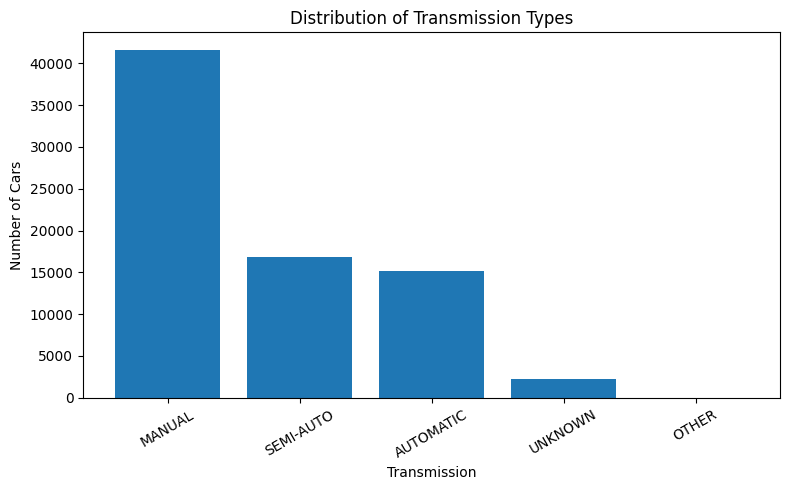

In [16]:
# =========================================
# Transmission feature — Distribution bar plot
# =========================================

import matplotlib.pyplot as plt

# ---- Transmission distribution (NaN included)
transmission_counts = (
    df["transmission"]
    .fillna("UNKNOWN")
    .value_counts()
)

plt.figure(figsize=(8, 5))
plt.bar(transmission_counts.index, transmission_counts.values)

plt.title("Distribution of Transmission Types")
plt.xlabel("Transmission")
plt.ylabel("Number of Cars")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## **2.7 `mileage` feature**


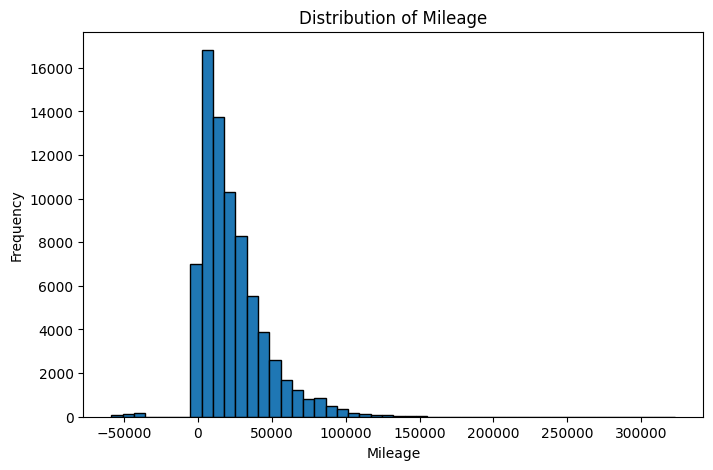

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0
41441,Mercedes,ACLASS,3,13500,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0
22269,Ford,FIESTA,3,8930,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0
6409,Audi,A1,4,10999,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0
7725,BMW,X2,1,23633,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33828,Hyundai,TUCSON,1,18390,MANUAL,NaN,Petrol,145.000000,34.9,1.6,86.0,4.0,0.0
55680,Toyota,CHR,3,20700,AUTOMATIC,NaN,Hybrid,135.000000,74.3,1.8,86.0,0.0,0.0
39353,Mercedes,GLCLASS,1,36490,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
70615,VW,TIGUAN,0,25000,MANUAL,-48190.655673,Petrol,145.0,38.2,1.5,89.0,3.0,0.0
43529,Mercedes,CCLASS,1,25780,SEMI-AUTO,-50755.210230,Diesel,NaN,NaN,2.0,72.0,3.0,0.0
71090,VW,GOLF,2,14995,MANUAL,-48190.655673,Diesel,150.0,57.7,1.6,83.0,2.0,0.0
7845,BMW,3SERIES,1,23498,SEMI-AUTO,-58540.574478,Diesel,145.0,54.3,2.0,38.0,NaN,0.0
24999,Ford,FIESTA,3,8895,MANUAL,-42650.453719,Petrol,125.0,54.3,1.2,45.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56373,Opel,None,2,8514,MANUAL,-42707.564215,Petrol,150.0,55.4,1.4,49.0,1.0,NaN
45765,Mercedes,GLCLASS,0,54995,AUTOMATIC,-50755.210230,Diesel,150.0,32.8,3.0,69.0,4.0,0.0
38413,Mercedes,SLK,5,17900,AUTOMATIC,-50755.210230,Diesel,150.0,56.5,2.1,40.0,3.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
70615,VW,TIGUAN,0,25000,MANUAL,NaN,Petrol,145.0,38.2,1.5,89.0,3.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
64396,Opel,ASTRA,5,6995,NaN,NaN,Diesel,0.000000,78.5,1.6,61.0,2.0,0.0
41441,Mercedes,ACLASS,3,13500,MANUAL,NaN,Diesel,150.000000,72.4,1.5,32.0,2.0,0.0
22269,Ford,FIESTA,3,8930,NaN,NaN,Petrol,145.000000,54.3,1.2,97.0,0.0,0.0
6409,Audi,A1,4,10999,MANUAL,NaN,Diesel,0.000000,76.3,1.6,97.0,3.0,0.0
7725,BMW,X2,1,23633,MANUAL,NaN,Diesel,145.000000,53.3,2.0,97.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39353,Mercedes,GLCLASS,1,36490,SEMI-AUTO,NaN,Diesel,145.000000,40.9,2.0,36.0,3.0,0.0
9474,BMW,3SERIES,4,14000,MANUAL,NaN,Diese,316.487189,62.8,2.0,77.0,4.0,0.0
55820,Toyota,AYGO,1,8491,MANUAL,NaN,Petrol,145.000000,56.5,1.0,56.0,0.0,0.0


In [17]:
# =========================================
# Mileage feature — Exploration
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# ---- Distribution of mileage (raw)
plt.figure(figsize=(8, 5))
plt.hist(df["mileage"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Frequency")
plt.show()


# ---- Missing values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Mileage — missing values</b>
</div>
"""))
display(df[df["mileage"].isna()])


# ---- Invalid negative values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Mileage — invalid negative values</b>
</div>
"""))
display(df[df["mileage"] < 0])


# ---- Helper: assign impossible values to NaN
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df = df.copy()

    if lower_upper == "lower":
        df.loc[df[col] < val, col] = np.nan
    else:
        df.loc[df[col] > val, col] = np.nan

    return df


# ---- Apply correction
df = impossible_to_nan(df, "mileage")


# ---- Sanity check (example row)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Mileage — sanity check</b>
</div>
"""))
display(df.loc[[70615]])


# ---- Post-cleaning checks
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Mileage — after preprocessing</b>
</div>
"""))
display(df[df["mileage"] < 0])
display(df[df["mileage"].isna()])


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Negative mileage values were identified as invalid and converted to <b>NaN</b>.
The <b>mileage</b> feature is now numerically consistent and ready for imputation
and scaling within the machine learning pipeline.
</div>
"""))


## **2.8 fuelType feature**


array(['Petrol', 'Diesel', 'etrol', 'Hybrid', 'diesel', 'iesel', nan,
       'petrol', 'PETROL', 'Diese', 'Petro', 'DIESEL', 'petro', 'HYBRID',
       'ybri', 'Other', 'DIESE', 'Hybri', 'ETROL', 'ybrid', 'PETRO',
       'hybrid', 'IESEL', 'Electric', 'ther', 'iese', 'etro', 'ETRO',
       'diese', 'Othe', 'YBRID', 'HYBRI', 'OTHER', 'other', 'IESE'],
      dtype=object)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
831,Audi,A8,3,38995,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0
49731,Skoda,OCTAVIA,<NA>,11990,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0
1272,Audi,Q7,3,53990,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0
36753,Mercedes,SCLASS,3,18990,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0
53403,Toyota,AYGO,4,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,5,8599,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0
30306,Ford,FIESTA,3,8499,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0
30535,Ford,FIESTA,4,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0


,count
fuelType,
Petrol,37995
Diesel,28474
Hybrid,2043
PETROL,795
etrol,794
Petro,785
petrol,746
iesel,603
diesel,599


array(['PETROL', 'DIESEL', 'HYBRID', nan, 'OTHER', 'ELECTRIC'],
      dtype=object)

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
831,Audi,A8,3,38995,AUTOMATIC,3338.0,NaN,145.0,NaN,3.0,84.000000,0.000000,0.0
49731,Skoda,OCTAVIA,<NA>,11990,MANUAL,35650.0,NaN,30.0,55.4,1.4,68.000000,3.000000,0.0
1272,Audi,Q7,3,53990,SEMI-AUTO,30427.0,NaN,145.0,39.2,4.0,78.000000,1.000000,0.0
36753,Mercedes,SCLASS,3,18990,AUTOMATIC,21490.0,NaN,145.0,70.6,2.1,84.000000,6.258371,0.0
53403,Toyota,AYGO,4,7995,MANUAL,25300.0,NaN,0.0,69.0,1.0,125.594308,1.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
48354,Skoda,OCTAVIA,5,8599,MANUAL,57718.0,NaN,0.0,74.3,1.6,74.000000,3.000000,0.0
30306,Ford,FIESTA,3,8499,MANUAL,18227.0,NaN,0.0,65.7,1.0,99.000000,4.000000,0.0
30535,Ford,FIESTA,4,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.000000,2.000000,0.0


,count
fuelType,
PETROL,41181
DIESEL,30885
HYBRID,2225
OTHER,167
ELECTRIC,4


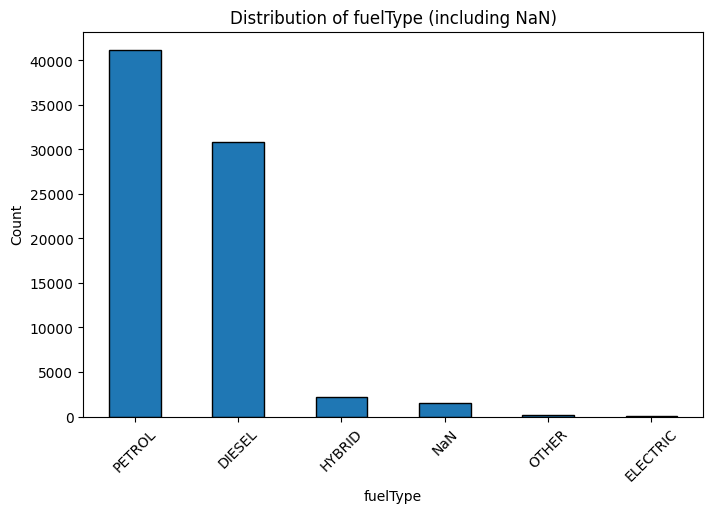

In [18]:
# =========================================
# FuelType feature — Exploration and preprocessing
# =========================================

from IPython.display import display, HTML
import numpy as np
import matplotlib.pyplot as plt

# ---- Unique values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>fuelType — unique values</b>
</div>
"""))
display(df["fuelType"].unique())


# ---- Missing values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>fuelType — missing values</b>
</div>
"""))
display(df[df["fuelType"].isna()])


# ---- Value counts
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>fuelType — value counts</b>
</div>
"""))
display(df["fuelType"].value_counts())


# ---- Helper: normalize fuel type strings
def HELPER_normalize_fueltype(df):
    df = df.copy()
    df["fuelType"] = (
        df["fuelType"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace(["", "NAN", "NONE"], np.nan)
    )
    return df


# ---- Helper: correct single fuel type using fuzzy matching
def HELPER_fuel_correto(fuel, valid_list, threshold):
    if pd.isna(fuel):
        return np.nan

    if fuel in valid_list:
        return fuel

    result = process.extractOne(fuel, valid_list, scorer=fuzz.token_sort_ratio)
    if result is None:
        return np.nan

    match_name, score, _ = result
    return match_name if score >= threshold else np.nan


# ---- Dataset-level fuzzy correction
def fuzzy_fuel(df, threshold=60):
    df = HELPER_normalize_fueltype(df)
    valid_list = ["PETROL", "DIESEL", "HYBRID", "OTHER", "ELECTRIC"]

    df["fuelType"] = df["fuelType"].apply(
        lambda x: HELPER_fuel_correto(x, valid_list, threshold)
    )
    return df


# ---- Apply correction
df = fuzzy_fuel(df)


# ---- Results after preprocessing
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>fuelType — after preprocessing</b>
</div>
"""))
display(df["fuelType"].unique())
display(df[df["fuelType"].isna()])
display(df["fuelType"].value_counts())


# ---- Bar plot (including NaN)
fuel_counts = df["fuelType"].fillna("NaN").value_counts()

plt.figure(figsize=(8, 5))
fuel_counts.plot(kind="bar", edgecolor="black")
plt.title("Distribution of fuelType (including NaN)")
plt.xlabel("fuelType")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
The <b>fuelType</b> feature was standardized using fuzzy string matching.
The bar plot confirms a small, well-defined set of fuel categories, with
remaining uncertain cases explicitly represented as <b>NaN</b>.
</div>
"""))


## **2.9 tax feature**

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
55065,Toyota,CHR,3,15490,AUTOMATIC,59000.0,HYBRID,0.0,74.3,1.8,95.0,2.0,0.0
64396,Opel,ASTRA,5,6995,NaN,NaN,DIESEL,0.0,78.5,1.6,61.0,2.0,0.0
54783,Toyota,YARIS,6,10490,AUTOMATIC,34528.0,HYBRID,0.0,80.7,1.5,79.0,1.0,0.0
47148,Skoda,RAPID,4,7991,MANUAL,33395.0,DIESEL,0.0,67.3,1.6,NaN,3.0,0.0
19051,Ford,FIESTA,7,6500,MANUAL,43181.0,PETROL,0.0,65.7,1.0,88.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54268,Toyota,AYGO,3,6620,MANUAL,10266.0,PETROL,0.0,69.0,1.0,51.0,0.0,0.0
52992,Toyota,AYGO,4,8550,MANUAL,20680.0,PETROL,0.0,69.0,1.0,66.0,2.0,0.0
30535,Ford,FIESTA,4,8990,MANUAL,46000.0,NaN,0.0,65.7,1.0,88.0,2.0,0.0


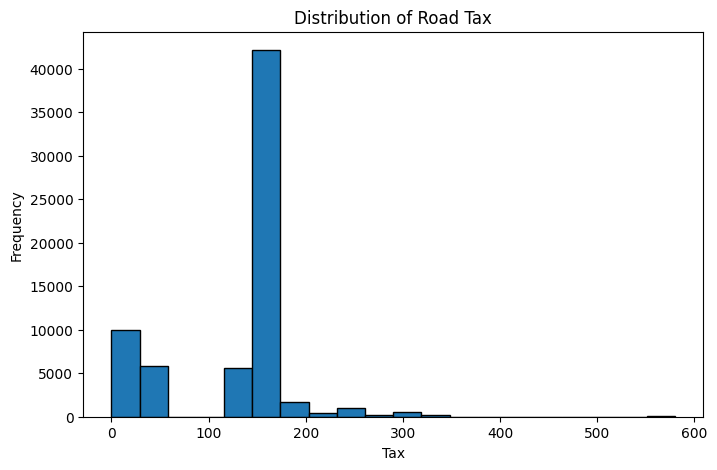

,count
year,
4,1675
3,1046
5,827
6,391
7,221
8,29
9,20
10,8
11,5


In [19]:
# =========================================
# Tax feature — Exploration and preprocessing
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# ---- Zero tax values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Tax — zero values</b>
</div>
"""))
display(df[df["tax"] == 0])


# ---- Helper: assign impossible values to NaN
def impossible_to_nan(df, col, val=0, lower_upper="lower"):
    df = df.copy()

    if lower_upper == "lower":
        df.loc[df[col] < val, col] = np.nan
    else:
        df.loc[df[col] > val, col] = np.nan

    return df


# ---- Apply correction (negative values → NaN)
df = impossible_to_nan(df, "tax")


# ---- Distribution after preprocessing
plt.figure(figsize=(8, 5))
plt.hist(df["tax"].dropna(), bins=20, edgecolor="black")
plt.title("Distribution of Road Tax")
plt.xlabel("Tax")
plt.ylabel("Frequency")
plt.show()


# ---- Interpretation of zero-tax vehicles
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Tax — interpretation of zero values</b><br>
In the UK, road tax cannot be negative. Vehicles with <b>tax = 0</b> typically
correspond to newer, low-emission or electric vehicles.
</div>
"""))

g = df[df["tax"] == 0]
display(g["year"].value_counts())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Negative road tax values were treated as invalid and converted to <b>NaN</b>.
Zero-tax vehicles were retained, as they represent valid cases under UK tax
regulations. The <b>tax</b> feature is now consistent and ready for modeling.
</div>
"""))


## **2.10 `mpg feature`**

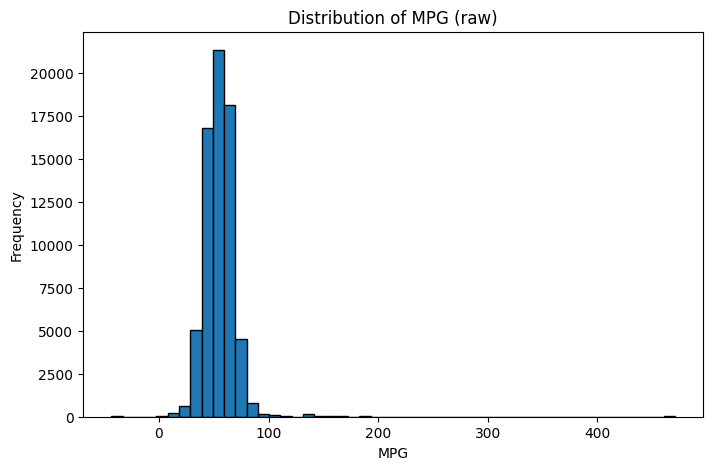

,count
fuelType,
HYBRID,357
DIESEL,63
PETROL,40
OTHER,32
ELECTRIC,2


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,3,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,1,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,4,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
19811,Ford,FOCUS,1,17990,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,3,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0
40757,Mercedes,CCLASS,1,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0


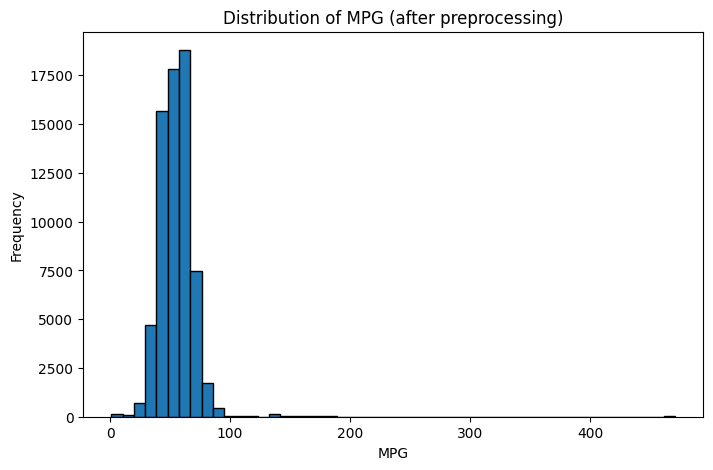

,count
fuelType,
HYBRID,357
DIESEL,63
PETROL,40
OTHER,32
ELECTRIC,2


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
20142,Ford,FOCUS,3,18997,MANUAL,20112.0,PETROL,NaN,NaN,2.0,40.0,4.0,0.0
39796,Mercedes,CCLASS,1,31299,SEMI-AUTO,1000.0,DIESEL,NaN,NaN,2.0,33.0,4.0,0.0
35317,Mercedes,CCLASS,1,26176,NaN,9463.0,PETROL,NaN,NaN,1.5,87.0,1.0,0.0
35004,Mercedes,CCLASS,4,21499,AUTOMATIC,26741.0,DIESEL,NaN,NaN,2.1,80.0,1.0,0.0
19811,Ford,FOCUS,1,17990,AUTOMATIC,3289.0,DIESEL,NaN,NaN,1.5,38.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24300,Ford,FOCUS,3,17000,MANUAL,26041.0,DIESEL,NaN,NaN,2.0,39.0,3.0,0.0
1016,Audi,Q5,4,22995,NaN,28000.0,DIESEL,200.0,NaN,2.0,42.0,4.0,0.0
40757,Mercedes,CCLASS,1,28980,AUTOMATIC,8501.0,DIESEL,NaN,NaN,2.0,97.0,3.0,0.0


In [20]:
# =========================================
# MPG feature — Exploration and preprocessing
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# ---- Distribution of mpg (raw)
plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of MPG (raw)")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.show()


# ---- Interpretation
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>MPG — domain constraints</b><br>
Miles per gallon cannot be negative. Negative values are therefore considered
invalid and will be set to <b>NaN</b>.
</div>
"""))


# ---- High mpg inspection
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>MPG — unusually high values</b><br>
Vehicles with very high MPG values are inspected by fuel type.
</div>
"""))
display(df[df["mpg"] >= 100]["fuelType"].value_counts())


# ---- Missing values (before)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>MPG — missing values (before)</b>
</div>
"""))
display(df[df["mpg"].isna()])


# ---- Apply correction (negative values → NaN)
df = impossible_to_nan(df, "mpg")


# ---- Distribution after preprocessing
plt.figure(figsize=(8, 5))
plt.hist(df["mpg"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of MPG (after preprocessing)")
plt.xlabel("MPG")
plt.ylabel("Frequency")
plt.show()


# ---- High mpg inspection (after)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>MPG — high values after preprocessing</b>
</div>
"""))
display(df[df["mpg"] >= 100]["fuelType"].value_counts())


# ---- Missing values (after)
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>MPG — missing values (after)</b>
</div>
"""))
display(df[df["mpg"].isna()])


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Negative MPG values were identified as invalid and converted to <b>NaN</b>.
Very high MPG values were retained, as they are consistent with hybrid and
electric vehicles. The <b>mpg</b> feature is now clean and suitable for
imputation and scaling within the machine learning pipeline.
</div>
"""))


## **2.11 engineSize feature**

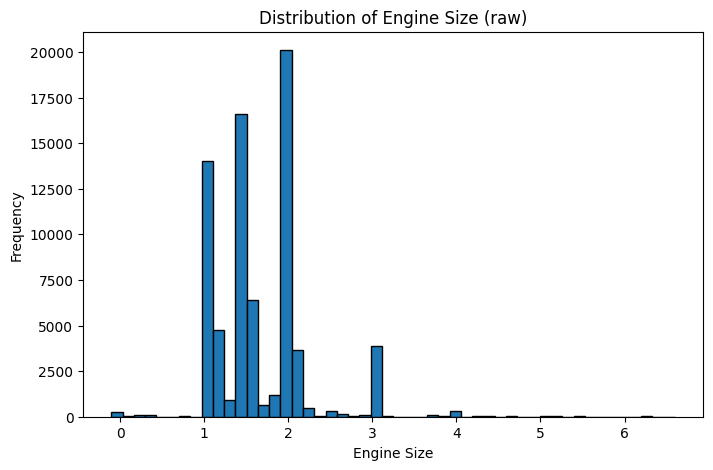

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
61006,Opel,CORSA,1,9995,MANUAL,4366.0,PETROL,150.0,43.5,0.739534,66.0,3.0,0.0
30317,Ford,None,1,9999,MANUAL,10000.0,PETROL,145.0,47.9,0.000000,61.0,3.0,0.0
24113,Ford,KUGA,<NA>,14950,MANUAL,13411.0,DIESEL,125.0,60.1,-0.103493,83.0,1.0,0.0
3840,Audi,None,1,21262,MANUAL,4868.0,DIESEL,145.0,49.6,0.154529,58.0,2.0,0.0
21935,Ford,KA,2,8444,MANUAL,17000.0,PETROL,145.0,57.7,0.000000,51.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
46732,Skoda,OCTAVIA,2,11290,MANUAL,20047.0,PETROL,145.0,58.9,0.191462,98.0,0.0,0.0
38494,Mercedes,GLCLASS,4,19498,SEMI-AUTO,27846.0,DIESEL,125.0,56.5,0.307074,89.0,4.0,0.0
59040,Opel,GRANDLANDX,1,17289,MANUAL,14421.0,DIESEL,145.0,56.5,0.739534,74.0,0.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,1,13295,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0
38898,Mercedes,GLCLASS,3,28995,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0
54844,Toyota,AYGO,3,7299,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0
57086,Opel,INSIGNIA,3,7695,MANUAL,51840.0,DIESEL,0.0,74.3,NaN,76.0,2.0,0.0
70418,NaN,GOLF,4,16898,MANUAL,24180.0,DIESEL,20.0,67.3,NaN,83.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
68840,VW,POLO,1,14999,MANUAL,4436.0,PETROL,150.0,52.3,NaN,98.0,2.0,0.0
61373,Opel,ASTRA,3,10800,MANUAL,19025.0,PETROL,125.0,50.4,NaN,36.0,0.0,0.0
68148,VW,GOLF,0,20769,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
38980,Mercedes,CCLASS,7,23000,SEMI-AUTO,43442.000000,PETROL,NaN,NaN,6.2,76.0,0.0,0.0
46372,Mercedes,CCLASS,7,22995,SEMI-AUTO,49964.000000,PETROL,NaN,23.0,6.2,78.0,3.0,0.0
9197,BMW,7SERIES,3,57000,AUTOMATIC,11297.000000,PETROL,145.000000,22.1,6.6,68.0,1.0,0.0
42286,Mercedes,CCLASS,6,26998,SEMI-AUTO,24175.000000,PETROL,NaN,NaN,6.2,93.0,2.0,0.0
39900,Mercedes,CCLASS,6,28990,SEMI-AUTO,19562.000000,PETROL,NaN,NaN,6.2,83.0,0.0,0.0
39852,Mercedes,SCLASS,10,26990,AUTOMATIC,38000.000000,PETROL,570.000000,19.5,6.2,76.0,4.0,0.0
35612,Mercedes,CCLASS,7,23990,AUTOMATIC,NaN,PETROL,570.000000,23.5,6.2,44.0,2.0,0.0
36196,Mercedes,CCLASS,6,25885,SEMI-AUTO,86705.854885,PETROL,NaN,NaN,6.2,31.0,0.0,0.0
35538,NaN,CCLASS,<NA>,22995,SEMI-AUTO,49964.000000,PETROL,326.028233,NaN,6.2,58.0,3.0,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
carID,,,,,,,,,,,,,
48622,Skoda,FABIA,1,13295,AUTOMATIC,14378.0,PETROL,145.0,60.1,NaN,59.0,1.0,0.0
38898,Mercedes,GLCLASS,3,28995,AUTOMATIC,30808.0,DIESEL,150.0,56.5,NaN,60.0,1.0,0.0
30317,Ford,None,1,9999,MANUAL,10000.0,PETROL,145.0,47.9,NaN,61.0,3.0,0.0
54844,Toyota,AYGO,3,7299,MANUAL,48238.0,PETROL,0.0,68.9,NaN,80.0,0.0,0.0
57086,Opel,INSIGNIA,3,7695,MANUAL,51840.0,DIESEL,0.0,74.3,NaN,76.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
70592,VW,CADDYMAXI,5,9995,SEMI-AUTO,66000.0,DIESEL,200.0,48.7,NaN,34.0,3.0,0.0
68148,VW,GOLF,0,20769,MANUAL,1116.0,PETROL,145.0,49.6,NaN,86.0,4.0,0.0
10627,BMW,3SERIES,0,24990,SEMI-AUTO,22.0,DIESEL,150.0,54.3,NaN,90.0,1.0,0.0


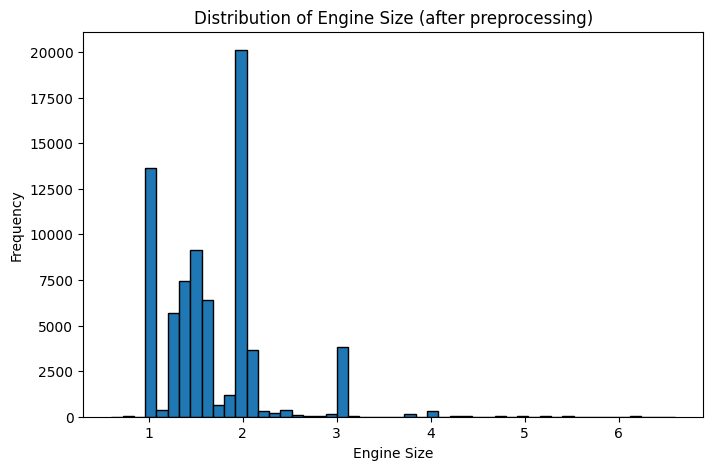

In [21]:
# =========================================
# EngineSize feature — Exploration
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# ---- Distribution of engineSize (raw)
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Engine Size (raw)")
plt.xlabel("Engine Size")
plt.ylabel("Frequency")
plt.show()


# ---- Suspiciously small engine sizes
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>EngineSize — values below 1.0</b>
</div>
"""))
display(df[df["engineSize"] < 1])


# ---- Missing values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>EngineSize — missing values</b>
</div>
"""))
display(df[df["engineSize"].isna()])


# ---- Extremely large engine sizes
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>EngineSize — values above 6.0</b>
</div>
"""))
display(df[df["engineSize"] > 6])


# ---- Apply domain-based correction
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>EngineSize — domain constraint</b><br>
The smallest realistic engine sizes are approximately between <b>0.6</b> and
<b>1.0</b> liters. Values below this threshold are treated as invalid inputs and
set to <b>NaN</b>.
</div>
"""))

df = impossible_to_nan(df, "engineSize", 0.6)


# ---- Missing values after preprocessing
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>EngineSize — missing values after preprocessing</b>
</div>
"""))
display(df[df["engineSize"].isna()])


# ---- Distribution after preprocessing
plt.figure(figsize=(8, 5))
plt.hist(df["engineSize"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Engine Size (after preprocessing)")
plt.xlabel("Engine Size")
plt.ylabel("Frequency")
plt.show()


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Unrealistic engine size values were identified using domain knowledge and
converted to <b>NaN</b>. After preprocessing, the <b>engineSize</b> feature
exhibits a coherent distribution and is suitable for numerical imputation
and scaling within the machine learning pipeline.
</div>
"""))


## **2.12 Preprocessing paintQuality%**

In [22]:
# =========================================
# paintQuality% feature — Removal
# =========================================

from IPython.display import display, HTML

# ---- Feature removal rationale
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>paintQuality% — feature removal</b><br>
This feature is removed in accordance with the assignment instructions.
The model should only rely on information available to a customer without
requiring a mechanical inspection.
</div>
"""))


# ---- Helper: drop paintQuality%
def drop_paint(df):
    df = df.copy()
    df = df.drop(columns=["paintQuality%"], errors="ignore")
    return df


# ---- Apply removal
df = drop_paint(df)


# ---- Sanity check
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>paintQuality% — verification</b><br>
The feature has been successfully removed from the dataset.
</div>
"""))

display(df.head())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
The <b>paintQuality%</b> feature was excluded to ensure the model only uses
customer-accessible information, improving realism and applicability of
the price prediction task.
</div>
"""))


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,,
69512,VW,GOLF,4,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,4.000000,0.0
53000,Toyota,YARIS,1,13790,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,1.000000,0.0
6366,Audi,Q2,1,24990,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,4.000000,0.0
29021,Ford,FIESTA,2,12500,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,-2.340306,0.0
10062,BMW,2SERIES,1,22995,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,3.000000,0.0


## **2.13 previousOwners features**

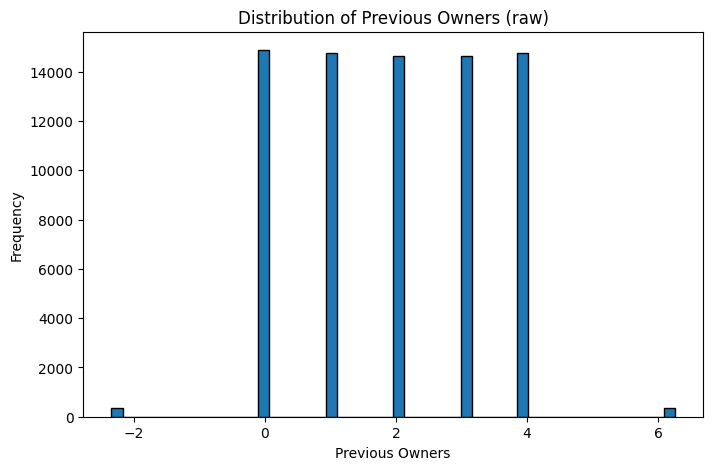

array([ 4.        ,  1.        , -2.34030622,  3.        ,  0.        ,
        2.        ,         nan, -2.34565   ,  6.25837066, -2.33512284,
        6.22789796,  6.25823052,  6.23017958, -2.33936045,  6.21772443,
        6.24583495, -2.29943868, -2.34010209, -2.31225953,  6.2482512 ,
       -2.31733109,  6.23308217,  6.24177863, -2.33744529])

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,,
29021,Ford,FIESTA,2,12500,MANUAL,9102.0,PETROL,145.0,65.7,1.0,-2.340306,0.0
71677,VW,TIGUAN,1,29999,SEMI-AUTO,669.0,DIESEL,145.0,39.8,2.0,-2.345650,0.0
16962,Ford,FOCUS,1,19950,AUTOMATIC,7142.0,DIESEL,NaN,NaN,2.0,-2.340306,0.0
5994,Audi,None,0,31990,SEMI-AUTO,4432.0,PETROL,150.0,40.4,1.5,-2.335123,0.0
5038,Audi,RS6,0,97500,SEMI-AUTO,3220.0,PETROL,150.0,22.1,4.0,-2.335123,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
67526,VW,PASSAT,0,20998,SEMI-AUTO,15.0,DIESEL,145.0,49.6,1.6,-2.345650,0.0
75599,VW,UP,5,6795,MANUAL,10800.0,PETROL,20.0,61.4,1.0,-2.345650,0.0
28295,Ford,SMAX,3,17950,MANUAL,28280.0,PETROL,145.0,43.5,1.5,-2.340306,0.0


,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,hasDamage
carID,,,,,,,,,,,,
35263,Mercedes,CCLASS,<NA>,11295,AUTOMATIC,45000.0,PETROL,NaN,46.3,1.6,NaN,0.0
18304,Ford,None,4,9632,MANUAL,18814.0,PETROL,20.0,62.8,1.0,NaN,0.0
49135,Skoda,SCALA,0,17000,MANUAL,731.0,PETROL,150.0,50.4,1.0,NaN,0.0
37446,Mercedes,CCLASS,1,27099,SEMI-AUTO,1059.0,PETROL,145.0,45.6,1.5,NaN,0.0
1768,Audi,Q3,0,35990,SEMI-AUTO,6000.0,DIESEL,145.0,47.1,2.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
301,Audi,A7,6,19499,AUTOMATIC,47317.0,DIESEL,145.0,54.3,3.0,NaN,0.0
6295,Audi,A3,2,17650,MANUAL,6350.0,PETROL,150.0,55.4,1.5,NaN,0.0
21918,Ford,FIESTA,1,13998,MANUAL,10576.0,PETROL,145.0,58.9,1.0,NaN,0.0


<IntegerArray>
[4, 1, <NA>, 3, 0, 2, 6]
Length: 7, dtype: Int64

In [23]:
# =========================================
# previousOwners feature — Exploration and preprocessing
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- Distribution of previousOwners (raw)
plt.figure(figsize=(8, 5))
plt.hist(df["previousOwners"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Previous Owners (raw)")
plt.xlabel("Previous Owners")
plt.ylabel("Frequency")
plt.show()


# ---- Unique values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>previousOwners — unique values</b>
</div>
"""))
display(df["previousOwners"].unique())


# ---- Invalid negative values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>previousOwners — invalid negative values</b>
</div>
"""))
display(df[df["previousOwners"] < 0])


# ---- Missing values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>previousOwners — missing values</b>
</div>
"""))
display(df[df["previousOwners"].isna()])


# ---- Helper: round owners to integer values
def round_owners_int(df):
    df = df.copy()
    df["previousOwners"] = pd.to_numeric(df["previousOwners"], errors="coerce")
    df["previousOwners"] = df["previousOwners"].round().astype("Int64")
    return df


# ---- Apply corrections
df = impossible_to_nan(df, "previousOwners")
df = round_owners_int(df)


# ---- Values after preprocessing
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>previousOwners — after preprocessing</b>
</div>
"""))
display(df["previousOwners"].unique())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Negative values were identified as invalid and converted to <b>NaN</b>.
The <b>previousOwners</b> feature was rounded to integer values, ensuring
a consistent and interpretable representation suitable for modeling.
</div>
"""))


## **2.14 Hasdamage feature**

In [24]:
# =========================================
# hasDamage feature — Removal
# =========================================

from IPython.display import display, HTML

# ---- Unique values
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>hasDamage — unique values</b>
</div>
"""))
display(df["hasDamage"].unique())


# ---- Helper: remove hasDamage feature
def remove_hasdmg(df):
    df = df.copy()
    df = df.drop(columns=["hasDamage"], errors="ignore")
    return df


# ---- Apply removal
df = remove_hasdmg(df)


# ---- Verification
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>hasDamage — verification</b><br>
The feature has been successfully removed from the dataset.
</div>
"""))
display(df.head())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
The <b>hasDamage</b> feature contained a single constant value across all records,
providing no discriminatory power. It was therefore removed to avoid adding noise
and unnecessary dimensionality to the model.
</div>
"""))


array([ 0., nan])

,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners
carID,,,,,,,,,,,
69512,VW,GOLF,4,22290,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,4
53000,Toyota,YARIS,1,13790,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,1
6366,Audi,Q2,1,24990,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,4
29021,Ford,FIESTA,2,12500,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,<NA>
10062,BMW,2SERIES,1,22995,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,3


## **2.15 Price exploration and separation**

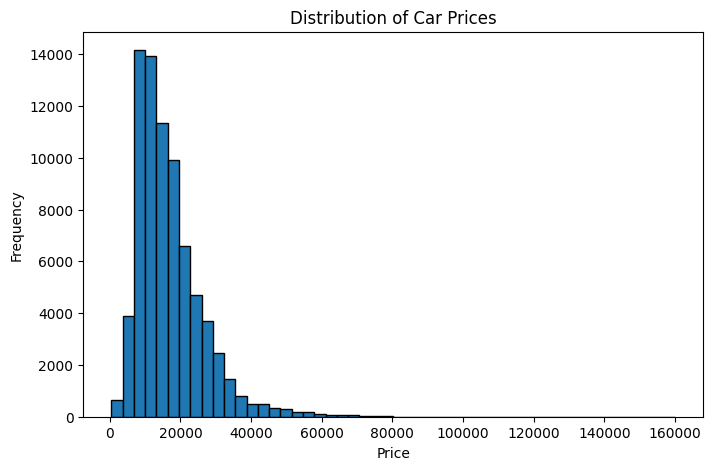

,price
count,75973.000000
mean,16881.889553
std,9736.926322
min,450.000000
25%,10200.000000
50%,14699.000000
75%,20950.000000
max,159999.000000


,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners
carID,,,,,,,,,,
69512,VW,GOLF,4,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,4
53000,Toyota,YARIS,1,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,1
6366,Audi,Q2,1,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,4
29021,Ford,FIESTA,2,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,<NA>
10062,BMW,2SERIES,1,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,3


,price
carID,
69512,22290
53000,13790
6366,24990
29021,12500
10062,22995


In [25]:
# =========================================
# Price (target) — Exploration and separation
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt

# ---- Distribution of price
plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


# ---- Descriptive statistics
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Price — descriptive statistics</b>
</div>
"""))
display(df["price"].describe())


# ---- Helper: separate features and target
def separar_y(df):
    df = df.copy()
    X = df.drop("price", axis=1)
    y = df["price"]
    return X, y


# ---- Apply separation
X, y = separar_y(df)


# ---- Verification
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Feature / target separation</b><br>
<b>X</b> contains all explanatory features.<br>
<b>y</b> contains the target variable (<b>price</b>).
</div>
"""))

display(X.head())
display(y.head())


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
The <b>price</b> variable was explored and validated as the regression target.
The dataset was successfully split into features (<b>X</b>) and target (<b>y</b>),
preparing the data for train/test splitting and pipeline-based modeling.
</div>
"""))


## **2.16 Numerical Features — Histogram, Boxplot and KDE Analysis**


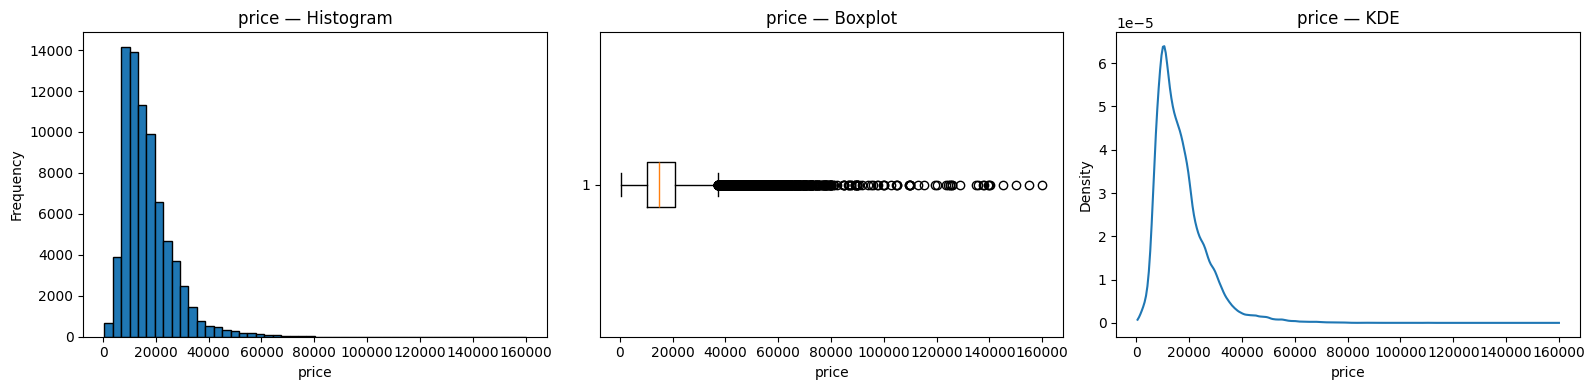

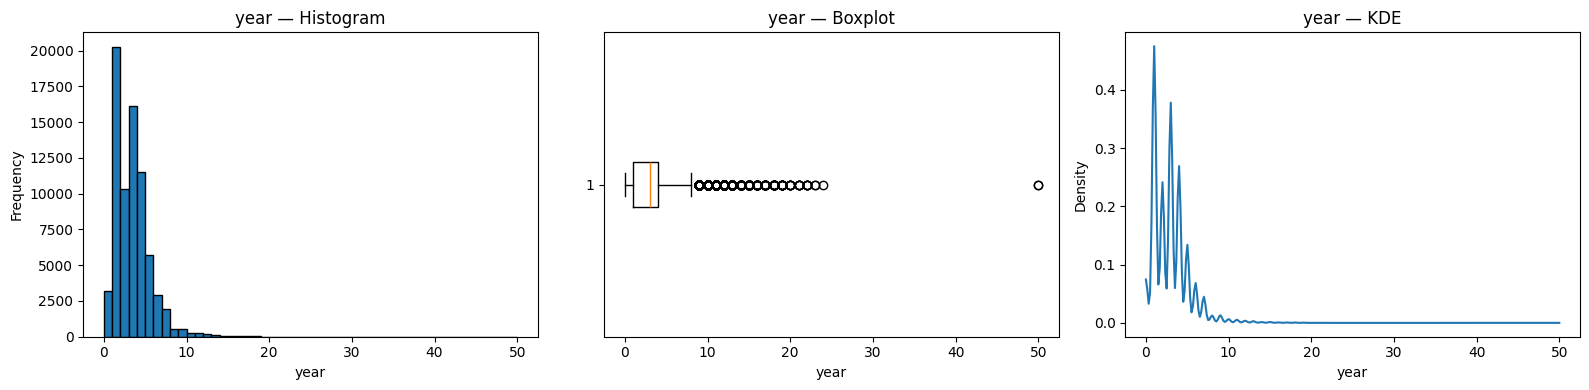

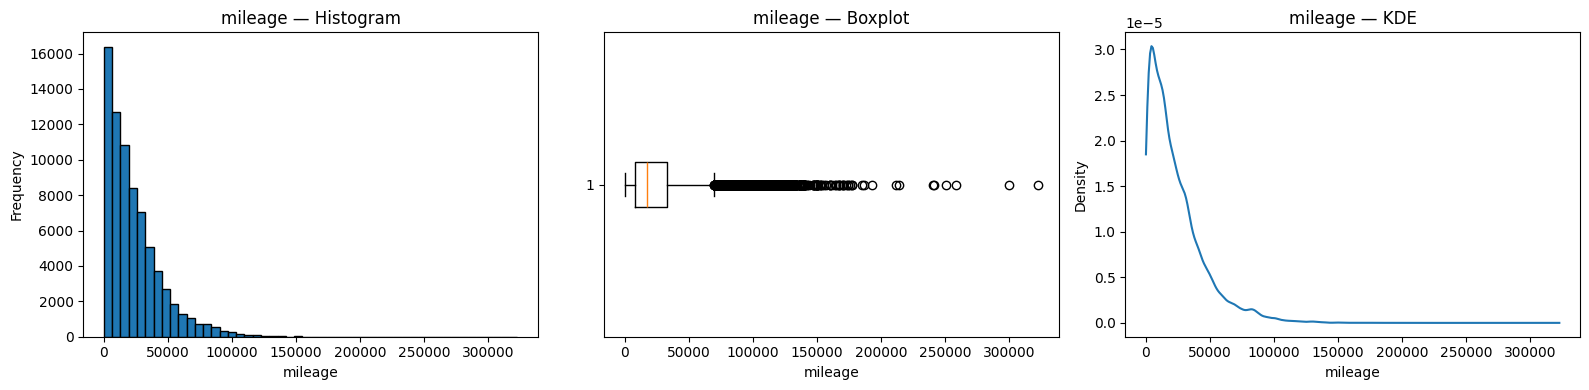

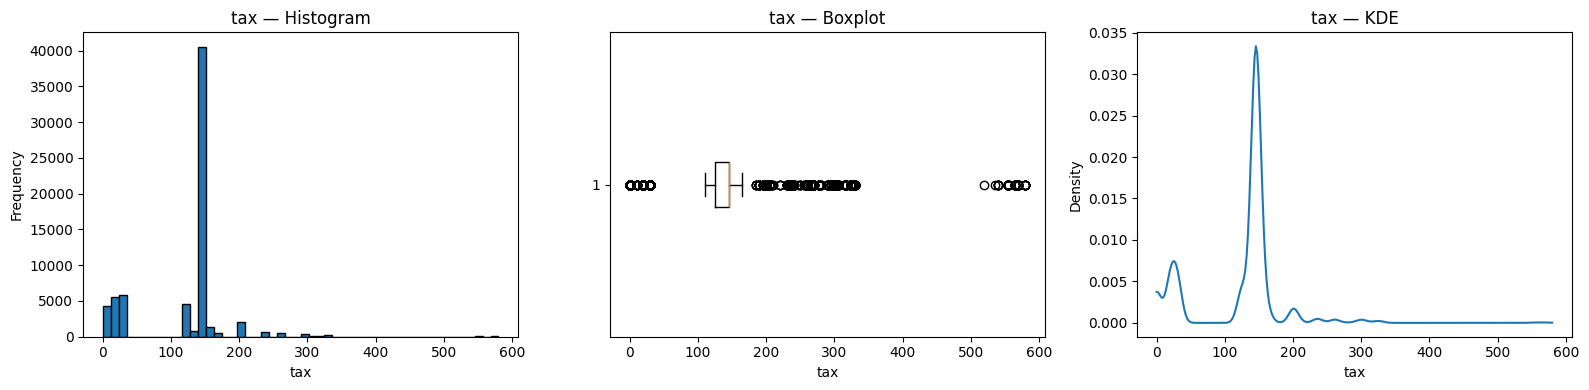

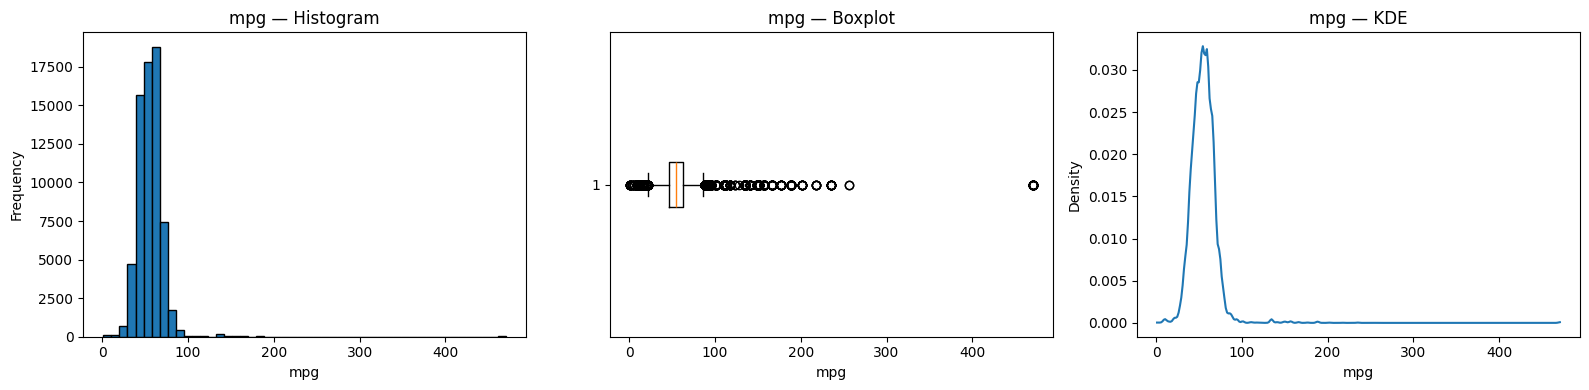

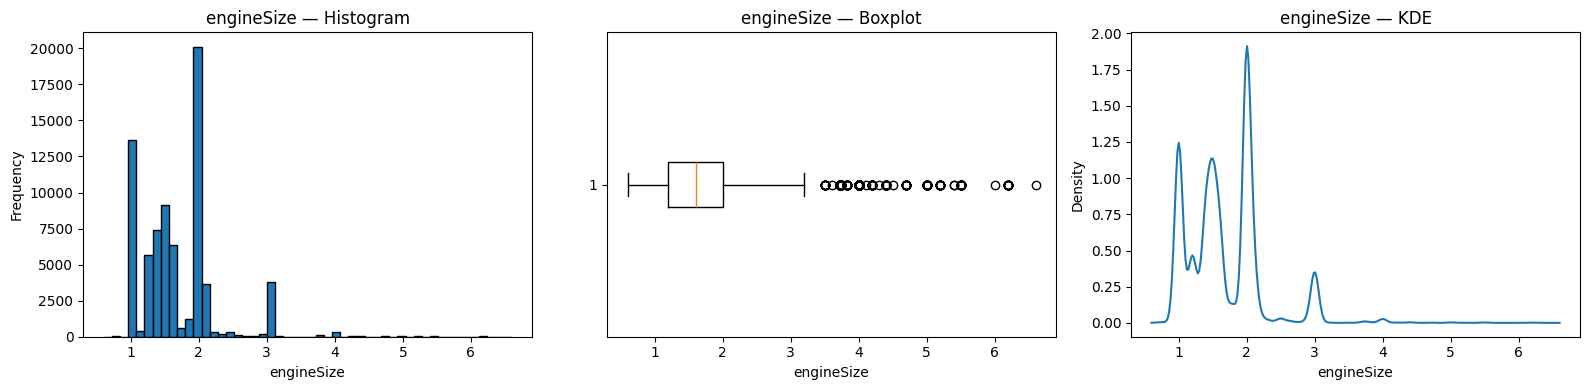

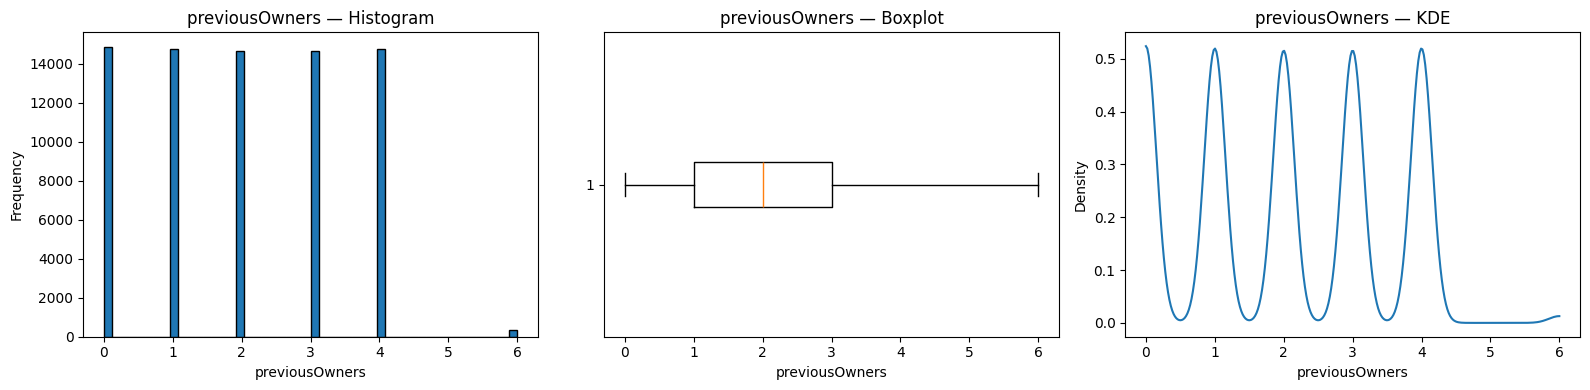

In [26]:
# =========================================
# Numerical Features — Histogram | Boxplot | KDE
# =========================================

from IPython.display import display, HTML
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Univariate analysis — numerical features</b><br><br>
Each row below shows, for a given numerical feature:
<ul>
<li>Histogram (distribution)</li>
<li>Boxplot (dispersion and outliers)</li>
<li>KDE plot (smoothed density)</li>
</ul>
</div>
"""))

# ---- Numerical columns from current pipeline
numeric_cols = [
    "price", "year", "mileage", "tax", "mpg",
    "engineSize", "previousOwners",
    "mileage_per_year", "power_efficiency"
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

# ---- Plot per feature: 1 row × 3 plots
for col in numeric_cols:
    values = df[col].dropna()

    if len(values) < 5:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # ---- Histogram
    axes[0].hist(values, bins=50, edgecolor="black")
    axes[0].set_title(f"{col} — Histogram")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Frequency")

    # ---- Boxplot
    axes[1].boxplot(values, vert=False)
    axes[1].set_title(f"{col} — Boxplot")
    axes[1].set_xlabel(col)

    # ---- KDE
    kde = gaussian_kde(values)
    x_vals = np.linspace(values.min(), values.max(), 300)
    axes[2].plot(x_vals, kde(x_vals))
    axes[2].set_title(f"{col} — KDE")
    axes[2].set_xlabel(col)
    axes[2].set_ylabel("Density")

    plt.tight_layout()
    plt.show()

# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Conclusion</b><br><br>
This layout enables direct visual comparison of distribution shape, dispersion,
and density for each numerical feature.<br><br>

The analysis confirms skewness and outliers in several variables, justifying the
use of robust scaling and pipeline-based preprocessing rather than manual clipping.
</div>
"""))




# **3. Missing Values Analysis & Handling**


In [27]:
# =========================================
# Missing values — Analysis and handling
# =========================================

from IPython.display import display, HTML
import pandas as pd

# ---- Missing values summary
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Missing values — overview</b><br>
Number and percentage of missing values per feature.
</div>
"""))

missing = df.isnull().sum().sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": (missing / len(df)) * 100
})

display(missing_df)


# ---- Helper: fill categorical missing values with UNKNOWN
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Categorical missing values — handling strategy</b><br>
Missing values in categorical features are explicitly filled with
<b>UNKNOWN</b> to preserve information and avoid data leakage.
</div>
"""))

def fill_cats_UNKNOWN(df, cats):
    df = df.copy()
    for column in cats:
        df[column] = df[column].fillna("UNKNOWN")
    return df


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:8px; border-radius:6px; border-left:5px solid #1f77ff;">
<b>Conclusion</b><br>
Missing values were systematically analysed across all features.
Categorical missing values are handled explicitly using the <b>UNKNOWN</b>
category, while numerical missing values are intentionally left for
imputation within the machine learning pipeline.
</div>
"""))


,Missing Count,Missing Percentage
tax,8282,10.901241
mpg,7962,10.480039
engineSize,2034,2.677267
previousOwners,1921,2.528530
year,1849,2.433759
mileage,1832,2.411383
model,1578,2.077054
transmission,1522,2.003343
Brand,1521,2.002027
fuelType,1511,1.988864


# **4. Feature Engineering**


,mileage_per_year,power_efficiency
carID,,
69512,7105.25,0.175173
53000,4589.0,0.031315
6366,3624.0,0.036675
29021,4551.0,0.015221
10062,1000.0,0.035047


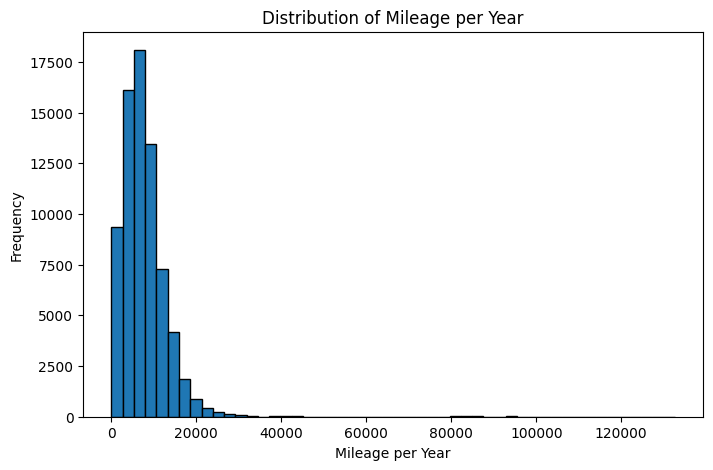

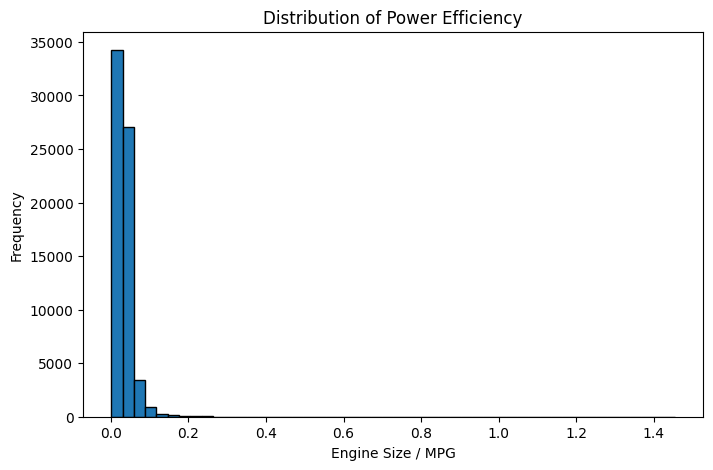

In [28]:
# =========================================
# Feature engineering — mileage_per_year & power_efficiency (ONE BLOCK)
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import numpy as np

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Feature engineering</b><br><br>
We create two additional numerical features to capture (1) vehicle usage intensity and
(2) the relationship between engine size and fuel efficiency.<br><br>
These features can help the model generalize better by providing normalized signals.
</div>
"""))

# ---- Feature: mileage per year
def mileage_per_year(df):
    df = df.copy()
    age_divisor = np.maximum(df["year"], 1)  # avoids division by zero when age == 0
    df["mileage_per_year"] = df["mileage"] / age_divisor
    return df

# ---- Feature: power efficiency
def power_efficiency(df):
    df = df.copy()
    df["power_efficiency"] = df["engineSize"] / df["mpg"]

    # Handle division-by-zero (inf) safely by capping at max finite value
    max_finite = df.loc[np.isfinite(df["power_efficiency"]), "power_efficiency"].max()
    df["power_efficiency"] = df["power_efficiency"].replace([np.inf], max_finite)

    return df

# ---- Apply feature engineering (SEQUENTIAL)
df = mileage_per_year(df)
df = power_efficiency(df)

# ---- Quick preview of engineered features
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Preview</b><br>
Below we inspect the first rows of the newly engineered features.
</div>
"""))
display(df[["mileage_per_year", "power_efficiency"]].head())

# ---- Distribution: mileage_per_year
plt.figure(figsize=(8, 5))
plt.hist(df["mileage_per_year"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Mileage per Year")
plt.xlabel("Mileage per Year")
plt.ylabel("Frequency")
plt.show()

# ---- Distribution: power_efficiency
plt.figure(figsize=(8, 5))
plt.hist(df["power_efficiency"].dropna(), bins=50, edgecolor="black")
plt.title("Distribution of Power Efficiency")
plt.xlabel("Engine Size / MPG")
plt.ylabel("Frequency")
plt.show()

# ---- Column groups for modeling
num_cols = [
    "year", "mileage", "tax", "mpg", "engineSize",
    "previousOwners", "mileage_per_year", "power_efficiency"
]
cat_cols = ["Brand", "model", "transmission", "fuelType"]
int_cols = ["year", "previousOwners"]
float_cols = ["mileage", "tax", "mpg", "engineSize", "mileage_per_year", "power_efficiency"]

# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Conclusion</b><br><br>
The engineered features <b>mileage_per_year</b> and <b>power_efficiency</b> add normalized
signals for vehicle usage and efficiency. We retain both features for modeling, while any
missing values and scaling will be handled later inside the machine learning pipeline.
</div>
"""))


In [29]:
df=fill_cats_UNKNOWN(df, cat_cols)

# **5. Exploratory Data Analysis — Bivariate Analysis of Price and Feature Relationships**


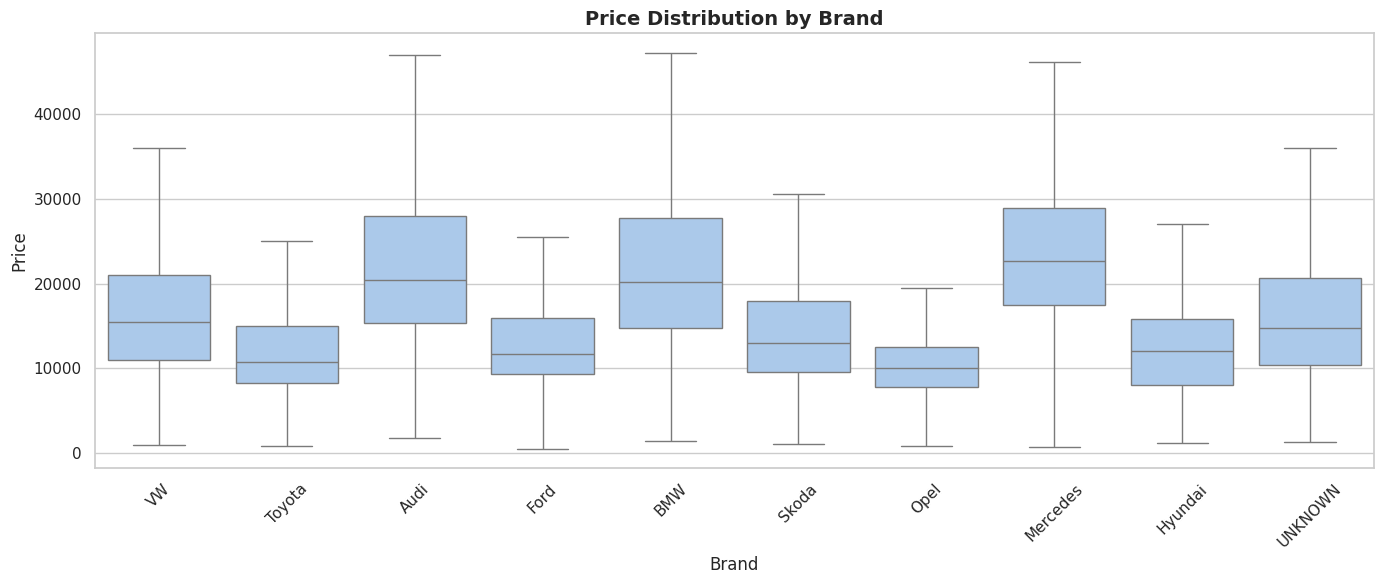

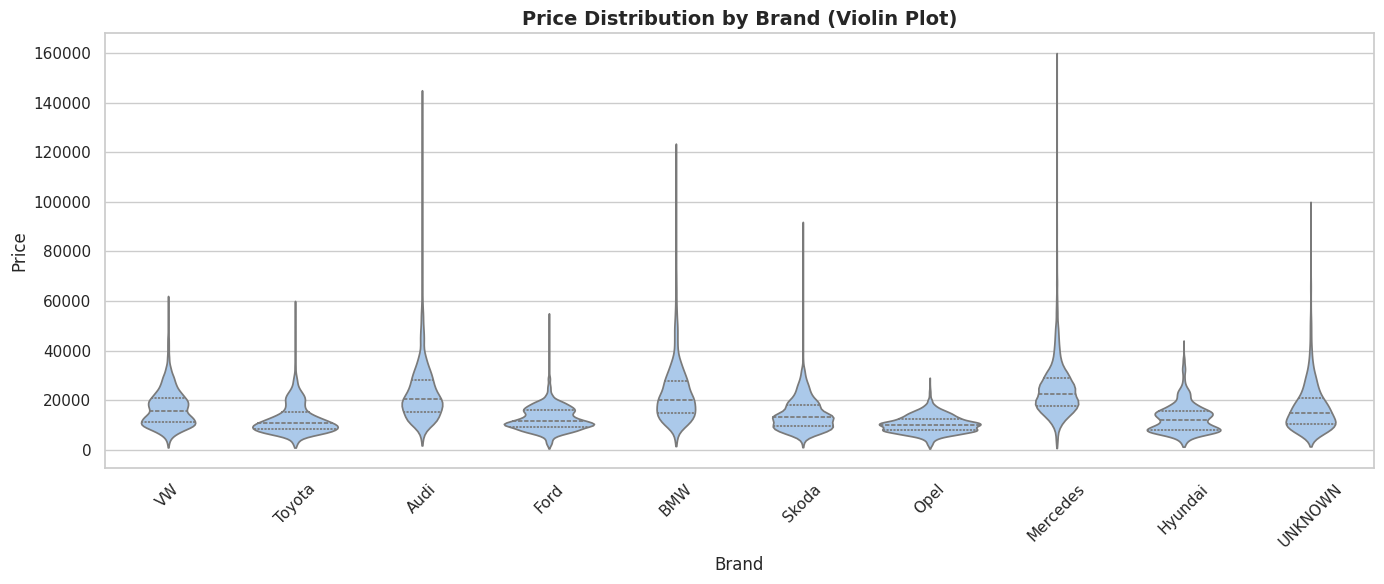

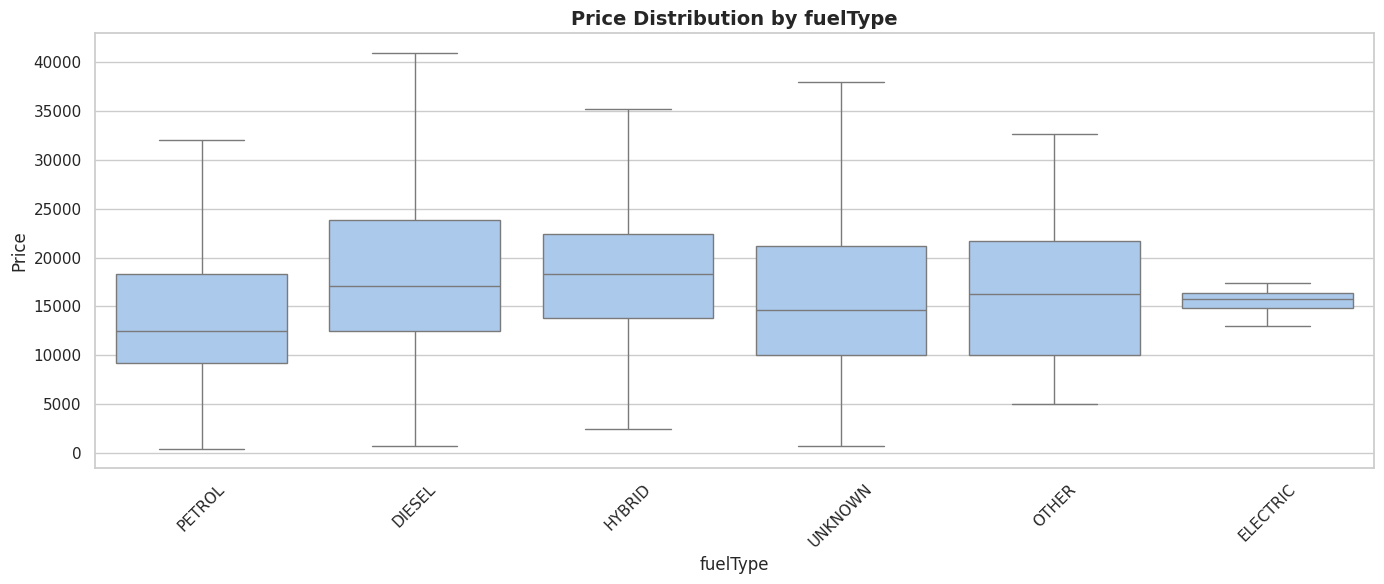

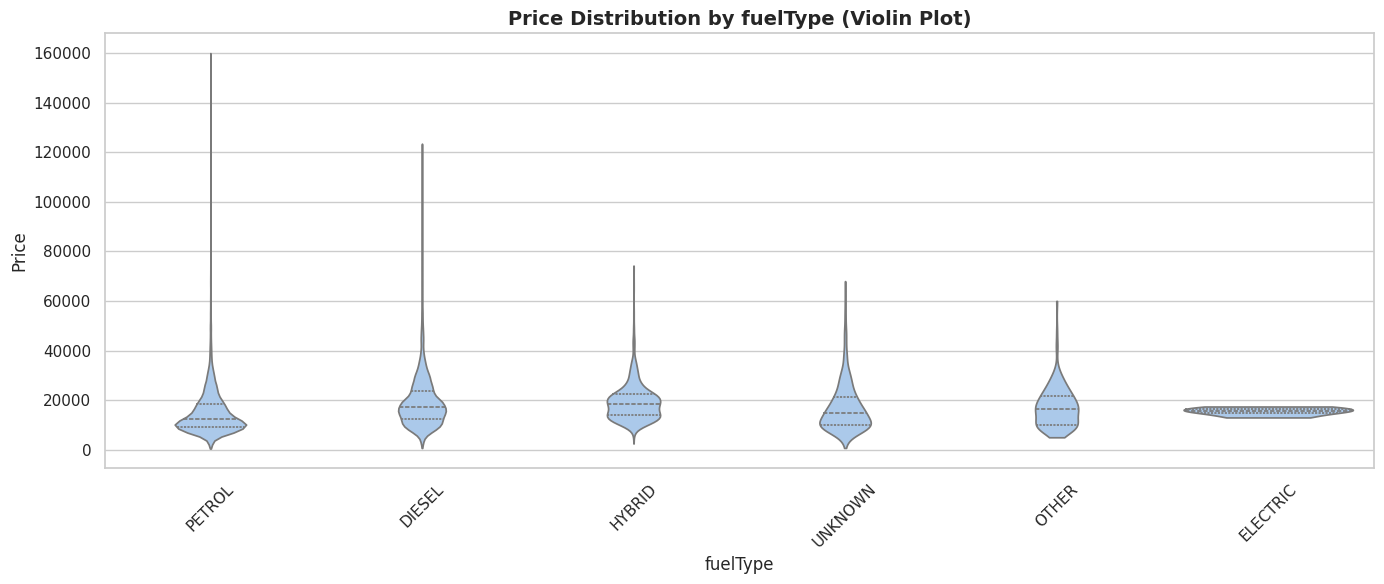

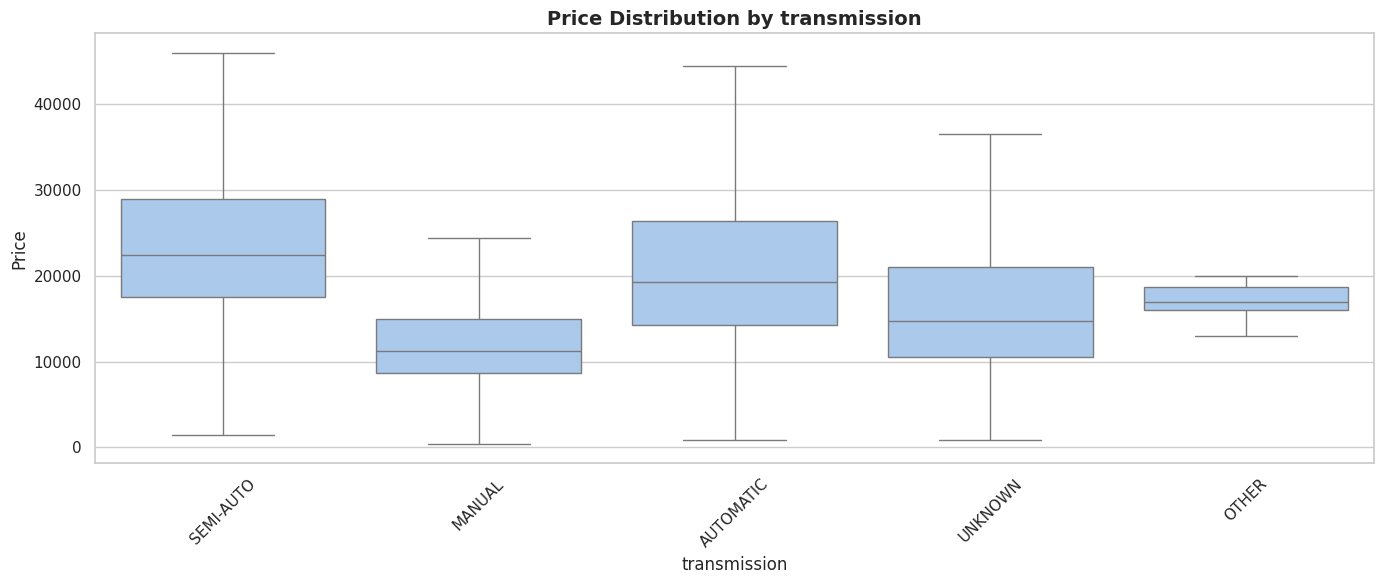

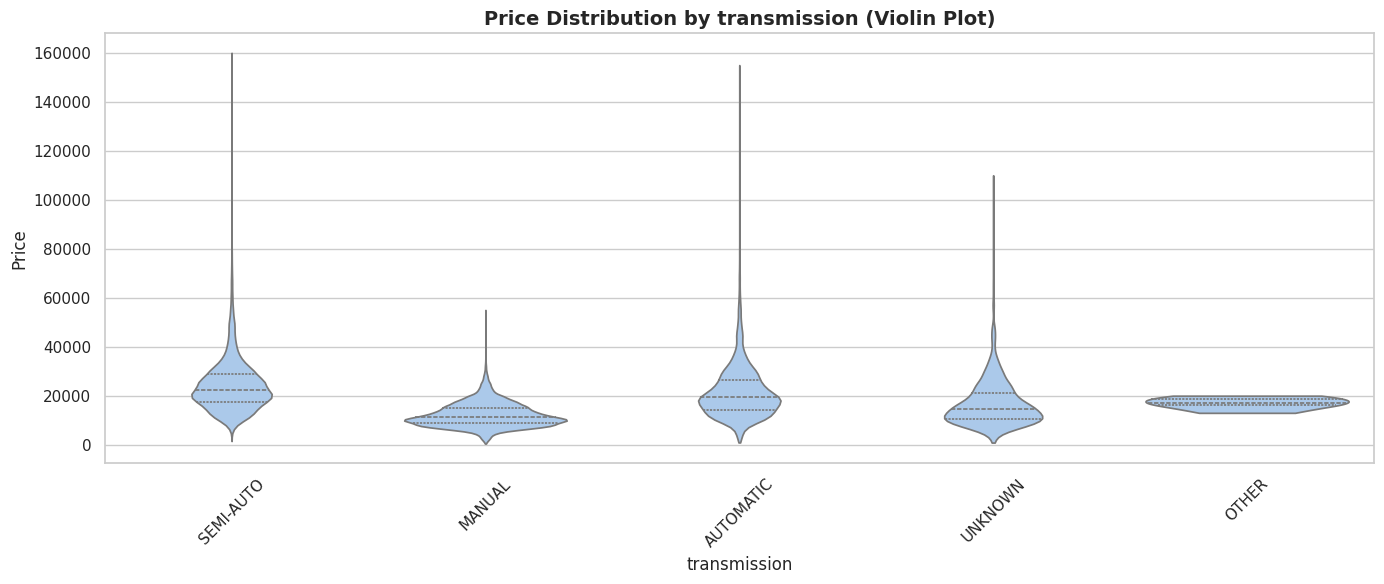

In [30]:
# =========================================
# Bivariate Analysis — Price vs Categorical Features
# =========================================

from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Bivariate analysis — price vs categorical features</b><br><br>
This section explores how vehicle <b>price</b> varies across key categorical
features after preprocessing.<br><br>

Boxplots and violin plots are used to capture both distribution spread and density,
highlighting differences in central tendency and variability between categories.
</div>
"""))

# ---- Categorical features to analyse
categorical_features = ["Brand", "fuelType", "transmission"]

# ---- Plot configuration
sns.set(style="whitegrid", palette="pastel")

# ---- Generate plots
for feature in categorical_features:

    # ---- Boxplot
    plt.figure(figsize=(14, 6))
    sns.boxplot(
        data=df,
        x=feature,
        y="price",
        showfliers=False
    )
    plt.title(f"Price Distribution by {feature}", fontsize=14, fontweight="bold")
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # ---- Violin plot
    plt.figure(figsize=(14, 6))
    sns.violinplot(
        data=df,
        x=feature,
        y="price",
        inner="quartile",
        cut=0
    )
    plt.title(f"Price Distribution by {feature} (Violin Plot)", fontsize=14, fontweight="bold")
    plt.xlabel(feature)
    plt.ylabel("Price")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Conclusion</b><br><br>
Vehicle price shows clear dependency on categorical attributes such as
<b>Brand</b>, <b>fuelType</b>, and <b>transmission</b>.<br><br>

Several categories exhibit distinct price distributions and variability,
confirming the importance of proper categorical encoding and justifying
their inclusion in the predictive modeling pipeline.
</div>
"""))


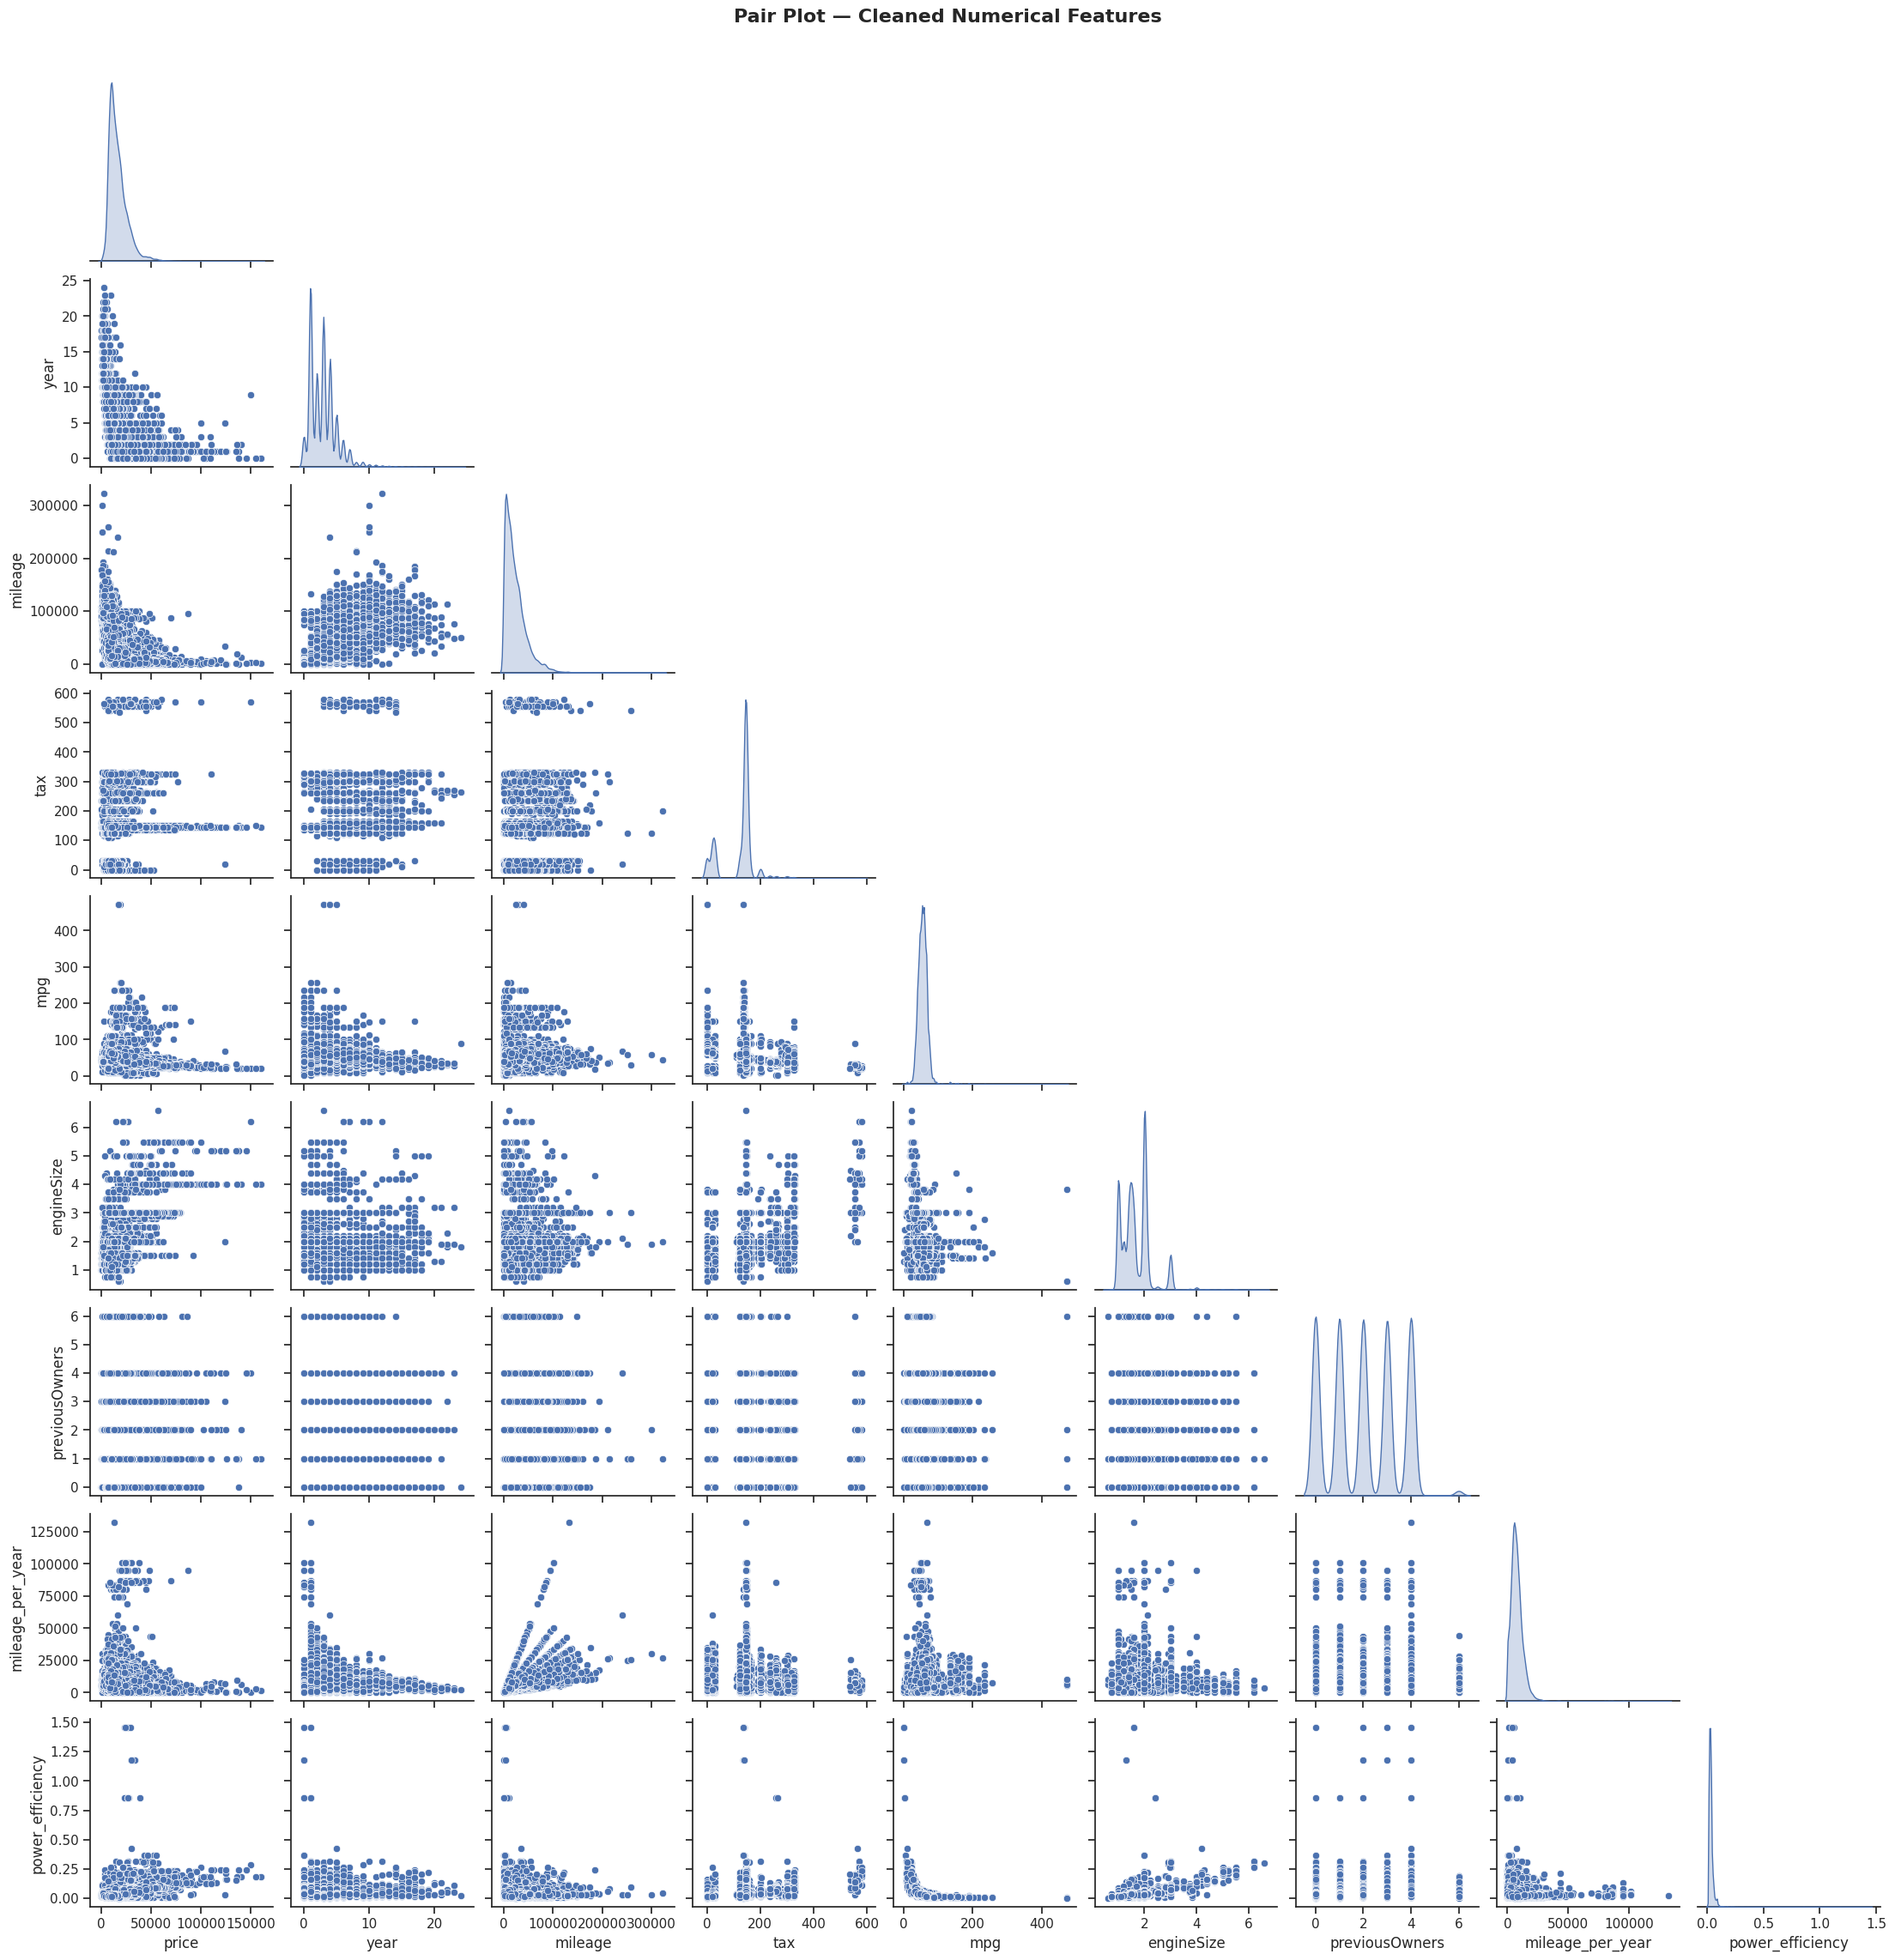

In [31]:
# =========================================
# Numerical features — Pair plot exploration
# =========================================

from IPython.display import display, HTML
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Pair plot — numerical feature relationships</b><br><br>
This visualization explores pairwise relationships between cleaned numerical
features, helping identify linear trends, non-linear patterns, and potential
collinearity before modeling.
</div>
"""))

# ---- Numerical features consistent with pipeline
numeric_cols = [
    "price", "year", "mileage", "tax", "mpg",
    "engineSize", "previousOwners",
    "mileage_per_year", "power_efficiency"
]

numeric_cols = [c for c in numeric_cols if c in df.columns]

display(HTML(f"""
<b>Numerical features included ({len(numeric_cols)}):</b><br>
{", ".join(numeric_cols)}
"""))

# ---- Drop rows with missing numerical values (required for pairplot)
pairplot_df = df[numeric_cols].dropna()

# ---- Aesthetics
sns.set(style="ticks", context="notebook")

# ---- Pair plot
pair_plot = sns.pairplot(
    pairplot_df,
    diag_kind="kde",
    corner=True
)

pair_plot.fig.suptitle(
    "Pair Plot — Cleaned Numerical Features",
    fontsize=16,
    fontweight="bold",
    y=1.02
)

plt.show()

# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Conclusion</b><br><br>
The pair plot highlights relationships between numerical variables, revealing
expected correlations (e.g. mileage vs mileage_per_year) and potential
redundancies.<br><br>

These insights inform feature selection and motivate the use of regularization
and scaling within the modeling pipeline.
</div>
"""))


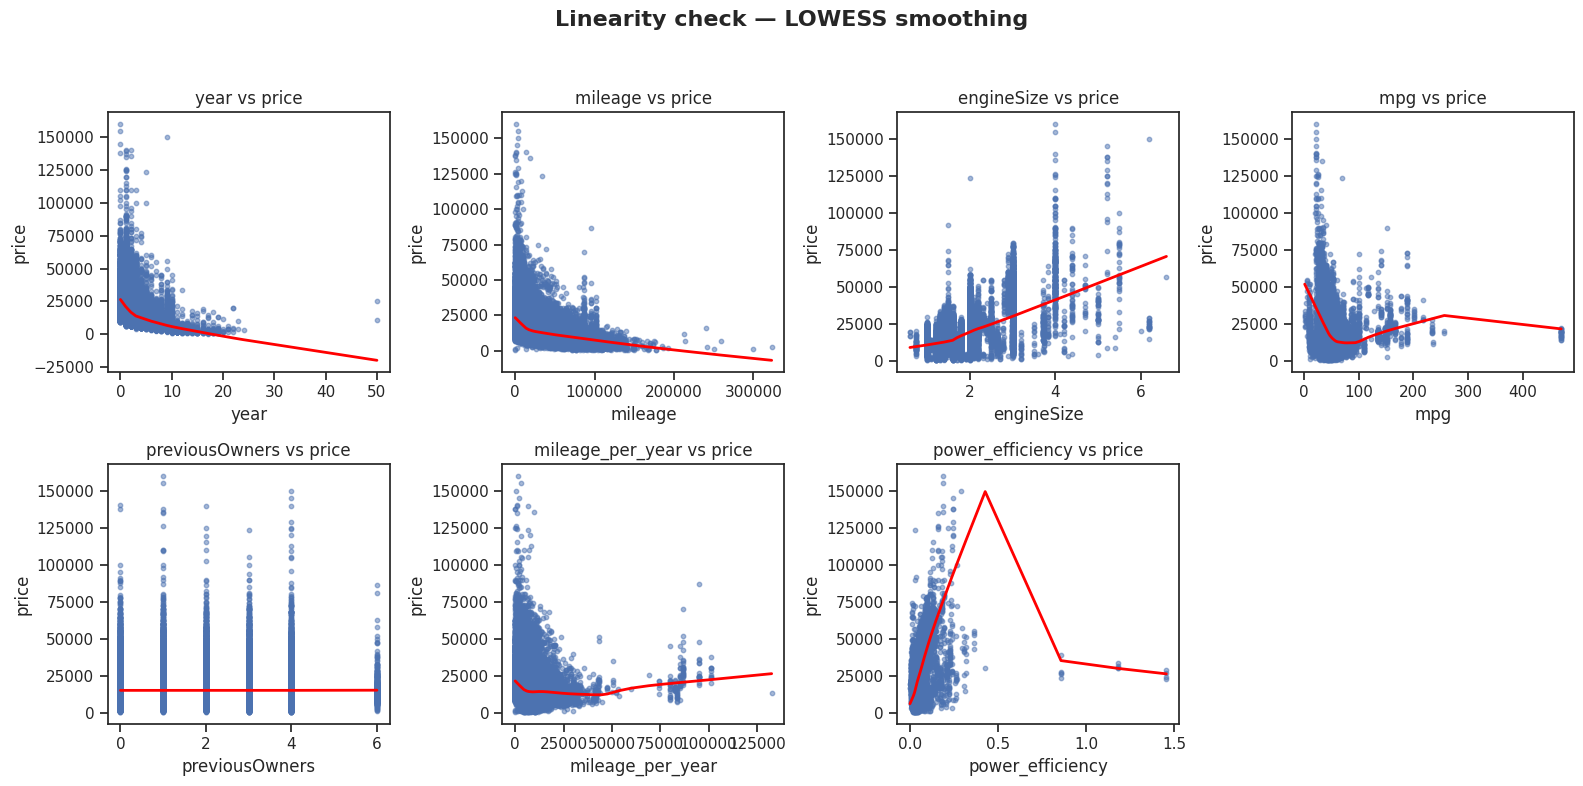

In [32]:
# =========================================
# Numerical features — Linearity check vs price
# =========================================

from IPython.display import display, HTML
import seaborn as sns
import matplotlib.pyplot as plt
import math

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Linearity assessment — numerical features vs price</b><br><br>
This section evaluates the relationship between numerical features and the target
variable (<b>price</b>) using LOWESS smoothing.<br><br>

The goal is to visually assess linearity assumptions and identify features that
may benefit from transformation or non-linear models.
</div>
"""))

# ---- Numerical features consistent with preprocessing pipeline
numeric_features = [
    "year",
    "mileage",
    "engineSize",
    "mpg",
    "previousOwners",
    "mileage_per_year",
    "power_efficiency"
]

numeric_features = [f for f in numeric_features if f in df.columns]

display(HTML(f"""
<b>Features evaluated ({len(numeric_features)}):</b><br>
{", ".join(numeric_features)}
"""))

# ---- Plot grid configuration
sp_rows = 2
sp_cols = math.ceil(len(numeric_features) / sp_rows)

fig, axes = plt.subplots(sp_rows, sp_cols, figsize=(16, 8))
axes = axes.flatten()

sns.set(style="whitegrid")

# ---- LOWESS regression plots
for ax, feat in zip(axes, numeric_features):
    sns.regplot(
        x=df[feat],
        y=df["price"],
        lowess=True,
        ax=ax,
        scatter_kws={"s": 10, "alpha": 0.5},
        line_kws={"color": "red", "lw": 2}
    )
    ax.set_title(f"{feat} vs price")
    ax.set_xlabel(feat)
    ax.set_ylabel("price")

# ---- Remove unused axes
for i in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[i])

plt.suptitle(
    "Linearity check — LOWESS smoothing",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ---- Conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Conclusion</b><br><br>
Several numerical features show non-linear relationships with <b>price</b>,
particularly mileage-based and efficiency-related variables.<br><br>

This motivates the use of feature scaling, engineered variables, and potentially
regularized or non-linear models rather than relying solely on strict linear
assumptions.
</div>
"""))


# **6. Final cleaning Pipeline**

In [33]:
from valid_models import valid_models


In [34]:
# =========================================
# Final preprocessing pipeline — Consolidation
# =========================================

from IPython.display import display, HTML
import pandas as pd

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Final preprocessing pipeline</b><br><br>
All previously defined data cleaning and feature engineering steps are now
consolidated into a single reusable function.<br><br>

This ensures a consistent, ordered, and reproducible preprocessing workflow
that can be safely reused for training, validation, and inference.
</div>
"""))

# ---- Unified preprocessing function
def clean_df(df, valid_models, cat_cols):
    df = df.copy()
    df = carID_como_index(df)
    df = fuzzy_marcas(df)
    df = fuzzy_modelos(df, valid_models)
    df = limpar_anos(df)
    df = fuzzy_transmissao(df)
    df = impossible_to_nan(df, "mileage")
    df = mileage_per_year(df)
    df = fuzzy_fuel(df)
    df = impossible_to_nan(df, "tax")
    df = impossible_to_nan(df, "mpg")
    df = impossible_to_nan(df, "engineSize", 0.6)
    df = power_efficiency(df)
    df = drop_paint(df)
    df = impossible_to_nan(df, "previousOwners")
    df = round_owners_int(df)
    df = remove_hasdmg(df)
    df = fill_cats_UNKNOWN(df, cat_cols)
    return df


# ---- Apply final preprocessing pipeline
og_df = clean_df(og_df, valid_models, cat_cols)

# ---- Validation check
assert pd.testing.assert_frame_equal(df, og_df) is None


# ---- Section conclusion
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Conclusion</b><br><br>
The assertion confirms that the consolidated preprocessing pipeline produces
exactly the same dataset as the step-by-step preprocessing performed earlier.<br><br>

This validates the correctness of the pipeline and guarantees a consistent,
leakage-free data preparation stage for all subsequent modeling steps.
</div>
"""))


acess that all function were applied the same way as in clean_df.

# **7. Feature Selection**

## **7.1 Target Separation — Features (X) and Price (y)**


In [37]:
def separar_y(df):
    df=df.copy()

    X = df.drop('price', axis = 1)
    y = df['price']

    return X, y
X, y = separar_y(df)
X

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,
69512,VW,GOLF,4,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,4,7105.25,0.175173
53000,Toyota,YARIS,1,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,1,4589.0,0.031315
6366,Audi,Q2,1,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,4,3624.0,0.036675
29021,Ford,FIESTA,2,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,<NA>,4551.0,0.015221
10062,BMW,2SERIES,1,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,3,1000.0,0.035047
...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,5,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,0,2896.0,0.037523
6265,Audi,Q3,7,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,2,7447.714286,0.041754
54886,Toyota,AYGO,3,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,3,3768.0,0.014925


## **7.2 Train–Validation Split and Numerical Imputation**

In [38]:
# =========================================
# Train / Validation split & data type inspection
# =========================================

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Train / validation split</b><br><br>
The cleaned dataset is split into training and validation sets.
This split is performed <b>before</b> any model-specific preprocessing
to ensure a clean and reproducible modeling workflow.
</div>
"""))

# ---- Train / validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_SEED,
    shuffle=True
)

# ---- Dataset data types inspection
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Data type inspection</b><br><br>
Inspecting feature data types after preprocessing ensures numerical and
categorical columns are correctly defined before imputation, encoding,
and model training.
</div>
"""))

df.dtypes


,0
Brand,object
model,object
year,Int64
price,int64
transmission,object
mileage,float64
fuelType,object
tax,float64
mpg,float64
engineSize,float64


In [39]:
# =========================================
# Numeric missing value imputation (train → validation)
# =========================================

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Numeric missing value imputation</b><br><br>
A consistent imputation strategy is applied to numerical features.
Imputation parameters are learned exclusively from the training set
and then reused on the validation set to prevent data leakage.
</div>
"""))

def fill_nans(X, ints, floats, fill_values=None):
    X = X.copy()

    if fill_values is None:
        fill_values = {"float": {}, "int": {}}
        for column in floats:
            mean_to_fill = X[column].mean()
            X[column] = X[column].fillna(mean_to_fill)
            fill_values["float"][column] = mean_to_fill

        for column in ints:
            median_to_fill = X[column].median()
            X[column] = X[column].fillna(median_to_fill).astype("Int64")
            fill_values["int"][column] = median_to_fill

        return X, fill_values
    else:
        for col in floats:
            X[col] = X[col].fillna(fill_values["float"][col])
        for col in ints:
            X[col] = X[col].fillna(fill_values["int"][col]).astype("Int64")

        return X


# ---- Apply imputation
X_train, fill_values = fill_nans(X_train, int_cols, float_cols)
X_val = fill_nans(X_val, int_cols, float_cols, fill_values)


# Most models we used can't handle numeric missing data in the training data, so we inpute missing values(the exeption is HGB).
# On float types we inpute with mean and median with int types.


# ---- Post-imputation inspection
X_train.info()
X_train.describe()



<class 'pandas.core.frame.DataFrame'>
Index: 53181 entries, 39423 to 35376
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             53181 non-null  object 
 1   model             53181 non-null  object 
 2   year              53181 non-null  Int64  
 3   transmission      53181 non-null  object 
 4   mileage           53181 non-null  float64
 5   fuelType          53181 non-null  object 
 6   tax               53181 non-null  float64
 7   mpg               53181 non-null  float64
 8   engineSize        53181 non-null  float64
 9   previousOwners    53181 non-null  Int64  
 10  mileage_per_year  53181 non-null  Float64
 11  power_efficiency  53181 non-null  float64
dtypes: Float64(1), Int64(2), float64(5), object(4)
memory usage: 5.4+ MB


,year,mileage,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
count,53181.0,53181.000000,53181.000000,53181.000000,53181.000000,53181.0,53181.0,53181.000000
mean,2.925537,23322.431680,121.445982,55.181389,1.671665,2.015099,7657.920557,0.033790
std,2.132121,21290.673805,60.842636,15.286735,0.553473,1.423351,5772.678171,0.025188
min,0.0,1.000000,0.000000,1.100000,0.600000,0.0,0.052632,0.001274
25%,1.0,7845.000000,121.445982,47.100000,1.300000,1.0,4444.0,0.022414
50%,3.0,18033.000000,145.000000,55.181389,1.600000,2.0,7092.25,0.031847
75%,4.0,32025.000000,145.000000,61.400000,2.000000,3.0,9762.4,0.036101
max,50.0,323000.000000,580.000000,470.800000,6.200000,6.0,132644.0,1.454545


## **7.3 Skewness, Outliers and Feature Transformations**


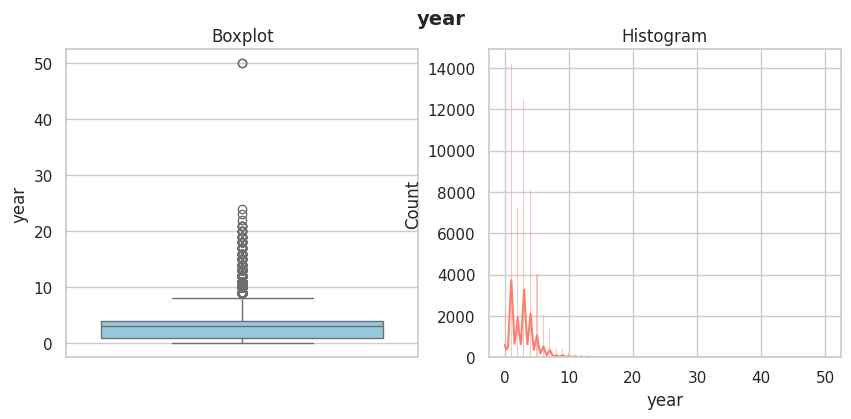

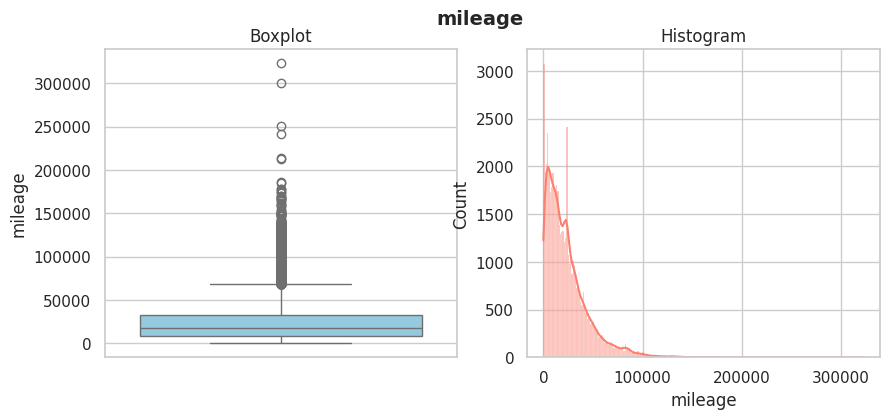

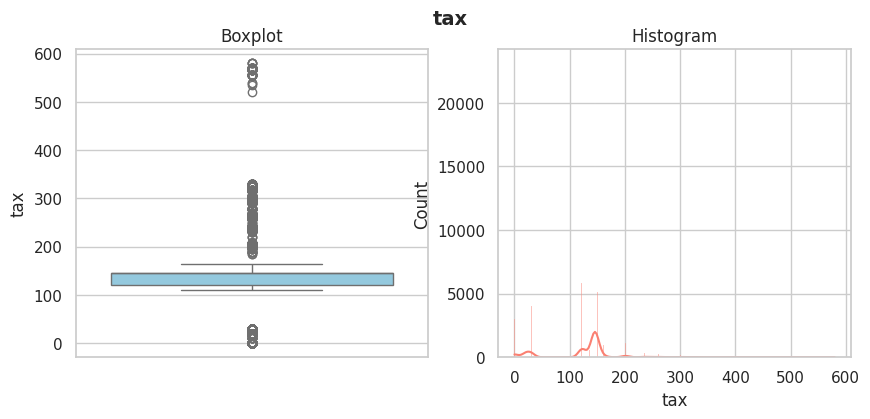

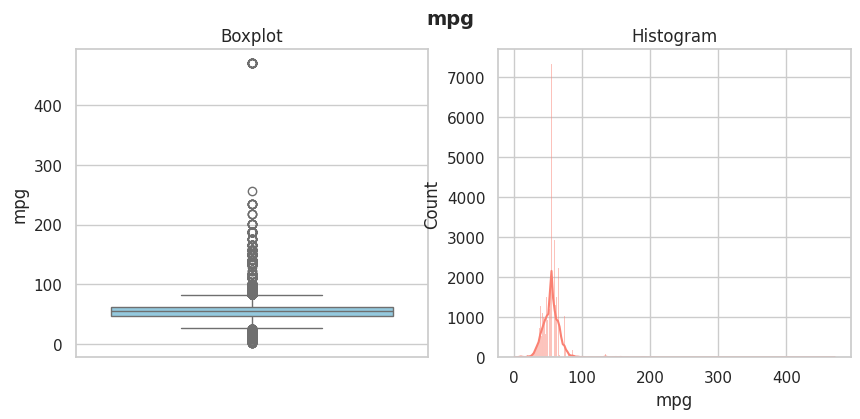

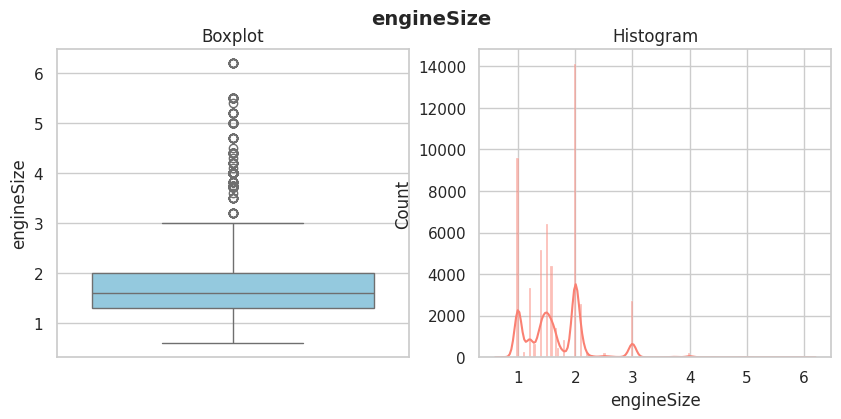

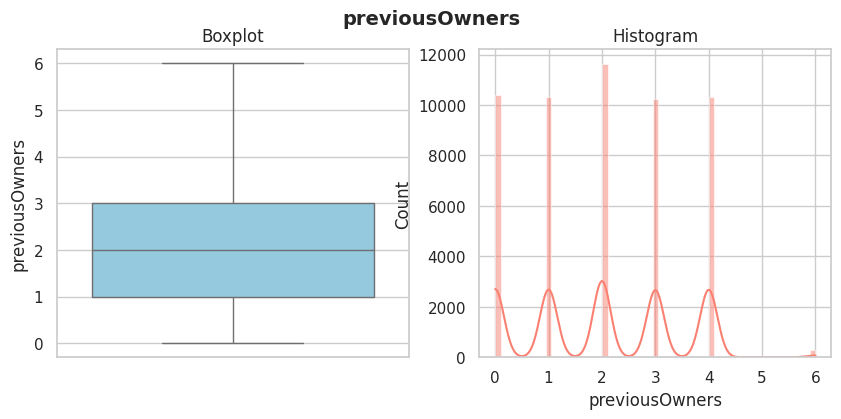

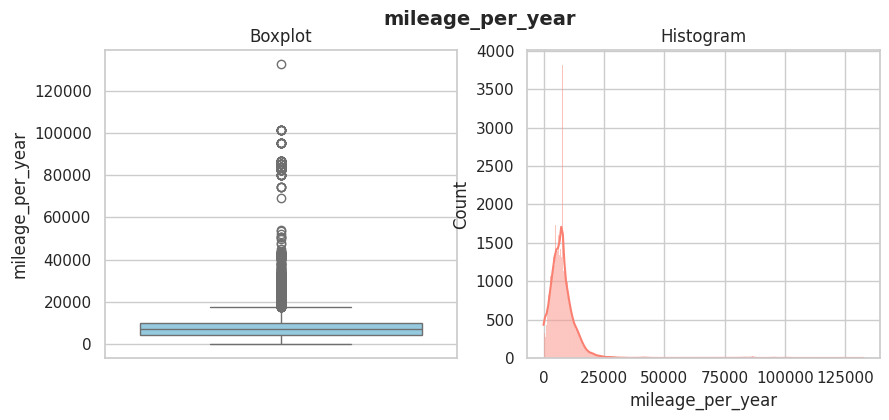

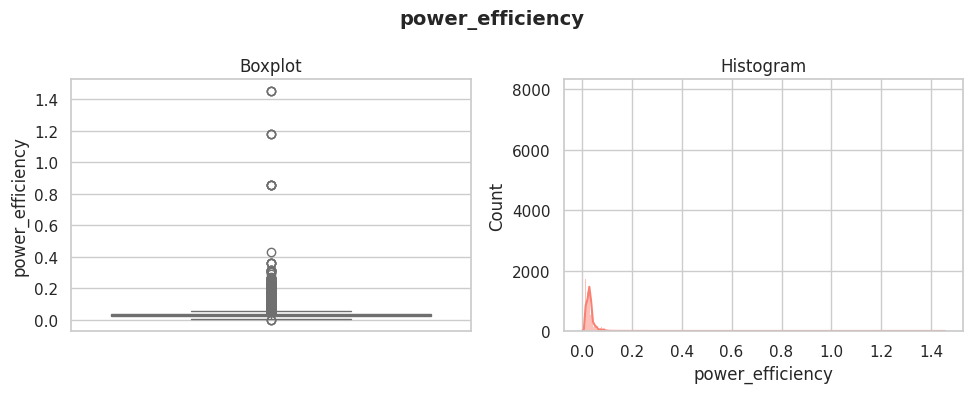

,year,mileage,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
count,53181.0,53181.000000,53181.000000,53181.000000,53181.000000,53181.0,53181.0,53181.000000
mean,2.925537,23322.431680,121.445982,55.181389,1.671665,2.015099,7657.920557,0.033790
std,2.132121,21290.673805,60.842636,15.286735,0.553473,1.423351,5772.678171,0.025188
min,0.0,1.000000,0.000000,1.100000,0.600000,0.0,0.052632,0.001274
25%,1.0,7845.000000,121.445982,47.100000,1.300000,1.0,4444.0,0.022414
50%,3.0,18033.000000,145.000000,55.181389,1.600000,2.0,7092.25,0.031847
75%,4.0,32025.000000,145.000000,61.400000,2.000000,3.0,9762.4,0.036101
max,50.0,323000.000000,580.000000,470.800000,6.200000,6.0,132644.0,1.454545


In [40]:
# =========================================
# Numerical features — Outlier & skew inspection
# =========================================

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Outlier and skew inspection — numerical features</b><br><br>
Numeric features are visually inspected using boxplots and histograms
to assess skewness, dispersion, and the presence of outliers.
</div>
"""))

def plot_nums(X, num_cols):
    outlier_counts = []

    for col in num_cols:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        fig.suptitle(col, fontsize=14, fontweight='bold')

        # Boxplot
        sns.boxplot(y=X[col], ax=axes[0], color='skyblue')
        axes[0].set_title("Boxplot")

        # Histogram
        sns.histplot(X[col], kde=True, ax=axes[1], color='salmon')
        axes[1].set_title("Histogram")

    plt.tight_layout()
    plt.show()

    for item in num_cols:
        #   find and count the outliers of metric features
        q1 = X[item].quantile(0.25)
        q3 = X[item].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        lower_outliers = (X[item] < lower).sum()
        upper_outliers = (X[item] > upper).sum()

        lower_pct = (lower_outliers / len(X)) * 100
        upper_pct = (upper_outliers / len(X)) * 100

        #create a dictionary with the feature,#outlier and percentage of outliers
        outlier_counts.append({
            "Feature": item,
            "Lower Outlier Count": lower_outliers,
            "Upper Outlier Count": upper_outliers,
            "Lower Outlier %": lower_pct,
            "Upper Outlier %": upper_pct
        })

    df_outlier = pd.DataFrame(outlier_counts)
    return df_outlier


# We plot numeric features for outlier/skew inspection.
plot_nums(X_train, num_cols)


# ---- Analysis
display(HTML("""
<div style="background-color:#f5faff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Analysis</b><br><br>
All of our features are heavy right skewed , expect previousOwners ,tax and engine size.<br>
We didn't transformarm previousOwners because the features is already well behabed(low skew and no outliers).<br>
Year wasn't transformed, due to the fact year is temporal feature , so transforming would decrease it's usefullness.<br>
Milleage and milleage_per_year were transformed by using log1p due to the fact that they both have long tails and milleage_per_year is ratio , so log1 is usefull to compress ratio.<br>
EngineSize was transformed only with clipping(upper and lower) , due to the fact that there's only mild skew and engineSize is mostly discret, so a log transformation would destroy this binning.<br>
Mpg has a prety symetric shape, but a heavy left tail , so the best solution is just to clip the right tail.<br>
Power_efficiency was transformed with clipping due to the fact, that a log transformation, would explode values into +infity this can be explained because power_efficiency is ration with alot of values around 0.<br>
Finally tax was transformed with power transformation to preserve the specific spikes at specific tax brackets.
</div>
"""))


# ---- Post-transformation summary
display(X_train.describe())


# ---- Analysis
display(HTML("""
<div style="background-color:#f5faff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Analysis</b><br><br>
For nan or, in this case, after pre-processing UNKNOWN car brands it's possible to infer them if the brand for the same record is correct.
The way we do this is by building a dictionary with the most common not UNKNOWN brand name for each model and then searching for missing brand names there.
This, unfortunately, is not a deterministic process and requires statistical information about the data so in order not to cause data leakage
we need to build the dictionary on training data and then apply it to the test/validation data.
</div>
"""))


In [41]:
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Brand inference for UNKNOWN values</b><br><br>
For <b>NaN</b> or, in this case, after pre-processing <b>UNKNOWN</b> car brands,
it is possible to infer them if the brand for the same record is correct.<br><br>

The approach consists of building a dictionary with the most common
<b>non-UNKNOWN</b> brand name for each model and then using this mapping to
replace missing brand values.<br><br>

This procedure is <b>not deterministic</b> and relies on statistical information
from the data. Therefore, to avoid <b>data leakage</b>, the dictionary is built
exclusively on the <b>training data</b> and subsequently applied to the
validation/test sets.
</div>
"""))


In [42]:
# =========================================
# Brand inference — Training-based correction
# =========================================

from IPython.display import display, HTML

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Inferring UNKNOWN brands using training data</b><br><br>
To further reduce missing categorical information, <b>UNKNOWN</b> brand values
are inferred using statistical patterns learned from the <b>training set</b>.<br><br>

For each car <b>model</b>, the most frequent non-UNKNOWN brand is identified and
used as a fallback value. This mapping is learned exclusively on training data
to prevent <b>data leakage</b>, and then applied consistently to validation data.
</div>
"""))


# ---- Build model → brand mapping from training data
def infer_brand_fit(df_train):
    model_to_brand = (
        df_train[df_train["Brand"] != "UNKNOWN"]
        .groupby("model")["Brand"]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "UNKNOWN")
        .to_dict()
    )
    return model_to_brand


# ---- Apply inferred brands
def infer_brand_apply(df, model_to_brand):
    df = df.copy()
    df["Brand"] = df.apply(
        lambda row: (
            row["Brand"]
            if row["Brand"] != "UNKNOWN"
            else model_to_brand.get(row["model"], "UNKNOWN")
        ),
        axis=1
    )
    return df


# ---- Inspect UNKNOWN brands before inference
X_train[X_train["Brand"] == "UNKNOWN"]


,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,
4297,UNKNOWN,A5,4,SEMI-AUTO,27385.0,PETROL,260.000000,35.800000,3.0,1,6846.25,0.083799
3538,UNKNOWN,Q5,3,MANUAL,55215.0,PETROL,235.000000,37.700000,2.0,4,7657.920557,0.053050
31896,UNKNOWN,SANTAFE,1,SEMI-AUTO,7119.0,DIESEL,145.000000,39.200000,2.2,0,7119.0,0.056122
35310,UNKNOWN,CCLASS,7,AUTOMATIC,68000.0,DIESEL,121.445982,55.181389,2.1,3,9714.285714,0.033790
40719,UNKNOWN,CCLASS,4,AUTOMATIC,30385.0,DIESEL,121.445982,55.181389,2.1,1,7596.25,0.033790
...,...,...,...,...,...,...,...,...,...,...,...,...
14626,UNKNOWN,1SERIES,7,AUTOMATIC,62000.0,DIESEL,30.000000,64.200000,2.0,3,8857.142857,0.031153
48145,UNKNOWN,KODIAQ,1,MANUAL,3053.0,DIESEL,145.000000,52.300000,2.0,0,3053.0,0.038241
37742,UNKNOWN,GLACLASS,6,SEMI-AUTO,52722.0,DIESEL,145.000000,55.400000,2.1,1,8787.0,0.037906


In [43]:
# =========================================
# Brand inference — Apply to train & validation sets
# =========================================

from IPython.display import display, HTML

# ---- Section introduction
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Applying inferred brand mapping</b><br><br>
The model-to-brand mapping learned from the training data is now applied to both
the <b>training</b> and <b>validation</b> sets.<br><br>

This ensures that remaining <b>UNKNOWN</b> brand values are resolved consistently
across datasets, while preserving a strict separation between training and
validation data to avoid leakage.
</div>
"""))


# ---- Learn mapping on training data
model_to_brand = infer_brand_fit(X_train)

# ---- Apply mapping to train and validation sets
X_train = infer_brand_apply(X_train, model_to_brand)
X_val   = infer_brand_apply(X_val, model_to_brand)

# ---- Check remaining UNKNOWN brands
X_train[X_train["Brand"] == "UNKNOWN"]


,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,
69305,UNKNOWN,TIGUA,4,SEMI-AUTO,23322.431680,DIESEL,160.000000,49.6,2.000000,3,7657.920557,0.040323
35445,UNKNOWN,CCLAS,7,AUTOMATIC,68000.000000,DIESEL,145.000000,53.3,2.100000,1,9714.285714,0.039400
38260,UNKNOWN,CLCLASS,3,SEMI-AUTO,23592.000000,DIESEL,20.000000,67.3,2.100000,0,7864.0,0.031204
36973,UNKNOWN,GLACLASS,1,SEMI-AUTO,17471.000000,DIESEL,145.000000,67.3,2.100000,2,17471.0,0.031204
5908,UNKNOWN,A,5,SEMI-AUTO,56875.000000,DIESEL,150.000000,53.3,2.000000,0,11375.0,0.037523
39351,UNKNOWN,GLECLASS,5,AUTOMATIC,13212.000000,PETROL,570.000000,23.7,1.671665,2,2642.4,0.033790
62403,UNKNOWN,ASTR,4,MANUAL,32891.000000,DIESEL,20.000000,72.4,1.600000,3,8222.75,0.022099
37971,UNKNOWN,CLSCLASS,1,AUTOMATIC,30000.000000,DIESEL,150.000000,47.9,2.900000,1,30000.0,0.060543
14098,UNKNOWN,X,6,AUTOMATIC,37905.000000,DIESEL,165.000000,52.3,2.000000,0,6317.5,0.038241


In [45]:


display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Outlier handling & skew correction — methodology</b><br><br>
To handle outliers a way had to be found in order to 1) detect skewed distributions automatically in order to log transform them, 2) to automatically define the winsorization quartiles to clip outliers. All this would have to be estabilished in the training folds and then passed on to the test folds to ensure no leakage. In order to decide if a log transform should happen or not to a feature we simply apply the skew() function and if it's absolute value is greater than one. To define winsorization quartiles we use the MAD method: we take the median, calculate all deviations from it and do the median of that (=MAD), we then use robust z scores: z = (Xi - median(X))/(1.4826*MAD) (1.4826 assuming our distributions resemble a normal distribution now), if abs(z) > 3.5 it is an outlier, we choose clipping bounds based on inliers and clip according to quartiles we want, the default is 0.001 and 0.999.
</div>
"""))


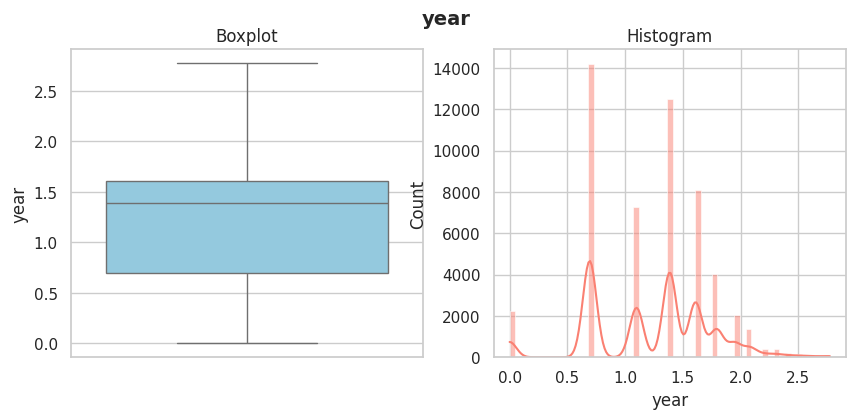

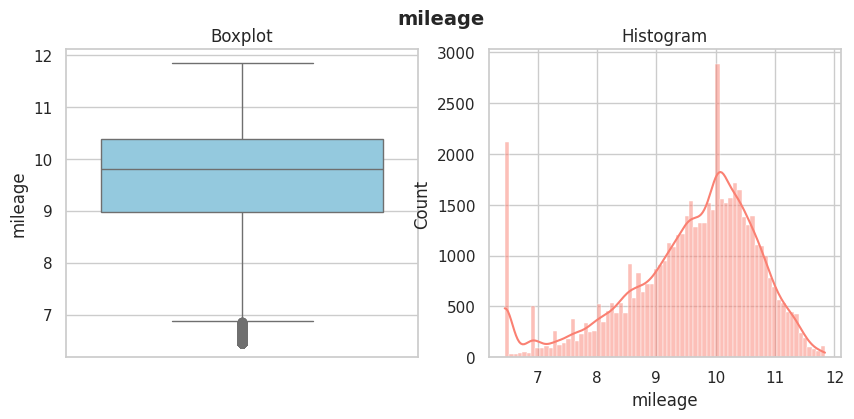

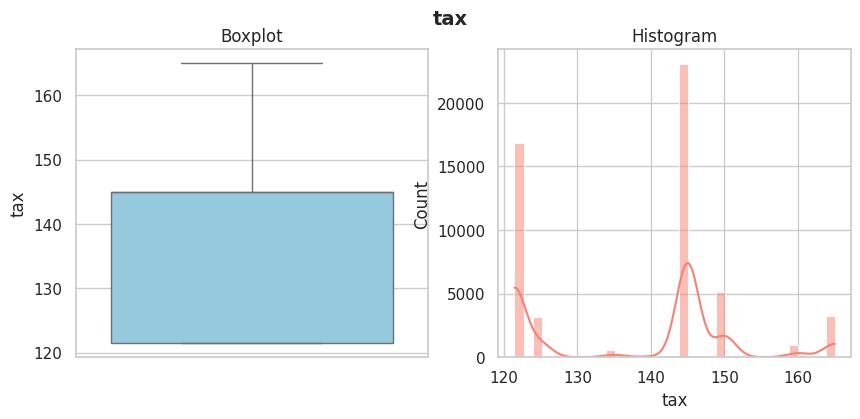

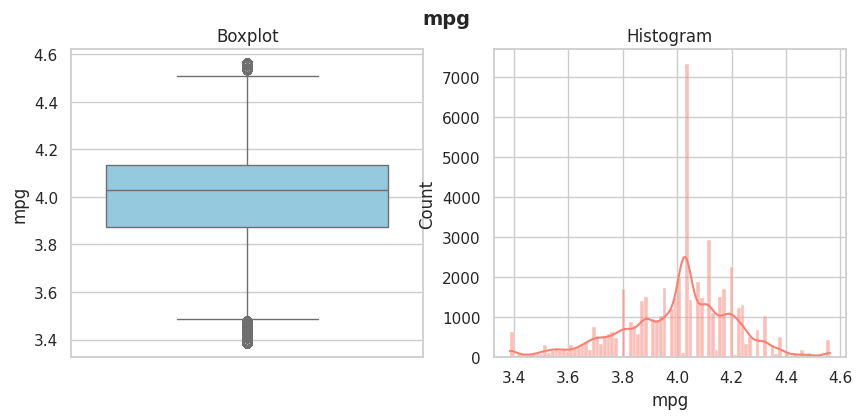

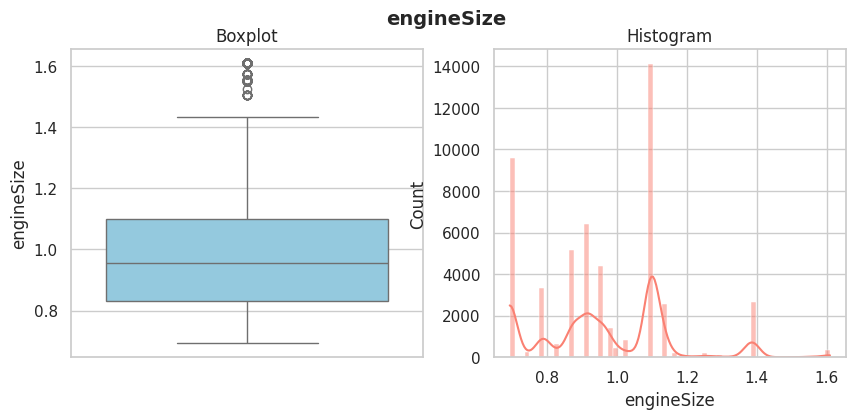

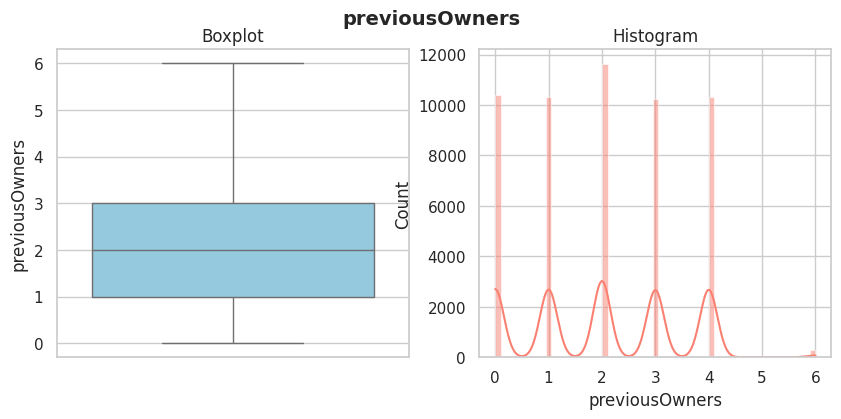

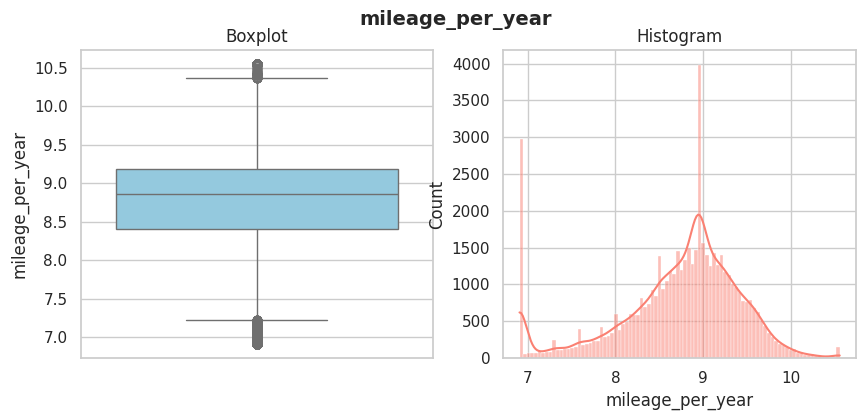

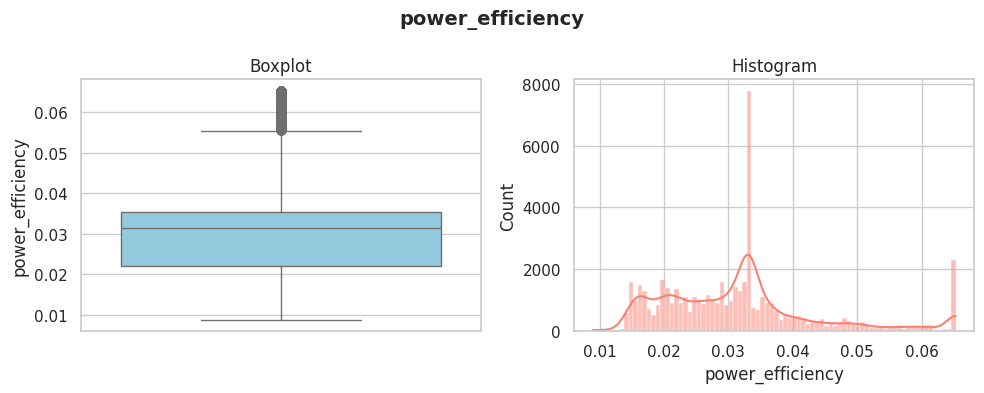

,Feature,Lower Outlier Count,Upper Outlier Count,Lower Outlier %,Upper Outlier %
0,year,0,0,0.000000,0.000000
1,mileage,2299,0,4.322972,0.000000
2,tax,0,0,0.000000,0.000000
3,mpg,964,457,1.812677,0.859329
4,engineSize,0,446,0.000000,0.838645
5,previousOwners,0,0,0.000000,0.000000
6,mileage_per_year,3440,192,6.468476,0.361031
7,power_efficiency,0,3800,0.000000,7.145409


In [47]:
from scipy.stats import skew

def outliers_skews_train(
    X,
    num_cols,
    *,
    q_low=0.001,
    q_high=0.999,
    upper_only_after_log=False,
):
    """
    1) For each numeric column:
    compute skewness on raw values → decide log

    2) log-transform first (if decided)

    3) compute MAD robust z-scores on working scale

    4) define clipping bounds using quantiles of the inliers

    5) apply transforms

    6) return transformed data + metadata to replay on test
    """
    X = X.copy()
    info = {}

    for col in num_cols:
        x_raw = X[col].to_numpy()

        col_info = {
            "log": False,
            "clip": False,
            "lower": None,
            "upper": None,
            "q_low": float(q_low),
            "q_high": float(q_high),
            "mad_z": float(3.5),
            "skew_raw": None,
            "upper_only": False,
        }

        #not enough data
        if len(x_raw) < 20:
            info[col] = col_info
            continue

        #log transform if skewness > 1 and non negative values
        s = float(skew(x_raw))
        col_info["skew_raw"] = s
        do_log = (s > 1) and np.all(x_raw >= 0)
        col_info["log"] = bool(do_log)
        col_info["upper_only"] = bool(do_log and upper_only_after_log)

        # scale
        x_work = np.log1p(x_raw) if do_log else x_raw

        # (3) MAD robust z-scores on working scale
        med = np.median(x_work)
        mad = np.median(np.abs(x_work - med))
        #if mad~0 the columns is mostly constant
        if mad < 1e-12:
            info[col] = col_info
            # still apply log if chosen (even if clipping is skipped)
            if do_log:
                X[col] = np.log1p(X[col])
            continue

        scale = 1.4826 * mad
        rz = (x_work - med) / scale
        inliers = np.abs(rz) <= 3.5

        # If nothing to clip, still apply log if needed and move on
        if inliers.all():
            info[col] = col_info
            if do_log:
                X[col] = np.log1p(X[col])
            continue

        # (4) Quantile bounds computed on INLIERS (still on working scale)
        x_in = x_work[inliers]
        upper = float(np.quantile(x_in, q_high))
        lower = float(np.quantile(x_in, q_low))

        col_info["clip"] = True
        col_info["upper"] = upper
        col_info["lower"] = None if col_info["upper_only"] else lower

        # (5) Apply to training data: log -> clip (bounds are on working scale)
        if do_log:
            X[col] = np.log1p(X[col])

        if col_info["upper_only"]:
            X[col] = X[col].clip(upper=upper)
        else:
            X[col] = X[col].clip(lower=lower, upper=upper)

        info[col] = col_info

    return X, info

def outliers_skews_test(X, info):
    """
    Apply the transformations learned in outliers_skews_train to test/val data.

    For each column:
      1) Apply log1p if info[col]["log"] is True
      2) Apply clipping using stored bounds (on the same scale)
    """
    X = X.copy()

    for col, col_info in info.items():
        if col not in X.columns:
            continue

        x = X[col].to_numpy()
        if np.isnan(x).any():
            raise ValueError(f"NaNs found in '{col}' before log/MAD clipping (test/val).")

        # 1) Apply log transform if training decided so
        if col_info.get("log", False):
            X[col] = np.log1p(X[col])

        # 2) Apply clipping if training decided so
        if col_info.get("clip", False):
            lower = col_info.get("lower", None)
            upper = col_info.get("upper", None)

            if lower is None and upper is not None:
                X[col] = X[col].clip(upper=upper)
            elif lower is not None and upper is not None:
                X[col] = X[col].clip(lower=lower, upper=upper)
            elif lower is not None:
                X[col] = X[col].clip(lower=lower)

    return X
X_train, outlier_info = outliers_skews_train(X_train, num_cols)
X_val = outliers_skews_test(X_val, outlier_info)
plot_nums(X_train, num_cols)

In [48]:
outlier_info

{'year': {'log': True,
  'clip': True,
  'lower': 0.0,
  'upper': 2.772588722239781,
  'q_low': 0.001,
  'q_high': 0.999,
  'mad_z': 3.5,
  'skew_raw': 2.1603409554368422,
  'upper_only': False},
 'mileage': {'log': True,
  'clip': True,
  'lower': 6.447544975813665,
  'upper': 11.840240221136671,
  'q_low': 0.001,
  'q_high': 0.999,
  'mad_z': 3.5,
  'skew_raw': 1.8400480947880173,
  'upper_only': False},
 'tax': {'log': False,
  'clip': True,
  'lower': 121.44598164628282,
  'upper': 165.0,
  'q_low': 0.001,
  'q_high': 0.999,
  'mad_z': 3.5,
  'skew_raw': 0.14032141026321895,
  'upper_only': False},
 'mpg': {'log': True,
  'clip': True,
  'lower': 3.3843902633457743,
  'upper': 4.562120508014837,
  'q_low': 0.001,
  'q_high': 0.999,
  'mad_z': 3.5,
  'skew_raw': 7.6965957001706675,
  'upper_only': False},
 'engineSize': {'log': True,
  'clip': True,
  'lower': 0.6931471805599453,
  'upper': 1.6094379124341003,
  'q_low': 0.001,
  'q_high': 0.999,
  'mad_z': 3.5,
  'skew_raw': 1.4368

In [49]:
X_train_num = X_train[num_cols].copy()
X_train_cat = X_train[cat_cols].copy()

X_val_num = X_val[num_cols].copy()
X_val_cat = X_val[cat_cols].copy()
scaler = MinMaxScaler()
scaler.fit(X_train_num)
X_train_num_scaled = scaler.transform(X_train_num)
X_train_num_scaled

array([[0.25      , 0.33847287, 0.54080012, ..., 0.33333333, 0.37430552,
        0.31716213],
       [0.25      , 0.40769391, 0.31120018, ..., 0.5       , 0.47673693,
        0.06705062],
       [0.        , 0.        , 0.54080012, ..., 0.        , 0.        ,
        0.15350494],
       ...,
       [0.64624063, 0.80485352, 0.        , ..., 0.16666667, 0.62283069,
        0.12255596],
       [0.5       , 0.75595345, 0.08160024, ..., 0.66666667, 0.69063397,
        0.3188441 ],
       [0.64624063, 0.78657515, 0.08160024, ..., 0.        , 0.5957852 ,
        0.451278  ]])

In [50]:
X_train_num_scaled = pd.DataFrame(X_train_num_scaled, columns = X_train_num.columns).set_index(X_train.index)
X_train_num_scaled

,year,mileage,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,
39423,0.250000,0.338473,0.5408,0.429120,0.152530,0.333333,0.374306,0.317162
9016,0.250000,0.407694,0.3112,1.000000,0.442507,0.500000,0.476737,0.067051
24121,0.000000,0.000000,0.5408,0.566679,0.000000,0.000000,0.000000,0.153505
57460,0.396241,0.655136,0.5408,0.262774,0.198978,0.000000,0.652706,0.464503
1936,0.000000,0.289124,0.5408,0.017096,0.728840,0.166667,0.301280,1.000000
...,...,...,...,...,...,...,...,...
33819,0.500000,0.634902,0.0000,0.487817,0.198978,0.666667,0.511519,0.318844
46982,0.250000,0.000000,0.5408,0.335598,0.442507,0.333333,0.000000,0.651997
71103,0.646241,0.804854,0.0000,0.654957,0.000000,0.166667,0.622831,0.122556


In [51]:
X_val_num_scaled = scaler.transform(X_val_num)
X_val_num_scaled = pd.DataFrame(X_val_num_scaled, columns = X_val_num.columns).set_index(X_val.index)
X_val_num_scaled

,year,mileage,tax,mpg,engineSize,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,
7082,0.250000,0.395465,0.5408,0.196920,0.442507,0.166667,0.458641,0.795671
40497,0.580482,0.690971,0.0000,0.546980,0.478292,0.500000,0.515551,0.431539
46065,0.646241,0.780296,1.0000,0.008591,1.000000,0.500000,0.586495,1.000000
17155,0.396241,0.633537,0.5408,0.533554,0.000000,0.666667,0.620746,0.165989
34462,0.396241,0.733707,0.5408,0.230485,0.610740,0.166667,0.768968,0.980538
...,...,...,...,...,...,...,...,...
50530,0.500000,0.636703,0.5408,0.636118,0.000000,0.333333,0.514183,0.128889
41012,0.250000,0.269867,0.5408,0.546980,0.442507,0.333333,0.272785,0.431539
68389,0.500000,0.735229,0.0000,0.673388,0.000000,0.333333,0.659968,0.116497


In [52]:
X_train_num_scaled.var()

,0
year,0.035275
mileage,0.046837
tax,0.097840
mpg,0.031730
engineSize,0.043586
previousOwners,0.056276
mileage_per_year,0.038948
power_efficiency,0.048082


# **8. Correlation tests**

In [53]:
def gap_threshold(values, min_features=2):
    """
    Compute a gap-based threshold on a 1D array of importance values.
    """
    values = np.asarray(values)
    values = np.maximum(values, 0)  # clip negatives
    values = np.sort(values)[::-1]

    if len(values) <= min_features:
        return values[-1]

    gaps = values[:-1] - values[1:]
    idx = np.argmax(gaps)

    return values[idx + 1]

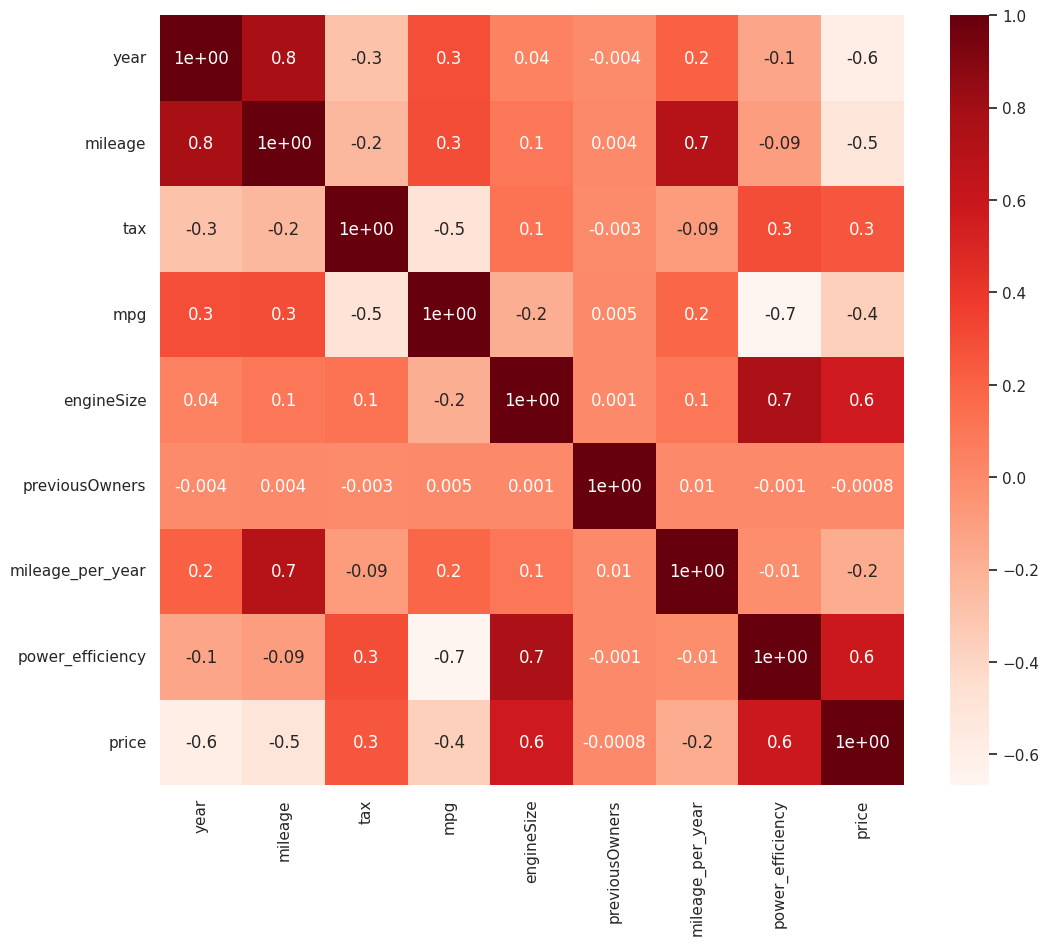

In [54]:
corr = X_train_num_scaled.assign(price=y_train).corr(method="spearman")
def cor_heatmap(cor):
    plt.figure(figsize=(12,10))
    sns.heatmap(data = cor, annot = True, cmap = plt.cm.Reds, fmt='.1')
    plt.show()
cor_heatmap(corr)

In [55]:
def spearman_decision(X_train_num_scaled,y_train):
    corr = X_train_num_scaled.assign(price=y_train).corr(method="spearman")["price"]
    corr = corr.drop("price")
    threshold = np.percentile(corr, 60)
    return pd.DataFrame({
        "value": corr,
        "decision": corr.abs() >= threshold
    })

In [56]:
spearman = spearman_decision(X_train_num_scaled, y_train)
print(spearman)

                     value  decision
year             -0.590326      True
mileage          -0.508229      True
tax               0.255551      True
mpg              -0.365796      True
engineSize        0.567402      True
previousOwners   -0.000763     False
mileage_per_year -0.176689      True
power_efficiency  0.579544      True


In [57]:
def mi_scores_decision(X_train_num_scaled, y_train,pct=50):

    mi_scores = mutual_info_regression(
        X_train_num_scaled,
        y_train,
        random_state=0
    )
    gap_t = gap_threshold(mi_scores)
    pct_t = np.percentile(mi_scores, pct)
    threshold = max(gap_t, pct_t)




    return pd.DataFrame({
        "value": mi_scores,
        "decision": mi_scores >= threshold
    }, index=X_train_num_scaled.columns)

In [58]:
mi = mi_scores_decision(X_train_num_scaled, y_train)
print(mi)

                     value  decision
year              0.327493     False
mileage           0.294037     False
tax               0.129985     False
mpg               0.366423     False
engineSize        0.385101      True
previousOwners    0.000000     False
mileage_per_year  0.134726     False
power_efficiency  0.651121      True


In [59]:
from IPython.display import display, HTML

display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
Mi scores assigns high correlation(in relationship to the target) , to all features exept tax,milleages_per_year and previousOwners. It's worth noting that mi scores assigns an higher correlation to power_efficiency than to engineSize and year which is departure from the spearman method.<br>
Power efficiency is the main driver of mi scores, by a large distance.<br><br>
ANOVA correlation
</div>
"""))


In [60]:
def anova_eta_squared_decision(X ,y,pct=50):
    eta_values = {}

    for col in X_train_cat.columns:
        df = pd.DataFrame({"X": X[col], "y": y}).dropna()

        groups = [
            df[df["X"] == level]["y"].values
            for level in df["X"].unique()
            if len(df[df["X"] == level]) > 1
        ]

        if len(groups) < 2:
            eta_values[col] = 0.0
            continue

        f_stat, _ = f_oneway(*groups)
        k = len(groups)
        n = len(df)

        eta_sq = (f_stat * (k - 1)) / (f_stat * (k - 1) + (n - k))
        eta_values[col] = eta_sq

    eta = pd.Series(eta_values)
    gap_t = gap_threshold(eta)
    pct_t = np.percentile(eta, pct)
    threshold = max(gap_t, pct_t)

    return pd.DataFrame({
        "value": eta,
        "decision": eta >= threshold
    })

In [61]:
anova_cat = anova_eta_squared_decision(X_train_cat,y_train)
print(anova_cat)

                 value  decision
Brand         0.287023     False
model         0.571844      True
transmission  0.299793      True
fuelType      0.046355     False


In [67]:
from scipy.stats import kruskal

def kruskal_eta_squared_decision(X_cat, y,pct=50):
    eta_vals = {}

    for col in X_cat.columns:
        df = pd.DataFrame({"X": X_cat[col], "y": y}).dropna()
        groups = [
            df[df["X"] == level]["y"].values
            for level in df["X"].unique()
            if len(df[df["X"] == level]) > 1
        ]

        if len(groups) < 2:
            eta_vals[col] = 0.0
            continue

        h_stat, _ = kruskal(*groups)
        n = len(df)
        k = len(groups)

        eta_sq = max(0, (h_stat - k + 1) / (n - k))
        eta_vals[col] = eta_sq

    eta = pd.Series(eta_vals)
    gap_t = gap_threshold(eta)
    pct_t = np.percentile(eta, pct)
    threshold = max(gap_t, pct_t)
    return pd.DataFrame({
        "value": eta,
        "decision": eta >= threshold
    })

In [68]:
kruskal_cat = kruskal_eta_squared_decision(X_train_cat,y_train)
print(kruskal_cat)

                 value  decision
Brand         0.349271     False
model         0.605347      True
transmission  0.358798      True
fuelType      0.077060     False


In [69]:
def mi_categorical_decision(X_cat, y,pct=50):
    mi_vals = {}

    for col in X_cat.columns:
        x = X_cat[col].astype("category").cat.codes.values.reshape(-1, 1)
        mi_vals[col] = mutual_info_regression(
            x, y, discrete_features=True, random_state=RANDOM_SEED
        )[0]

    mi = pd.Series(mi_vals)
    gap_t = gap_threshold(mi)
    pct_t = np.percentile(mi, pct)
    threshold = max(gap_t, pct_t)

    return pd.DataFrame({
        "value": mi,
        "decision": mi >= threshold
    })

In [70]:
mi_cat = mi_categorical_decision(X_train_cat,y_train)
print(mi_cat)

                 value  decision
Brand         0.330208      True
model         0.726926      True
transmission  0.247277     False
fuelType      0.070624     False


In [79]:
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance


def permutation_decision(X_train, y_train, X_val, y_val,pct=50):
    model = Ridge(alpha=1.0, random_state=RANDOM_SEED)
    model.fit(X_train, y_train)

    perm = permutation_importance(
        model,
        X_val,
        y_val,
        n_repeats=10,
        random_state=RANDOM_SEED
    )
    values = perm.importances_mean
    gap_t = gap_threshold(values)
    pct_t = np.percentile(values, pct)
    threshold = max(gap_t, pct_t)
    return pd.DataFrame({
        "value": perm.importances_mean,
        "decision": perm.importances_mean > threshold
    }, index=X_train.columns)

In [80]:
perm=permutation_decision(X_train_num_scaled, y_train, X_val_num_scaled, y_val)
print(perm)

                     value  decision
year              0.205229     False
mileage           0.209536     False
tax               0.012152     False
mpg               0.033448     False
engineSize        0.636350      True
previousOwners   -0.000001     False
mileage_per_year  0.017802     False
power_efficiency  0.002301     False


## **8.1 LASSO**

In [81]:
def lasso_decision(X_train_num_scaled,y_train):
    reg = LassoCV(cv=10, random_state=RANDOM_SEED)
    reg.fit(X_train_num_scaled, y_train)
    coef = pd.Series(reg.coef_, index = X_train_num_scaled.columns)

    return (coef.abs() > 1e-6)

In [82]:
lasso_keep = lasso_decision(X_train_num_scaled, y_train)
print(lasso_keep)

year                True
mileage             True
tax                 True
mpg                 True
engineSize          True
previousOwners      True
mileage_per_year    True
power_efficiency    True
dtype: bool


## **8.2 Voting Table**

In [84]:
display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Feature selection — voting criteria</b><br><br>

In our voting table we will use spearman, mi and rfe has the 3 major deciders and Lasso will be the the final decider(has lasso can handly multicollinearity and pick the "strongest one") Here's our decision criteria for numerical features :<br><br>

If a feature doesn't have a single passing test , then we will treat this feature has pure noise by not include the feature in any of our model(NOISE)<br><br>

If a feature passes all 3 major deciders we will assume it's major driver of price prediction(MAJOR)<br><br>

If a features passes 2 out of three major decider we will let Lasso decide if we keep a lesser signal(KEEP) or we let feature be tossed(TOSS) , this features might be included in tree models due to the fact that tree dynamicaly weight features and they might be relevant if they have some predictive power even if some noise is present.<br><br>

If a feature only passes 1 test out of three we will confidently toss(HARD TOSS).<br><br>

For categorical features ,we will rank features in the following way:<br><br>

If a feature doesn't have a single passing test , then we will treat this feature has pure noise by not include the feature in any of our model(NOISE).<br><br>

If a feature passes all 3 major deciders we will assume it's major driver of price prediction(MAJOR).<br><br>

If a feature only passes 1 test out of three we will confidently toss(HARD TOSS).
</div>
"""))


## 📊 Feature Selection — Decision Summary Table

### 🔢 Numerical Features

| Passing Tests (Spearman / MI / RFE) | Lasso Decision | Final Label | Meaning |
|-----------------------------------|---------------|-------------|---------|
| 0 / 3 | — | **NOISE** | Pure noise, excluded from all models |
| 1 / 3 | — | **HARD TOSS** | Weak signal, confidently discarded |
| 2 / 3 | ❌ | **TOSS** | Partial signal rejected by Lasso |
| 2 / 3 | ✅ | **KEEP** | Secondary signal, kept (especially useful for tree models) |
| 3 / 3 | — | **MAJOR** | Strong driver of price prediction |


### 🏷️ Categorical Features

| Passing Tests (Kruskal / MI / RFE) | Final Label | Meaning |
|----------------------------------|-------------|---------|
| 0 / 3 | **NOISE** | Pure noise, excluded from all models |
| 1 / 3 | **HARD TOSS** | Weak signal, confidently discarded |
| 2 / 3 | **KEEP** | Moderate signal, retained for modeling |
| 3 / 3 | **MAJOR** | Strong driver of price prediction |


In [85]:
def decide_numerical(
    spearman_decision: bool,
    mi_decision: bool,
    permutation_decision: bool,
    lasso_decision: bool
):
    votes = sum([spearman_decision, mi_decision, permutation_decision])

    if votes == 0:
        final = "NOISE"
    elif votes == 3:
        final = "MAJOR"
    elif votes == 2:
        final = "KEEP" if lasso_decision else "TOSS"
    else:
        final = "HARD TOSS"

    return {
        "spearman": spearman_decision,
        "mi": mi_decision,
        "permutation": permutation_decision,
        "lasso": lasso_decision,
        "votes": votes,
        "final_decision": final
    }

In [86]:
numerical_decisions = {}

for col in X_train_num_scaled.columns:
    numerical_decisions[col] = decide_numerical(
        spearman_decision=spearman.loc[col, "decision"],
        mi_decision=mi.loc[col, "decision"],
        permutation_decision=perm.loc[col, "decision"],
        lasso_decision=lasso_keep[col]
    )

numerical_results = pd.DataFrame(numerical_decisions).T
print(numerical_results)

                 spearman     mi permutation lasso votes final_decision
year                 True  False       False  True     1      HARD TOSS
mileage              True  False       False  True     1      HARD TOSS
tax                  True  False       False  True     1      HARD TOSS
mpg                  True  False       False  True     1      HARD TOSS
engineSize           True   True        True  True     3          MAJOR
previousOwners      False  False       False  True     0          NOISE
mileage_per_year     True  False       False  True     1      HARD TOSS
power_efficiency     True   True       False  True     2           KEEP


In [87]:
def decide_categorical(
    anova_decision: bool,
    kruskal_decision: bool,
    mi_decision: bool
):
    votes=sum([anova_decision, kruskal_decision, mi_decision])
    if votes == 3:
        return "MAJOR"

    if votes == 2:
        return "KEEP"

    if votes == 1:
        return "TOSS"

    return "NOISE"

In [88]:
categorical_results = pd.DataFrame(index=X_train_cat.columns)

categorical_results["anova"] = anova_cat["decision"]
categorical_results["kruskal"] = kruskal_cat["decision"]
categorical_results["mi"] = mi_cat["decision"]

categorical_results["final_decision"] = categorical_results.apply(
    lambda row: decide_categorical(
        row["anova"],
        row["kruskal"],
        row["mi"]
    ),
    axis=1
)

print(categorical_results)

              anova  kruskal     mi final_decision
Brand         False    False   True           TOSS
model          True     True   True          MAJOR
transmission   True     True  False           KEEP
fuelType      False    False  False          NOISE


In [89]:
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, ExtraTreesRegressor
from utils import *
from valid_models import valid_models

In [90]:
RANDOM_SEED = 1907
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# **9. Model Selection**

In [91]:
from IPython.display import display, HTML

display(HTML("""
<div style="background-color:#e8f1ff; padding:12px; border-radius:8px; border-left:6px solid #1f77ff;">
<b>Model selection — overview and conclusions</b><br><br>

In the <b>Model Selection</b> section of this project we trained <b>5 different models</b> and
measured their performance according to their <b>R²</b> and <b>MAE</b> scores, since this was the
chosen metric on the project Kaggle competition.<br><br>

The workflow is relatively simple. First, we filter our training data's domain by applying
the <b>clean_df</b> function we defined earlier. It is correct to apply it before any
training–validation split is done because it filters the dataset deterministically and
doesn't involve calculating the statistics of the data. This means: the dataset simply
should not have negative mileages or non-integer years. Pre-processing that involves actual
statistics like nan-imputting and outlier clipping, is done later on in the pipeline with
actual train and validation splits.<br><br>

Secondly, we define the features we want to use in our models and the ones that we want to
drop.<br><br>

The encoding of categorical variables was always done with <b>OneHotEncoding</b>, although we
experimented with frequency encoding and the conclusion was that it just wasn't as
performant. Scaling was either done with <b>StandardScaler</b> or <b>MinMaxScaler</b>, one of the
conclusions was that there wasn't a performance difference between both.<br><br>

All the Cross Validation and hyperparameter tuning was done with the functions coded below to
ensure no data leakage.<br><br>

What we concluded was that <b>tree based models</b> were the ones most fit for this problem.
The five we experimented the most with were:
<ul>
  <li>Linear Regression</li>
  <li>Random Forests</li>
  <li>Histogram-based Gradient Boosting</li>
  <li>Extra-Trees</li>
  <li>Multi-Layer Perceptron</li>
</ul>

As said before the tree based models like <b>Random Forests</b>, <b>Extra-Trees</b> and
<b>HGB</b> outperformed the other 2, with the most successfull one being the
<b>Extra-Trees</b> model with a mean KFold CV score of <b>0.9435</b> and mean <b>MAE of 1299.7174</b>
on the validation splits.<br><br>

We suspect the tree-based models outperformed the Linear Regression and the
Multi-Layer Perceptron because:
<ol>
  <li>The specific nature of the data — it simply happened that the data was more suited for
      tree based-models.</li>
  <li>Pre-processing wasn't perfect: there were brands and models that could never be
      identified and attributed to their real class.</li>
</ol>

Linear models or the weight calculations of the MLP were affected by the fact that the OHE
Encoder transformed a not insiginificant amount of brands and models into zeros because
their true class could not be identified reliably and consistently between training and
test sets. Decision-trees don't tend to collapse as hard with data unseen in training.
Additionally, the Feature Selection stage of the project wasn't the strongest and tree based
models bypass this by independently splitting the data according to its most important
features.
</div>
"""))


In [92]:
"""Frequency encoding logic"""
def frequency_encode_train(df, cat_cols):
    df_encoded = df.copy()

    freq_values = {}
    for col in cat_cols:
        freq_map = df[col].value_counts(normalize=True)

        #this needed in order to not have data leakage when applying to test data, there will be classes that are not in the training dataset
        #due to the fact that the strings were corrupted and pre processing isnt perfect of course
        mean_freq = freq_map.mean()
        df_encoded[col] = df[col].map(freq_map).fillna(mean_freq)
        freq_values[col] = {
            "map": freq_map,
            "mean": mean_freq
        }

    return df_encoded, freq_values

In [93]:
def frequency_encode_test(df, cat_cols, freq_values):
    df_encoded = df.copy()

    for col in cat_cols:
        freq_map = freq_values[col]["map"]
        mean_freq = freq_values[col]["mean"]
        df_encoded[col] = df[col].map(freq_map).fillna(mean_freq)
    return df_encoded

The function run_model() simply trains a model.

First it finds the most frequent brand associated with the model and creates a dictionary model → most common brand (from training data only) and then fills the UNKNOWN brands
it fills missing values with the data's mean and
applies the previous it defined outlier_skews_train() function to winsorize the numerical features, the means and outlier quartiles are stored for application on the testing split.
Categorical features are encoded with either OHE or frequency encoding, the encoding object in the case of OHE is fitted on the data and stored to transform the validation data later on as well as the frequency encoding map and means.
The scaler for numerical features and is fit onto the data as well and stored for future use (with frequency encoding the categorical features are also scaled).
For stateful models like HGB and the MLPRegressor that build on previous iterations of itself, it is necessary to make the model a copy of itself before fitting on to the processed data because of the logistics and inner workings of the .fit() function that would lead to the model not being completely new.
The function returns the trained model, the scaler fitted to the training data, the fitted encoder, the values for nan-imputting, the exact list of columns the model was trained on and the outlier quartiles.

In [94]:
def run_model(X, y, int_cols, float_cols, model_class, model_params=None,
              scaler=None, encoder=None, cat_cols=None, encoding_type="ohe"):
    """
    Parameters
    ----------
    X : pandas.DataFrame
        Training feature matrix.
    y : pandas.Series or array-like
        Target variable corresponding to X.
    int_cols : list
        List of integer-valued feature column names.
    float_cols : list
        List of float-valued feature column names.
    model_class : sklearn estimator class
        Model class to be instantiated and trained.
    model_params : dict, optional
        Hyperparameters to initialize the model.
    scaler : sklearn scaler, optional
        Scaler Object used to normalize numeric features.
    encoder : sklearn encoder, optional
        Encoder Object used for categorical features (e.g. OneHotEncoder), =None for frequency encoding (no encoding Object).
    cat_cols : list, optional
        List of categorical feature column names.
    encoding_type : str, default="ohe"
        Encoding strategy for categorical features ("ohe" or "freq").

    Returns
    -------
    model : sklearn estimator
        Trained model fitted on the processed training data.
    scaler : sklearn scaler
        Scaler fitted on the training data.
    encoder : sklearn encoder
        Encoder Object fitted on the training categorical features.
    fill_values : dict
        Mean and median values used for NaN imputation.
    train_feature_cols : list
        Exact list and order of feature columns used during training.
    freq_values : dict or None
        Frequency encoding mappings and fallback values (if used).
    outlier_info : dict
        Statistics required to apply the same outlier handling to validation/test data.
    brand_to_model : dict
        Statistics to infer brand from model.
    """
    X_processed = X.copy()

    if model_params is None:
        model_params = {}

    model_to_brand = infer_brand_fit(X_processed)
    X_processed = infer_brand_apply(X_processed, model_to_brand)

    X_processed, fill_values = fill_nans(X_processed, int_cols, float_cols)
    X_processed, outlier_info = outliers_skews_train(X_processed, int_cols + float_cols)

    #encode
    freq_values = None
    train_feature_cols = None
    freq_encoded_cols = []  # <-- track freq-encoded column names

    if cat_cols is not None and len(cat_cols) > 0:
        if encoding_type == "ohe" and encoder is not None:
            encoder.fit(X_processed[cat_cols])
            encoded_array = encoder.transform(X_processed[cat_cols])
            encoded_cols = encoder.get_feature_names_out(cat_cols)

            X_processed = pd.concat([
                X_processed.drop(columns=cat_cols).reset_index(drop=True),
                pd.DataFrame(encoded_array, columns=encoded_cols).reset_index(drop=True)
            ], axis=1)

        elif encoding_type == "freq":
            X_processed, freq_values = frequency_encode_train(X_processed, cat_cols)
            freq_encoded_cols = list(cat_cols)  # assuming freq encoding overwrites these cols

    train_feature_cols = X_processed.columns.tolist()

    if scaler is not None:
        # base numeric cols
        numeric_cols = [c for c in X_processed.columns if c in (int_cols + float_cols)]


        if encoding_type == "freq":
            numeric_cols = list(dict.fromkeys(numeric_cols + freq_encoded_cols))

        X_processed[numeric_cols] = scaler.fit_transform(X_processed[numeric_cols])

    model = model_class(**model_params)
    model.fit(X_processed, y)

    return model, scaler, encoder, fill_values, train_feature_cols, freq_values, outlier_info, model_to_brand

he evaluate_model() function takes the statistical outputs for the previous run_model() function in order to process the data in the same manner but with no data leakage and returns either the R^2 score or the predicted target by applying the previously trained model to the test data.

Fill missing values with the fill_values consisting of median and modes obtained in the training data and with the missing brands with the model-brand dictionary obtained in the training data
Clip the outliers according to the percentiles obtained in the training data
Apply the previously fitted encoder, columns present in the test data and not the training data are deleted and if not present in the test data they are created and filled with zeros. In the case of frequency encoding use the training data frequency map to encode categoricals.
Scale numericals (and feature encoded categoricals) with the previously fitted scaler
Return either the
 of the prediction (return_predictions=False) or the target predictions of the trained model applied to the test data

In [95]:
def evaluate_model(X, y, model, int_cols, float_cols, fill_values, model_to_brand,
                   scaler=None, encoder=None, cat_cols=None,
                   train_feature_cols=None, freq_values=None, outlier_info=None,
                   encoding_type="ohe", return_predictions=False):
    """
    Applies a previously trained model to validation or test data using
    the same preprocessing steps learned during training, ensuring no data leakage.

    Parameters
    ----------
    X : pandas.DataFrame
        Feature matrix to evaluate (validation or test data).
    y : pandas.Series or array-like
        True target values corresponding to X.
    model : sklearn estimator
        Trained model returned by run_model().
    int_cols : list
        List of integer-valued feature column names.
    float_cols : list
        List of float-valued feature column names.
    fill_values : dict
        Median and mean values computed on the training data for NaN imputation.
    model_to_brand : dict
        Model → most common brand (from training data only).
    scaler : sklearn scaler, optional
        Scaler Object fitted on the training data.
    encoder : sklearn encoder, optional
        Encoder Object fitted on the training categorical features, =None for frequency encoding (no encoding Object).
    cat_cols : list, optional
        List of categorical feature column names.
    train_feature_cols : list, optional
        Exact list and order of feature columns used during training.
    freq_values : dict, optional
        Frequency encoding mappings learned from the training data.
    outlier_info : dict, optional
        Statistics required to apply the same outlier clipping as in training.
    encoding_type : str, default="ohe"
        Encoding strategy for categorical features ("ohe" or "freq").
    return_predictions : bool, default=False
        If True, return model predictions; otherwise return the model R² score.

    Returns
    -------
    numpy.ndarray or float
        Predicted target values if return_predictions=True, otherwise the R² score.
    """
    X_processed = X.copy()

    X_processed = infer_brand_apply(X_processed, model_to_brand)
    X_processed = fill_nans(X_processed, int_cols, float_cols, fill_values)

    if outlier_info is not None:
        X_processed = outliers_skews_test(X_processed, outlier_info)

    if cat_cols is not None and len(cat_cols) > 0:
        if encoding_type == "ohe" and encoder is not None:
            encoded_array = encoder.transform(X_processed[cat_cols])
            encoded_cols = encoder.get_feature_names_out(cat_cols)

            X_encoded = pd.concat([
                X_processed.drop(columns=cat_cols).reset_index(drop=True),
                pd.DataFrame(encoded_array, columns=encoded_cols).reset_index(drop=True)
            ], axis=1)

            # Align to training columns
            X_encoded = X_encoded.reindex(columns=train_feature_cols, fill_value=0)
            X_processed = X_encoded

        elif encoding_type == "freq":
            X_processed = frequency_encode_test(X_processed, cat_cols, freq_values)

    if scaler is not None:
        numeric_cols = [col for col in X_processed.columns if col in (int_cols + float_cols)]

        # also scale freq-encoded categorical cols (now numeric)
        if encoding_type == "freq" and cat_cols is not None:
            numeric_cols = list(dict.fromkeys(numeric_cols + list(cat_cols)))  # de-dupe

        X_processed[numeric_cols] = scaler.transform(X_processed[numeric_cols])

    preds = model.predict(X_processed)
    if return_predictions:
        return preds
    else:
        return model.score(X_processed, y)

The avg_score() function is meant for models with no hiperparameter tuning since for the ladder CV validation scores are obtained through a RandomSearchCV. It simply iterates through a KFold CV object (method) and trains a model with run_model() on the training splits and evaluates it with evaluate_model() on the validation splits and returns the mean
 and MAE. It then trains the model on the whole data (training + validation) and returns the same as run_model(): the trained model, the scaler fitted to the training data, the fitted encoder, the values for nan-imputting, the exact list of columns the model was trained on and the outlier quartiles.

In [97]:
def avg_score(method, X, y, int_cols, float_cols, model_class, model_params=None,
              scaler=None, encoder=None, cat_cols=None, encoding_type="ohe"):
    """
        Parameters
    ----------
    method : sklearn.model_selection splitter
        Cross-validation splitter (e.g. KFold).
    X : pandas.DataFrame
        Feature matrix.
    y : pandas.Series or array-like
        Target variable.
    int_cols : list
        List of integer-valued feature column names.
    float_cols : list
        List of float-valued feature column names.
    model_class : sklearn estimator class
        Model class to be trained.
    model_params : dict, optional
        Hyperparameters for the model.
    scaler : sklearn scaler, optional
        Scaler Object applied to numeric features.
    encoder : sklearn encoder, optional
        Encoder Object applied to categorical features, =None for frequency encoding (no encoding Object).
    cat_cols : list, optional
        List of categorical feature column names.
    encoding_type : str, default="ohe"
        Encoding strategy for categorical features ("ohe" or "freq").

    Returns
    -------
    dict
        Dictionary containing:
        - fold-wise MAE and R² scores for training and validation data
        - the final model trained on the full dataset
        - fitted scaler and encoder
        - NaN imputation values
        - list of training feature columns
        - frequency encoding values (if used)
        - outlier handling statistics
        - model_to_brand dictionary
    """
    if model_params is None:
        model_params = {}

    mae_train, mae_val = [], []
    r2_train, r2_val = [], []

    for train_index, val_index in method.split(X, y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        trained_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info, model_to_brand = run_model(
            X_train, y_train,int_cols, float_cols, model_class=model_class, model_params=model_params,
            scaler=scaler, encoder=encoder,cat_cols=cat_cols, encoding_type=encoding_type)


        y_train_pred = evaluate_model(
            X_train, y_train, trained_model, int_cols, float_cols, fill_values, model_to_brand,
            scaler=fitted_scaler, encoder=fitted_encoder, cat_cols=cat_cols, train_feature_cols=train_feature_cols,
            freq_values=freq_values, outlier_info=outlier_info, encoding_type=encoding_type, return_predictions=True
        )

        y_val_pred = evaluate_model(
            X_val, y_val, trained_model, int_cols, float_cols, fill_values, model_to_brand,
            scaler=fitted_scaler, encoder=fitted_encoder, cat_cols=cat_cols, train_feature_cols=train_feature_cols,
            freq_values=freq_values, outlier_info=outlier_info, encoding_type=encoding_type, return_predictions=True
        )

        mae_train.append(mean_absolute_error(y_train, y_train_pred))
        mae_val.append(mean_absolute_error(y_val, y_val_pred))
        r2_train.append(r2_score(y_train, y_train_pred))
        r2_val.append(r2_score(y_val, y_val_pred))

    final_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info, model_to_brand = run_model(
        X, y, int_cols, float_cols, model_class=model_class, model_params=model_params, scaler=scaler, encoder=encoder,
        cat_cols=cat_cols, encoding_type=encoding_type)

    print(f"Average Train MAE: {np.mean(mae_train):.4f}")
    print(f"Average Val MAE:   {np.mean(mae_val):.4f}")
    print(f"Average Train R²:  {np.mean(r2_train):.4f}")
    print(f"Average Val R²:    {np.mean(r2_val):.4f}")

    return {
        "mae_train": mae_train,
        "mae_val": mae_val,
        "r2_train": r2_train,
        "r2_val": r2_val,
        "final_model": final_model,
        "fitted_scaler": fitted_scaler,
        "fitted_encoder": fitted_encoder,
        "fill_values": fill_values,
        "train_feature_cols": train_feature_cols,
        "freq_values": freq_values,
        "outlier_info": outlier_info,
        "model_to_brand": model_to_brand
     }

The predict_test() function works in the exact same manner as evaluate_test() but this one simply returns the predictions, there's no option to return scores

In [98]:
def predict_test(X_test, model, int_cols, float_cols, fill_values, model_to_brand,
                 scaler=None, encoder=None, cat_cols=None,
                 train_feature_cols=None, freq_values=None,
                 outlier_info=None, encoding_type="ohe"):
    """Parameters
    ----------
    X_test : pandas.DataFrame
        Test feature matrix.
    model : sklearn estimator
        Trained model returned by run_model().
    int_cols : list
        List of integer-valued feature column names.
    float_cols : list
        List of float-valued feature column names.
    fill_values : dict
        Mean and median values computed on the training data for NaN imputation.
    model_to_brand : dict
        Model → most common brand (from training data only).
    scaler : sklearn scaler, optional
        Scaler Object fitted on the training data.
    encoder : sklearn encoder, optional
        Encoder Object fitted on the training categorical features, =None for frequency encoding (no encoding Object).
    cat_cols : list, optional
        List of categorical feature column names.
    train_feature_cols : list, optional
        Exact list and order of feature columns used during training.
    freq_values : dict, optional
        Frequency encoding mappings learned from the training data.
    outlier_info : dict, optional
        Statistics required to apply the same outlier handling as in training.
    encoding_type : str, default="ohe"
        Encoding strategy for categorical features ("ohe" or "freq").

    Returns
    -------
    numpy.ndarray
        Predicted target values for the test data.
    """
    X_processed = X_test.copy()

    X_processed = infer_brand_apply(X_processed, model_to_brand)
    # Fill missing values
    X_processed = fill_nans(X_processed, int_cols, float_cols, fill_values)

    # Handle outliers / skews
    if outlier_info is not None:
        X_processed = outliers_skews_test(X_processed, outlier_info)

    # Encode categorical features
    if cat_cols is not None and len(cat_cols) > 0:
        if encoding_type == "ohe" and encoder is not None:
            encoded_array = encoder.transform(X_processed[cat_cols])
            encoded_cols = encoder.get_feature_names_out(cat_cols)

            X_processed = pd.concat([
                X_processed.drop(columns=cat_cols).reset_index(drop=True),
                pd.DataFrame(encoded_array, columns=encoded_cols).reset_index(drop=True)
            ], axis=1)

            # Align to full training feature list
            X_processed = X_processed.reindex(columns=train_feature_cols, fill_value=0)

        elif encoding_type == "freq":
            X_processed = frequency_encode_test(X_processed, cat_cols, freq_values)

    # Scale features
    if scaler is not None:
        numeric_cols = [col for col in X_processed.columns if col in (int_cols + float_cols)]

        # also scale freq-encoded categorical cols (now numeric)
        if encoding_type == "freq" and cat_cols is not None:
            numeric_cols = list(dict.fromkeys(numeric_cols + list(cat_cols)))  # de-dupe

        X_processed[numeric_cols] = scaler.transform(X_processed[numeric_cols])

    return model.predict(X_processed)

The function random_search_cv() is a randomized hyperparameter search with KFold CV. It runs for n_iter iterations always randomly choosing the model's hiperparameters across each iteration. The function is standarized to work for a Random Forests Regressor off the bat but will work for any model with hiperparameters including stateful ones like MLPR and Extra Trees. It picks a random hiperparameter combination, according to the inputted parameter grid, and runs KFold Cross Validation with the run_model() and the evaluate_model() functions. It returns the best hiperparameters acording to the mean CV MAE score as well as the mean
R2 score.

In [99]:
def random_search_cv(
    X, y,
    int_cols, float_cols, cat_cols,
    model_class=RandomForestRegressor,
    base_params=None, # fixed params, e.g. {"random_state": 42, "n_jobs": -1}
    param_dist=None,
    n_iter=30,
    method=None,
    scaler=None,
    encoder=None,
    encoding_type="ohe",
    random_seed=42
):
    """
    Parameters
    ----------
    X : pandas.DataFrame
        Feature matrix.
    y : pandas.Series or array-like
        Target variable.
    int_cols : list
        List of integer-valued feature column names.
    float_cols : list
        List of float-valued feature column names.
    cat_cols : list
        List of categorical feature column names.
    model_class : sklearn estimator class, default=RandomForestRegressor
        Model class to be optimized.
    base_params : dict, optional
        Fixed model parameters applied to all runs (e.g. random_state).
    param_dist : dict, optional
        Dictionary defining the hyperparameter search space.
    n_iter : int, default=30
        Number of random hyperparameter combinations to evaluate.
    method : sklearn.model_selection splitter, optional
        Cross-validation strategy (defaults to 7-fold K-Fold).
    scaler : sklearn scaler, optional
        Scaler Object applied to numeric features.
    encoder : sklearn encoder, optional
        Encoder Object applied to categorical features, =None for frequency encoding (no encoding Object).
    encoding_type : str, default="ohe"
        Encoding strategy for categorical features ("ohe" or "freq").
    random_seed : int, default=42
        Random seed for reproducibility.

    Returns
    -------
    dict
        Dictionary containing:
        - a list of cross-validation results for all tested hyperparameter sets
        - the best-performing hyperparameter configuration based on mean CV MAE
        - the corresponding mean CV performance metrics (MAE and R²)
    """

    if param_dist is None:
        param_dist = {
            "n_estimators": [50, 75, 100, 150, 200, 300, 400, 500, 600],
            "max_depth": [5, 7, 10, 15, 20, 25, 30],
            "min_samples_split": [2, 4, 5, 10, 12, 15],
            "min_samples_leaf": [1, 2, 5, 7, 10],
            "max_features": ["sqrt", "log2", 0.8, 0.5, 0.7],
            "max_samples": [0.7, 0.8, 0.9],
            "bootstrap": [True]
        }

    #Randomly sample n_iter parameter combinations
    param_samples = [
        {key: random.choice(values) for key, values in param_dist.items()}
        for _ in range(n_iter)
    ]

    #Default to 5-fold CV if not specified
    if method is None:
        method = KFold(n_splits=5, shuffle=True, random_state=random_seed)

    cv_search_results = []

    print(f"\nRandomized Search with {method.get_n_splits()}-Fold CV (MAE Optimization)")
    print(f"Testing {n_iter} random parameter combinations\n")

    for i, sampled_params in enumerate(param_samples, start=1):
        fold_mae_train, fold_r2_train = [], []
        fold_mae_val, fold_r2_val = [], []

        base_params = base_params or {}
        model_params = {**base_params, **sampled_params}

        print(f"► Combination {i}/{n_iter}: {model_params}")

        for fold, (train_idx, val_idx) in enumerate(method.split(X, y), start=1):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]


            trained_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info, model_to_brand= run_model(
                X_train, y_train, int_cols, float_cols, model_class=model_class, model_params=model_params,
                scaler=scaler, encoder=encoder, cat_cols=cat_cols, encoding_type=encoding_type)

            print(f"[DEBUG] Combo {i}, Fold {fold}, model id = {id(trained_model)}")

            y_train_pred = evaluate_model(
                X_train, y_train, trained_model, int_cols, float_cols, fill_values, model_to_brand,
                fitted_scaler, fitted_encoder, cat_cols, train_feature_cols,
                freq_values, outlier_info, encoding_type, return_predictions=True
            )

            y_val_pred = evaluate_model(
                X_val, y_val, trained_model, int_cols, float_cols, fill_values, model_to_brand,
                fitted_scaler, fitted_encoder, cat_cols, train_feature_cols,
                freq_values, outlier_info, encoding_type, return_predictions=True
            )

            # Compute metrics
            mae_train = mean_absolute_error(y_train, y_train_pred)
            mae_val = mean_absolute_error(y_val, y_val_pred)
            r2_train = r2_score(y_train, y_train_pred)
            r2_val = r2_score(y_val, y_val_pred)

            fold_mae_train.append(mae_train)
            fold_mae_val.append(mae_val)
            fold_r2_train.append(r2_train)
            fold_r2_val.append(r2_val)

            print(f"   Fold {fold}: Train MAE = {mae_train:.4f}, Val MAE = {mae_val:.4f}, "
                  f"Train R² = {r2_train:.4f}, Val R² = {r2_val:.4f}")

        mean_mae_train = np.mean(fold_mae_train)
        mean_mae_val = np.mean(fold_mae_val)
        mean_r2_train = np.mean(fold_r2_train)
        mean_r2_val = np.mean(fold_r2_val)

        cv_search_results.append({
            **model_params,
            "mean_mae_train": mean_mae_train,
            "mean_mae_val": mean_mae_val,
            "mean_r2_train": mean_r2_train,
            "mean_r2_val": mean_r2_val
        })

        print(f"→ Avg Train MAE: {mean_mae_train:.4f} | Avg Val MAE: {mean_mae_val:.4f} | "
              f"Avg Train R²: {mean_r2_train:.4f} | Avg Val R²: {mean_r2_val:.4f}\n")

    #best parameter combo
    best_result = min(cv_search_results, key=lambda x: x["mean_mae_val"])
    best_params = {k: v for k, v in best_result.items()
                    if k not in ["mean_mae", "std_mae", "mean_r2", "std_r2"]}      # sem base_params

    print("\nBest Parameters (based on lowest validation MAE):")
    for k, v in best_params.items():
        print(f"  {k}: {v}")
    print(f"\nBest Train MAE: {best_result['mean_mae_train']:.4f}")
    print(f"Best Val MAE:   {best_result['mean_mae_val']:.4f}")
    print(f"Best Train R²:  {best_result['mean_r2_train']:.4f}")
    print(f"Best Val R²:    {best_result['mean_r2_val']:.4f}")

    return {
        "cv_results": cv_search_results,
        "best_result": best_result,
        "best_params": best_params
    }

## **9.1 Model #1 : Linear Regression (Selected Features, OHE Encoding)**

In [100]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'mileage_per_year', 'power_efficiency']
cat_cols = ['Brand', 'model', 'transmission']
int_cols = ['year']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'mileage_per_year', 'power_efficiency']

drop_cols = ['paintQuality%', 'previousOwners', 'fuelType']


df=pd.read_csv("train.csv")
dfcopy = df.copy()
df

,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,69512,VW,Golf,2016.0,22290,Semi-Auto,28421.0,Petrol,NaN,11.417268,2.0,63.0,4.000000,0.0
1,53000,Toyota,Yaris,2019.0,13790,Manual,4589.0,Petrol,145.0,47.900000,1.5,50.0,1.000000,0.0
2,6366,Audi,Q2,2019.0,24990,Semi-Auto,3624.0,Petrol,145.0,40.900000,1.5,56.0,4.000000,0.0
3,29021,Ford,FIESTA,2018.0,12500,anual,9102.0,Petrol,145.0,65.700000,1.0,50.0,-2.340306,0.0
4,10062,BMW,2 Series,2019.0,22995,Manual,1000.0,Petrol,145.0,42.800000,1.5,97.0,3.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75968,37194,Mercedes,C Class,2015.0,13498,Manual,14480.0,etrol,125.0,53.300000,2.0,78.0,0.000000,0.0
75969,6265,Audi,Q3,2013.0,12495,Semi-Auto,52134.0,Diesel,200.0,47.900000,2.0,38.0,2.000000,0.0
75970,54886,Toyota,Aygo,2017.0,8399,Automatic,11304.0,Petrol,145.0,67.000000,1.0,57.0,3.000000,0.0
75971,860,Audi,Q3,2015.0,12990,Manual,69072.0,iesel,125.0,60.100000,2.0,74.0,2.000000,0.0


In [101]:
X=clean_df(df, valid_models, cat_cols)
X, y = separar_y(X)
X = X.drop(columns=drop_cols)
X

,Brand,model,year,transmission,mileage,tax,mpg,engineSize,mileage_per_year,power_efficiency
carID,,,,,,,,,,
69512,VW,GOLF,4,SEMI-AUTO,28421.0,NaN,11.417268,2.0,7105.25,0.175173
53000,Toyota,YARIS,1,MANUAL,4589.0,145.0,47.900000,1.5,4589.0,0.031315
6366,Audi,Q2,1,SEMI-AUTO,3624.0,145.0,40.900000,1.5,3624.0,0.036675
29021,Ford,FIESTA,2,MANUAL,9102.0,145.0,65.700000,1.0,4551.0,0.015221
10062,BMW,2SERIES,1,MANUAL,1000.0,145.0,42.800000,1.5,1000.0,0.035047
...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,5,MANUAL,14480.0,125.0,53.300000,2.0,2896.0,0.037523
6265,Audi,Q3,7,SEMI-AUTO,52134.0,200.0,47.900000,2.0,7447.714286,0.041754
54886,Toyota,AYGO,3,AUTOMATIC,11304.0,145.0,67.000000,1.0,3768.0,0.014925


In [102]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")
scaler = StandardScaler()
kf = KFold(n_splits=7, shuffle=True, random_state=RANDOM_SEED)
results = avg_score(
    method=kf,
    X=X,
    y=y,
    int_cols=int_cols,
    float_cols=float_cols,
    model_class=LinearRegression,
    model_params=None,
    scaler=scaler,
    encoder=ohe,
    cat_cols=cat_cols,
    encoding_type="ohe"
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Average Train MAE: 2508.6551
Average Val MAE:   2518.7971
Average Train R²:  0.8391
Average Val R²:    0.8372


In [103]:
model = results["final_model"]
scaler = results["fitted_scaler"]
encoder = results["fitted_encoder"]
fill_values = results["fill_values"]
train_feature_cols = results["train_feature_cols"]
outlier_info = results["outlier_info"]
model_to_brand = results["model_to_brand"]

In [104]:
import joblib

bundle = {
    "model": results["final_model"],
    "scaler": results["fitted_scaler"],
    "encoder": results["fitted_encoder"],
    "fill_values": results["fill_values"],
    "train_feature_cols": results["train_feature_cols"],
    "outlier_info": results["outlier_info"],
    "int_cols": int_cols,
    "float_cols": float_cols,
    "cat_cols": cat_cols,
    "num_cols": num_cols,
    "encoding_type": "ohe"
}

joblib.dump(bundle, "linear_model_bundle.joblib")

['linear_model_bundle.joblib']

In [106]:


test_df = pd.read_csv("/content/test.csv")

print("Shape:", test_df.shape)
display(test_df.head())


Shape: (32567, 13)


,carID,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
0,89856,Hyundai,I30,2022.878006,Automatic,30700.000000,petrol,205.0,41.5,1.6,61.0,3.0,0.0
1,106581,VW,Tiguan,2017.000000,Semi-Auto,-48190.655673,Petrol,150.0,38.2,2.0,60.0,2.0,0.0
2,80886,BMW,2 Series,2016.000000,Automatic,36792.000000,Petrol,125.0,51.4,1.5,94.0,2.0,0.0
3,100174,Opel,Grandland X,2019.000000,Manual,5533.000000,Petrol,145.0,44.1,1.2,77.0,1.0,0.0
4,81376,BMW,1 Series,2019.000000,Semi-Auto,9058.000000,Diesel,150.0,51.4,2.0,45.0,4.0,0.0


In [107]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models, cat_cols)
X_test = X_test.drop(columns=drop_cols)
XcarID=X_test.copy()
X_test

,Brand,model,year,transmission,mileage,tax,mpg,engineSize,mileage_per_year,power_efficiency
carID,,,,,,,,,,
89856,Hyundai,I30,<NA>,AUTOMATIC,30700.0,205.0,41.5,1.6,<NA>,0.038554
106581,VW,TIGUAN,3,SEMI-AUTO,NaN,150.0,38.2,2.0,<NA>,0.052356
80886,BMW,2SERIES,4,AUTOMATIC,36792.0,125.0,51.4,1.5,9198.0,0.029183
100174,Opel,GRANDLANDX,1,MANUAL,5533.0,145.0,44.1,1.2,5533.0,0.027211
81376,BMW,1SERIES,1,SEMI-AUTO,9058.0,150.0,51.4,2.0,9058.0,0.038911
...,...,...,...,...,...,...,...,...,...,...
105775,VW,TIGUAN,3,MANUAL,27575.0,145.0,46.3,1.4,9191.666667,0.030238
81363,BMW,X2,0,AUTOMATIC,1980.0,145.0,34.0,2.0,1980.0,0.058824
76833,Audi,Q5,1,SEMI-AUTO,8297.0,145.0,38.2,2.0,8297.0,0.052356


In [108]:
y_pred = predict_test(
    X_test,
    model=model,
    int_cols=int_cols,
    float_cols=float_cols,
    model_to_brand=model_to_brand,
    fill_values=fill_values,
    scaler=scaler,
    encoder=encoder,
    cat_cols=cat_cols,
    train_feature_cols=train_feature_cols,
    outlier_info=outlier_info
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [111]:


submission = pd.DataFrame({
    "carID": XcarID.index,
    "price": y_pred
})

# Verificação
display(submission.head())

# Guardar na pasta raiz do Colab
submission.to_csv("/content/model1.csv", index=False)


,carID,price
0,89856,12581.824194
1,106581,21791.826500
2,80886,13245.188404
3,100174,18445.837446
4,81376,23214.522190


## **9.2 Model #2 : Random Forests (Selected Features, OHE Encoding)**

In [112]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'mileage_per_year', 'power_efficiency', 'paintQuality%', 'previousOwners', "mpg", "tax"]
cat_cols = ['Brand', 'model', 'transmission', "fuelType"]
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'mileage_per_year', 'power_efficiency', 'paintQuality%', "mpg", "tax"]
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(df, valid_models, cat_cols)
X, y = separar_y(X)
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown="ignore")
scaler=None
"""results = random_search_cv(
    X, y,
    int_cols=int_cols,
    float_cols=float_cols,
    cat_cols=cat_cols,
    base_params={"random_state": RANDOM_SEED, "n_jobs": -1},
    encoder=ohe,
    encoding_type="ohe",
    random_seed=RANDOM_SEED)


    Best Train MAE: 769.9891
Best Val MAE:   1374.8723
Best Train R²:  0.9812
Best Val R²:    0.9378
"""

'results = random_search_cv(\n    X, y,\n    int_cols=int_cols,\n    float_cols=float_cols,\n    cat_cols=cat_cols,\n    base_params={"random_state": RANDOM_SEED, "n_jobs": -1},\n    encoder=ohe,\n    encoding_type="ohe",\n    random_seed=RANDOM_SEED)\n    \n    \n    Best Train MAE: 769.9891\nBest Val MAE:   1374.8723\nBest Train R²:  0.9812\nBest Val R²:    0.9378\n'

In [113]:
best_params = {"random_state": RANDOM_SEED,
  "n_jobs": -1,
  "n_estimators": 75,
  "max_depth": 30,
  "min_samples_split": 4,
  "min_samples_leaf": 1,
  "max_features": 0.7,
  "max_samples": 0.8,
  "bootstrap": True}
rf_params = best_params
rf_model=RandomForestRegressor
final_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info, model_to_brand = run_model(
    X, y, int_cols, float_cols, model_class=rf_model, model_params=rf_params, scaler=None, encoder=ohe,
    cat_cols=cat_cols,
    encoding_type="ohe"
)

In [114]:
rf_bundle = {
    "model": final_model,              # trained RandomForestRegressor
    "scaler": fitted_scaler,            # None (explicitly saved)
    "encoder": fitted_encoder,          # fitted OneHotEncoder
    "fill_values": fill_values,
    "model_to_brand": model_to_brand,
    "train_feature_cols": train_feature_cols,
    "freq_values": freq_values,         # None for OHE
    "outlier_info": outlier_info,
    "int_cols": int_cols,
    "float_cols": float_cols,
    "cat_cols": cat_cols,
    "encoding_type": "ohe"
}

joblib.dump(rf_bundle, "random_forest_ohe.joblib")

['random_forest_ohe.joblib']

In [115]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models, cat_cols)
XcarID=X_test.copy()
y_pred = predict_test(
    X_test,
    model=final_model,
    int_cols=int_cols,
    float_cols=float_cols,
    fill_values=fill_values,
    model_to_brand=model_to_brand,
    scaler=fitted_scaler,
    encoder=fitted_encoder,
    cat_cols=cat_cols,
    train_feature_cols=train_feature_cols,
    freq_values=freq_values,
    encoding_type="ohe",
    outlier_info=outlier_info
)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [116]:


submission = pd.DataFrame({
    "carID": XcarID.index,
    "price": y_pred
})

# Check structure
display(submission.head())

# Save to CSV in Colab root folder
submission.to_csv("/content/model2.csv", index=False)


,carID,price
0,89856,13487.104228
1,106581,22179.084997
2,80886,13914.864368
3,100174,17598.056417
4,81376,25120.573528


## **9.3 Model #3 : MLPRegressor (Selected Features, OHE Encoding)**

In [117]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'mileage_per_year', 'power_efficiency']
cat_cols = ['Brand', 'model', 'transmission']
int_cols = ['year']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'mileage_per_year', 'power_efficiency']

drop_cols = ['paintQuality%', 'previousOwners', 'fuelType']
drop_cols = ['paintQuality%', 'previousOwners', 'fuelType']
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(df, valid_models, cat_cols)
X, y = separar_y(X)
X

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,,
69512,VW,GOLF,4,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4,7105.25,0.175173
53000,Toyota,YARIS,1,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1,4589.0,0.031315
6366,Audi,Q2,1,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4,3624.0,0.036675
29021,Ford,FIESTA,2,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>,4551.0,0.015221
10062,BMW,2SERIES,1,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3,1000.0,0.035047
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,5,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0,2896.0,0.037523
6265,Audi,Q3,7,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2,7447.714286,0.041754
54886,Toyota,AYGO,3,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3,3768.0,0.014925


In [119]:
y = np.log1p(y) #log transform target
base_params = {
    "solver": "adam",
    "early_stopping": True,
    "random_state": RANDOM_SEED,
    "validation_fraction": 0.1,   # 10% of TRAIN fold used for internal ES
    "n_iter_no_change": 7,       # early stopping patience
}
param_dist = {
    "hidden_layer_sizes": [
        (7,), (8,), (9,), (10,),

        (6, 4),
        (7, 5),
        (8, 6),
        (9, 5),
        (10, 6),

        (5, 3, 2),
        (6, 4, 2),
        (7, 5, 3),
        (8, 6, 4),
        (8, 5, 3),
        (9, 7, 5),
        (10, 8, 6),

        (10, 8, 6, 4),
        (9, 7, 5, 3),
        (8, 6, 4, 2),
        (7, 5, 3, 2),
    ],

    "activation": ["relu", "identity"],

    "learning_rate_init": [
        5e-4,
        1e-3,
        2e-3,
        3e-3,
        5e-3,
    ],

    "batch_size": [128, 256, 512],

    "alpha": [
        1e-4,
        3e-4,
        1e-3,
        3e-3,
        2e-3,
        5e-3,
        6e-3,
        1e-2,
    ],
}
scaler = StandardScaler()
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

"""results = random_search_cv(
    X, y,
    int_cols=int_cols,
    float_cols=float_cols,
    cat_cols=cat_cols,
    model_class=MLPRegressor,
    base_params=base_params,
    param_dist=param_dist,
    n_iter=30,
    method=None,
    scaler=scaler,
    encoder=encoder,
    encoding_type="ohe",
    random_seed=RANDOM_SEED,
)

Best Train MAE: 0.1080
Best Val MAE:   0.1094
Best Train R²:  0.9185
Best Val R²:    0.9144
"""

'results = random_search_cv(\n    X, y,\n    int_cols=int_cols,\n    float_cols=float_cols,\n    cat_cols=cat_cols,\n    model_class=MLPRegressor,\n    base_params=base_params,\n    param_dist=param_dist,\n    n_iter=30,\n    method=None,\n    scaler=scaler,\n    encoder=encoder,\n    encoding_type="ohe",\n    random_seed=RANDOM_SEED,\n)\n\nBest Train MAE: 0.1080\nBest Val MAE:   0.1094\nBest Train R²:  0.9185\nBest Val R²:    0.9144\n'

In [120]:
best_params = {"solver": "adam",
  "early_stopping": True,
  "random_state": 1907,
  "validation_fraction": 0.1,
  "n_iter_no_change": 7,
  "hidden_layer_sizes": (9, 7, 5),
  "activation": "relu",
  "learning_rate_init": 0.0005,
  "batch_size": 512,
  "alpha": 0.0003}
mlpr_params = best_params
mlpr_model=MLPRegressor
final_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info, model_to_brand = run_model(
    X, y, int_cols, float_cols, model_class=mlpr_model, model_params=mlpr_params, scaler=scaler, encoder=encoder,
    cat_cols=cat_cols,
    encoding_type="ohe"
)

ValueError: could not convert string to float: 'PETROL'

In [121]:
rf_bundle = {
    "model": final_model,
    "scaler": fitted_scaler,
    "encoder": fitted_encoder,
    "fill_values": fill_values,
    "model_to_brand": model_to_brand,
    "train_feature_cols": train_feature_cols,
    "freq_values": freq_values,
    "outlier_info": outlier_info,
    "int_cols": int_cols,
    "float_cols": float_cols,
    "cat_cols": cat_cols,
    "encoding_type": "ohe",
    "log_transform_target": True
}

joblib.dump(rf_bundle, "mlpregressor_ohe.joblib")

['mlpregressor_ohe.joblib']

In [123]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models, cat_cols)
X_test = X_test.drop(columns=drop_cols)
XcarID=X_test.copy()

In [124]:
y_pred = predict_test(
    X_test,
    model=final_model,
    int_cols=int_cols,
    float_cols=float_cols,
    fill_values=fill_values,
    model_to_brand=model_to_brand,
    scaler=fitted_scaler,
    encoder=fitted_encoder,
    cat_cols=cat_cols,
    train_feature_cols=train_feature_cols,
    freq_values=freq_values,
    encoding_type="ohe",
    outlier_info=outlier_info
)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- fuelType


In [125]:

submission = pd.DataFrame({
    "carID": XcarID.index,
    "price": np.expm1(y_pred)
})

# Check structure
display(submission.head())

# Save to CSV in Colab root folder
submission.to_csv("/content/model3.csv", index=False)


/tmp/ipython-input-3077802490.py:3: RuntimeWarning: overflow encountered in expm1
  "price": np.expm1(y_pred)


,carID,price
0,89856,inf
1,106581,inf
2,80886,inf
3,100174,inf
4,81376,inf


## **9.4 Model #4 : HistGradientBoostingRegressor (Selected Features, OHE Encoding, MinMaxScaler)**

In [126]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'mileage_per_year', 'power_efficiency', 'paintQuality%', 'previousOwners', "mpg", "tax"]
cat_cols = ['Brand', 'model', 'transmission', "fuelType"]
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'mileage_per_year', 'power_efficiency', 'paintQuality%', "mpg", "tax"]
drop_cols = ['paintQuality%', 'previousOwners', 'fuelType']
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(df, valid_models, cat_cols)
X, y = separar_y(X)
X

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,,
69512,VW,GOLF,4,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4,7105.25,0.175173
53000,Toyota,YARIS,1,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1,4589.0,0.031315
6366,Audi,Q2,1,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4,3624.0,0.036675
29021,Ford,FIESTA,2,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>,4551.0,0.015221
10062,BMW,2SERIES,1,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3,1000.0,0.035047
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,5,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0,2896.0,0.037523
6265,Audi,Q3,7,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2,7447.714286,0.041754
54886,Toyota,AYGO,3,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3,3768.0,0.014925


In [127]:
base_params = {
    "early_stopping": True,
    "validation_fraction": 0.1,
    "n_iter_no_change": 7,
}
param_dist = {
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.07, 0.1],
    "max_iter":      [200, 400, 800, 1200],

    "max_depth":     [None, 3, 4, 5, 6, 8],
    "max_leaf_nodes":[15, 31, 63, 127],

    "min_samples_leaf": [10, 20, 30, 50, 80, 120],
    "l2_regularization":[0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0],

    "max_bins": [64, 128, 255]}
scaler = None
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
"""results = random_search_cv(
    X, y,
    int_cols=int_cols,
    float_cols=float_cols,
    cat_cols=cat_cols,
    model_class=HistGradientBoostingRegressor,
    base_params=base_params,
    param_dist=param_dist,
    n_iter=30,
    method=None,
    scaler=scaler,
    encoder=encoder,
    encoding_type="ohe",
    random_seed=RANDOM_SEED,
)


Best Train MAE: 1088.7667
Best Val MAE:   1326.7864
Best Train R²:  0.9693
Best Val R²:    0.9435"""

'results = random_search_cv(\n    X, y,\n    int_cols=int_cols,\n    float_cols=float_cols,\n    cat_cols=cat_cols,\n    model_class=HistGradientBoostingRegressor,\n    base_params=base_params,\n    param_dist=param_dist,\n    n_iter=30,\n    method=None,\n    scaler=scaler,\n    encoder=encoder,\n    encoding_type="ohe",\n    random_seed=RANDOM_SEED,\n)\n\n\nBest Train MAE: 1088.7667\nBest Val MAE:   1326.7864\nBest Train R²:  0.9693\nBest Val R²:    0.9435'

In [128]:
best_params = {"early_stopping": True,
  "validation_fraction": 0.1,
  "n_iter_no_change": 7,
  "learning_rate": 0.07,
  "max_iter": 400,
  "max_depth": None,
  "max_leaf_nodes": 127,
  "min_samples_leaf": 10,
  "l2_regularization": 0.01,
  "max_bins": 255}
hgb_params = best_params
hgb_model=HistGradientBoostingRegressor
final_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info, model_to_brand = run_model(
    X, y, int_cols, float_cols, model_class=hgb_model, model_params=hgb_params, scaler=scaler, encoder=encoder,
    cat_cols=cat_cols,
    encoding_type="ohe"
)

In [129]:
rf_bundle = {
    "model": final_model,
    "scaler": fitted_scaler,
    "encoder": fitted_encoder,
    "fill_values": fill_values,
    "model_to_brand": model_to_brand,
    "train_feature_cols": train_feature_cols,
    "freq_values": freq_values,
    "outlier_info": outlier_info,
    "int_cols": int_cols,
    "float_cols": float_cols,
    "cat_cols": cat_cols,
    "encoding_type": "ohe"
}

joblib.dump(rf_bundle, "hgb_ohe.joblib")

['hgb_ohe.joblib']

In [130]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models, cat_cols)
XcarID=X_test.copy()

In [131]:
y_pred = predict_test(
    X_test,
    model=final_model,
    int_cols=int_cols,
    float_cols=float_cols,
    fill_values=fill_values,
    model_to_brand=model_to_brand,
    scaler=fitted_scaler,
    encoder=fitted_encoder,
    cat_cols=cat_cols,
    train_feature_cols=train_feature_cols,
    freq_values=freq_values,
    encoding_type="ohe",
    outlier_info=outlier_info
)

In [132]:
submission = pd.DataFrame({
    "carID": XcarID.index,
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model4.csv", index=False)

,carID,price
0,89856,14416.199633
1,106581,21491.114741
2,80886,13874.924680
3,100174,18131.984736
4,81376,23590.756338


OSError: Cannot save file into a non-existent directory: 'kaggle'

## **9.6 Model #5 : ExtraTrees (Selected Features, OHE Encoding)**

In [133]:
num_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'mileage_per_year', 'power_efficiency', 'paintQuality%', 'previousOwners', "mpg", "tax"]
cat_cols = ['Brand', 'model', 'transmission', "fuelType"]
int_cols = ['year', 'previousOwners']
float_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'mileage_per_year', 'power_efficiency', 'paintQuality%', "mpg", "tax"]

In [134]:
df=pd.read_csv("train.csv")
dfcopy = df.copy()
X=clean_df(df, valid_models, cat_cols)
X, y = separar_y(X)
X

,Brand,model,year,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,mileage_per_year,power_efficiency
carID,,,,,,,,,,,,,
69512,VW,GOLF,4,SEMI-AUTO,28421.0,PETROL,NaN,11.417268,2.0,63.0,4,7105.25,0.175173
53000,Toyota,YARIS,1,MANUAL,4589.0,PETROL,145.0,47.900000,1.5,50.0,1,4589.0,0.031315
6366,Audi,Q2,1,SEMI-AUTO,3624.0,PETROL,145.0,40.900000,1.5,56.0,4,3624.0,0.036675
29021,Ford,FIESTA,2,MANUAL,9102.0,PETROL,145.0,65.700000,1.0,50.0,<NA>,4551.0,0.015221
10062,BMW,2SERIES,1,MANUAL,1000.0,PETROL,145.0,42.800000,1.5,97.0,3,1000.0,0.035047
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37194,Mercedes,CCLASS,5,MANUAL,14480.0,PETROL,125.0,53.300000,2.0,78.0,0,2896.0,0.037523
6265,Audi,Q3,7,SEMI-AUTO,52134.0,DIESEL,200.0,47.900000,2.0,38.0,2,7447.714286,0.041754
54886,Toyota,AYGO,3,AUTOMATIC,11304.0,PETROL,145.0,67.000000,1.0,57.0,3,3768.0,0.014925


In [135]:
base_params = {
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
}

In [136]:
param_dist = {
    "n_estimators": [200, 300, 400, 600, 800, 1000],

    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10, 20],

    "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7, 1.0],

    "bootstrap": [False]
}

In [137]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [138]:
"""results = random_search_cv(
    X, y,
    int_cols=int_cols,
    float_cols=float_cols,
    cat_cols=cat_cols,
    model_class=ExtraTreesRegressor,
    base_params=base_params,
    param_dist=param_dist,
    n_iter=30,
    method=None,
    scaler=None,
    encoder=encoder,
    encoding_type="ohe",
    random_seed=RANDOM_SEED,
)


Best Train MAE: 754.3044
Best Val MAE:   1299.7174
Best Train R²:  0.9818
Best Val R²:    0.9435"""

'results = random_search_cv(\n    X, y,\n    int_cols=int_cols,\n    float_cols=float_cols,\n    cat_cols=cat_cols,\n    model_class=ExtraTreesRegressor,\n    base_params=base_params,\n    param_dist=param_dist,\n    n_iter=30,\n    method=None,\n    scaler=None,\n    encoder=encoder,\n    encoding_type="ohe",\n    random_seed=RANDOM_SEED,\n)\n\n\nBest Train MAE: 754.3044\nBest Val MAE:   1299.7174\nBest Train R²:  0.9818\nBest Val R²:    0.9435'

In [139]:
best_params = {
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
    "n_estimators": 1000,
    "max_depth": 40,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
    "max_features": 0.7,
    "bootstrap": False
}

In [140]:
et_params = best_params
et_model=ExtraTreesRegressor
final_model, fitted_scaler, fitted_encoder, fill_values, train_feature_cols, freq_values, outlier_info, model_to_brand = run_model(
    X, y, int_cols, float_cols, model_class=et_model, model_params=et_params, scaler=None, encoder=encoder,
    cat_cols=cat_cols,
    encoding_type="ohe"
)

In [141]:
rf_bundle = {
    "model": final_model,
    "scaler": fitted_scaler,
    "encoder": fitted_encoder,
    "fill_values": fill_values,
    "model_to_brand": model_to_brand,
    "train_feature_cols": train_feature_cols,
    "freq_values": freq_values,
    "outlier_info": outlier_info,
    "int_cols": int_cols,
    "float_cols": float_cols,
    "cat_cols": cat_cols,
    "encoding_type": "ohe"
}

joblib.dump(rf_bundle, "et_ohe.joblib")

['et_ohe.joblib']

In [142]:
test_df = pd.read_csv("test.csv")
test_copy = test_df.copy()
X_test = clean_df(test_copy, valid_models, cat_cols)
XcarID=X_test.copy()

In [143]:
y_pred = predict_test(
    X_test,
    model=final_model,
    int_cols=int_cols,
    float_cols=float_cols,
    fill_values=fill_values,
    model_to_brand=model_to_brand,
    scaler=fitted_scaler,
    encoder=fitted_encoder,
    cat_cols=cat_cols,
    train_feature_cols=train_feature_cols,
    freq_values=freq_values,
    encoding_type="ohe",
    outlier_info=outlier_info
)

In [144]:
submission = pd.DataFrame({
    "carID": XcarID.index,
    "price": y_pred
})

# Check structure
display(submission.head())

# --- Save to CSV (with header, no index) ---
submission.to_csv("kaggle/model5.csv", index=False)

,carID,price
0,89856,11813.616970
1,106581,22549.809353
2,80886,13896.080229
3,100174,17405.904549
4,81376,22456.872916


OSError: Cannot save file into a non-existent directory: 'kaggle'